# Packages

In [1]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 

In [2]:
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf

# Costs

In [3]:
# PyPSA Costs
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)


costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]
os.getcwd()
os.chdir("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive")
os.getcwd()

'C:\\Users\\Pulin\\Desktop\\Msc_Thesis_Greenlab_Skive'

# Weather Data

In [4]:
# Weather Data
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')
# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)
# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)
# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()
# Display the first few rows to verify
#print(PV_data.head())
CF_solar = PV_data.mean(axis = 1) # average all the years
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()

CF_wind = OnshoreWind_Data.mean(axis = 1) # average of all years for the different datasets
CF_wind["2021"]


time
2021-01-01 00:00:00    0.088753
2021-01-01 01:00:00    0.080665
2021-01-01 02:00:00    0.071514
2021-01-01 03:00:00    0.061485
2021-01-01 04:00:00    0.052379
                         ...   
2021-12-31 19:00:00    0.267740
2021-12-31 20:00:00    0.269965
2021-12-31 21:00:00    0.280798
2021-12-31 22:00:00    0.309923
2021-12-31 23:00:00    0.334850
Length: 8760, dtype: float64

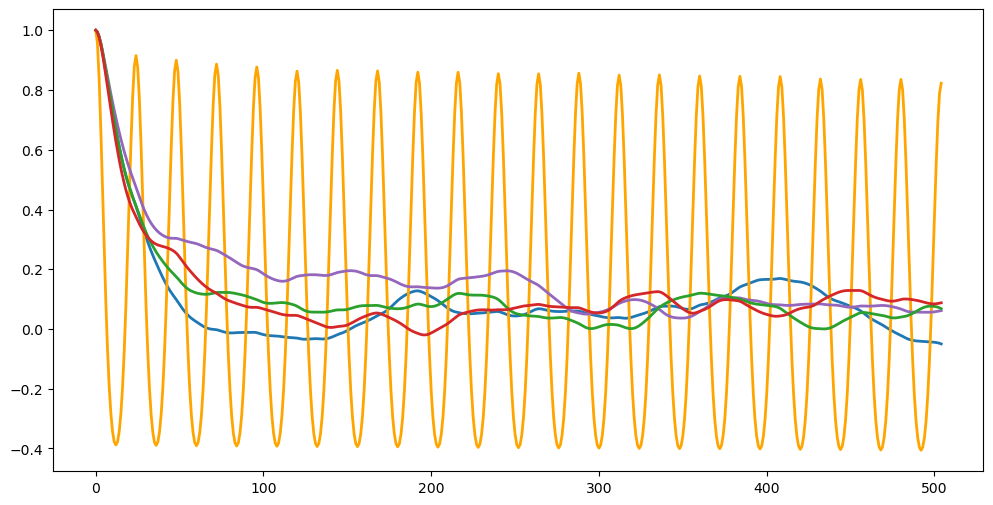

In [5]:

# 1. Calculate the ACF values for a week (168 hours)
nlags = 24*7*3
acf_wind21 = acf(CF_wind["2021"], nlags=nlags)
acf_solar21 = acf(CF_solar["2021"], nlags=nlags)
acf_wind22 = acf(CF_wind["2022"], nlags=nlags)
acf_wind23 = acf(CF_wind["2023"], nlags=nlags)
acf_wind24 = acf(CF_wind["2024"], nlags=nlags)
#acf_solar22 = acf(CF_solar["2022"], nlags=nlags)
# 2. Plot using plt.plot() for clarity over long durations
plt.figure(figsize=(12, 6))
# Plot wind in blue and solar in orange
plt.plot(range(len(acf_wind21)), acf_wind21, label='Wind ($CF_{wind}$) 2021', color='tab:blue', linewidth=2)
plt.plot(range(len(acf_solar21)), acf_solar21, label='Solar ($CF_{solar}$)', color='orange', linewidth=2)
plt.plot(range(len(acf_wind22)), acf_wind22, label='Wind ($CF_{wind}$) 2022', color='tab:purple', linewidth=2)
plt.plot(range(len(acf_wind23)), acf_wind23, label='Wind ($CF_{wind}$) 2023', color='tab:green', linewidth=2)
plt.plot(range(len(acf_wind24)), acf_wind24, label='Wind ($CF_{wind}$) 2024', color='tab:red', linewidth=2)
#plt.plot(range(len(acf_solar22)), acf_solar22, label='Solar ($CF_{solar}$)', color='red', linewidth=2)



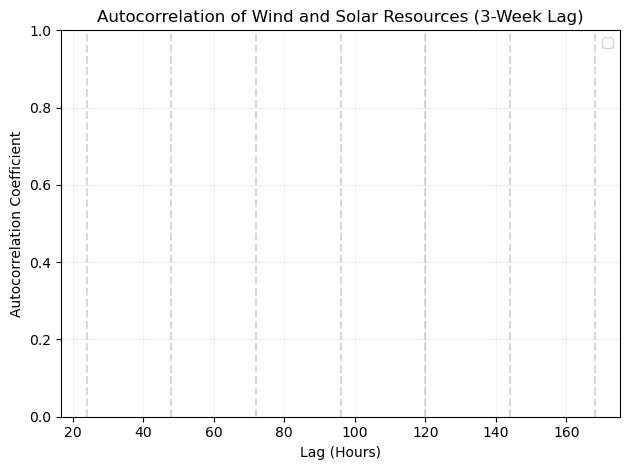

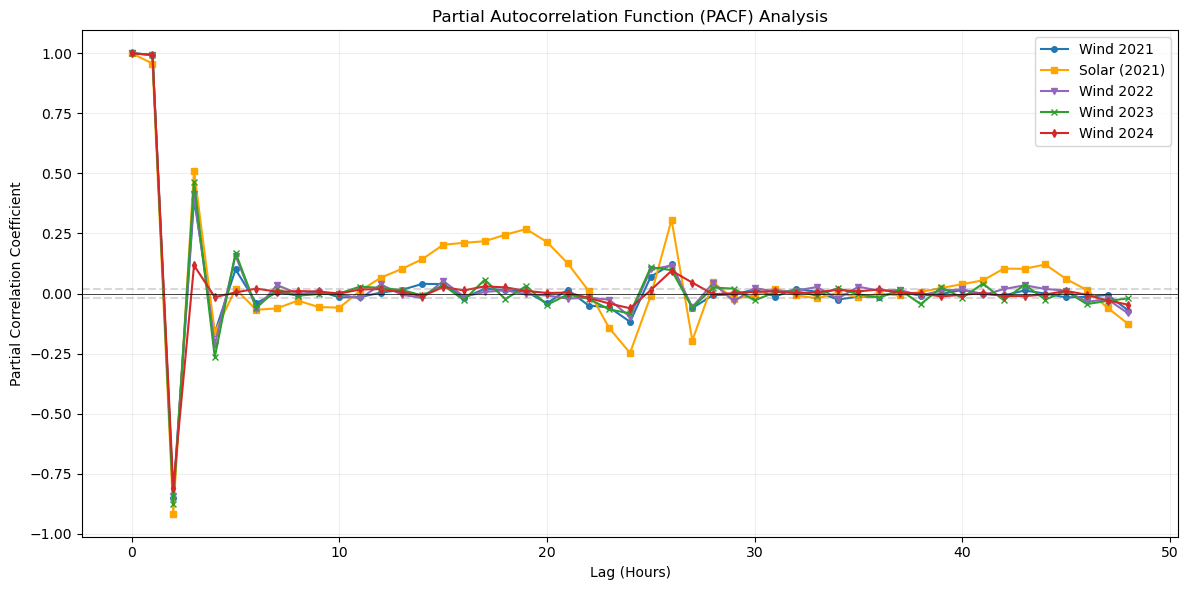

In [6]:

# 3. Add vertical dashed lines at 24-hour intervals to highlight the cycle
for day in range(1, 8):
    plt.axvline(x=day*24, color='gray', linestyle='--', alpha=0.3)

# Formatting for your thesis
plt.title("Autocorrelation of Wind and Solar Resources (3-Week Lag)")
plt.xlabel("Lag (Hours)")
plt.ylabel("Autocorrelation Coefficient")
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# 1. Calculate the PACF values (use 48h to see the AR order clearly)
nlags_pacf = 48
pacf_wind21 = pacf(CF_wind["2021"], nlags=nlags_pacf)
pacf_solar21 = pacf(CF_solar["2021"], nlags=nlags_pacf)
pacf_wind22 = pacf(CF_wind["2022"], nlags=nlags_pacf)
pacf_wind23 = pacf(CF_wind["2023"], nlags=nlags_pacf)
pacf_wind24 = pacf(CF_wind["2024"], nlags=nlags_pacf)

# 2. Plotting
plt.figure(figsize=(12, 6))
# Plot wind series and the solar comparison
plt.plot(range(len(pacf_wind21)), pacf_wind21, label='Wind 2021', color='tab:blue', marker='o', markersize=4)
plt.plot(range(len(pacf_solar21)), pacf_solar21, label='Solar (2021)', color='orange', marker='s', markersize=4)
plt.plot(range(len(pacf_wind22)), pacf_wind22, label='Wind 2022', color='tab:purple', marker='v', markersize=4)
plt.plot(range(len(pacf_wind23)), pacf_wind23, label='Wind 2023', color='tab:green', marker='x', markersize=4)
plt.plot(range(len(pacf_wind24)), pacf_wind24, label='Wind 2024', color='tab:red', marker='d', markersize=4)
# 3. Add confidence intervals (critical for PACF)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
# Significance level approximately 1.96/sqrt(N)
plt.axhline(y=0.02, color='gray', linestyle='--', alpha=0.3)
plt.axhline(y=-0.02, color='gray', linestyle='--', alpha=0.3)
plt.title("Partial Autocorrelation Function (PACF) Analysis")
plt.xlabel("Lag (Hours)")
plt.ylabel("Partial Correlation Coefficient")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


# NG Prices

In [7]:
## NG Prices
current_dir = os.getcwd()
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

# units is in DKK/kWh
gas_price_pre_oct_2021 = pd.read_excel("GasSystemBalanceUntil20221001.xlsx")
# 1. Clean and Deduplicate as you did
gas_price_pre_oct_2021["GasDay"] = pd.to_datetime(gas_price_pre_oct_2021["GasDay"]).dt.tz_localize(None)
gas_price_pre_oct_2021.index = pd.DatetimeIndex(gas_price_pre_oct_2021["GasDay"])
gas_price_pre_oct_2021 = gas_price_pre_oct_2021.groupby(level=0).mean(numeric_only=True)

# 2. Add a "dummy" row to ensure the LAST day gets all 24 hours
# This adds one more day at the very end of your existing index
last_day = gas_price_pre_oct_2021.index.max()
next_day = last_day + pd.Timedelta(days=1)
gas_price_pre_oct_2021.loc[next_day] = None 

# 3. Apply the 6-hour offset for the Danish Gas Day
gas_price_pre_oct_2021.index = gas_price_pre_oct_2021.index + pd.Timedelta(hours=6)

# 4. Resample and Forward Fill
# This propagates the 06:00 price through all 24 hours of that gas day
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021.resample('h').ffill()

# 5. Drop the very last hour (which belongs to the dummy day's 06:00 start)
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021_hourly.iloc[:-1]
gas_price_data = pd.read_excel(gas_file)

# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()
# EURO -> DKK exchange rate
EUR_DKK_exchangerate = (gas_price_hourly["ExchangeRateEUR_DKK"]/100)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]
part1 = gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"][:"2022-09-30"]*(1000/7.45)  # DKK/kwh -> EUR/MWh
part2 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"] # EUR/MWh

NG_price = pd.concat([part1, part2], axis=1)

# keep='last' prioritizes data from 'part2' for the overlapping hours
NG_price = NG_price[~NG_price.index.duplicated(keep='last')].sort_index()

# 4. Fill any remaining tiny gaps (just in case)
NG_price = NG_price.resample('H').ffill()

# 1. Fill missing values in the EUR_MWh column with the DKK column values
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].fillna(NG_price["GasBuyingPriceDKK"])

# 2. Drop the original DKK column if you no longer need it
NG_price = NG_price.drop(columns=["GasBuyingPriceDKK"])
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].ffill() 

# Electrcity Prices

In [8]:
# Electrcity Prices
"full spot price data el DK1";
elspotprices = pd.read_excel("Elspotprices1999_onwards.xlsx", index_col=0, parse_dates=True) # EUR/MWh
"øre/kWh";
tariff_el_use = {
    "2021": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.123)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.09,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.92         # Net Tariff: Spidslast
    },
     "2022": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.116)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 4.51,         # Net Tariff: Lavlast
        "el_tariff_high": 8.32,        # Net Tariff: Højlast
        "el_tariff_peak": 12.15         # Net Tariff: Spidslast
    },
    "2023": {
        "el_transmission_tariff": 5.8,
        "el_system_tariff": 5.4,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.16)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.43,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.33         # Net Tariff: Spidslast
    },
    "2024": {
        "el_transmission_tariff": 7.4,
        "el_system_tariff": 5.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.24)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 0.85,         # Net Tariff: Lavlast
        "el_tariff_high": 2.54,        # Net Tariff: Højlast
        "el_tariff_peak": 5.08,         # Net Tariff: Spidslast
    }

}


In [9]:

def build_electricity_grid_price_w_tariff(Elspotprices, tariff_dict, year):
    """
    Inputs:
        Elspotprices : pd.DataFrame (containing 'SpotPriceEUR')
        tariff_dict  : The multi-year dictionary (tariff_el_use)
        year         : int or str (e.g., 2021)
    """
    year_str = str(year)
    
    # --- 1. PREVENT TYPE ERROR: Select only the numeric column and filter year ---
    # We select only the 'SpotPriceEUR' column to avoid adding fees to string columns
    spot = Elspotprices.loc[Elspotprices.index.year == int(year_str), "SpotPriceEUR"]
    
    # Ensure it's numeric (handles any strange characters in the Excel)
    spot = pd.to_numeric(spot, errors='coerce').dropna()
    
    # --- 2. GET TARIFFS ---
    d = tariff_dict[year_str]
    DKK_to_EUR_MWh = 10 / 7.45  # Conversion: (øre/kWh * 10) / exchange_rate
    
    hours = spot.index
    is_winter = hours.month.isin([1, 2, 3, 10, 11, 12])
    is_weekday = hours.weekday < 5 
    
    # Define Hour Brackets
    is_low_hr  = hours.hour.isin(range(0, 6))   # 00:00 - 05:59
    is_peak_hr = hours.hour.isin(range(17, 21)) # 17:00 - 20:59
    is_day_hr  = hours.hour.isin(range(6, 24))  # 06:00 - 23:59

    # --- 3. APPLY NET TARIFF LOGIC (N1 MODEL 3.0) ---
    # Baseline is Low
    net_tariff = pd.Series(d["el_tariff_low"], index=hours)
    
    # Apply High (Højlast) to all hours between 06:00 and 00:00
    net_tariff.loc[is_day_hr] = d["el_tariff_high"]
    
    # Apply Peak (Spidslast) ONLY in Winter AND on Weekdays during Peak Hours
    net_tariff.loc[is_winter & is_weekday & is_peak_hr] = d["el_tariff_peak"]

    # --- 4. CALCULATE FINAL PRICES ---
    fixed_fees_ore = d["el_transmission_tariff"] + d["el_system_tariff"] + d["el_tax"]
    
    # Buy Price = Spot + (Fixed Tariffs + DSO Net Tariff) converted to EUR/MWh
    buy_price = spot + (fixed_fees_ore + net_tariff) * DKK_to_EUR_MWh
    
    # Sell Price = Spot minus production/balancing fees
    sell_price = -spot + (d["el_prod_tariff"] * DKK_to_EUR_MWh)

    return buy_price, sell_price

import_price21, export_price21 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2021")
import_price22, export_price22 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2022")
import_price23, export_price23 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2023")
import_price24, export_price24 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2024")


<Axes: xlabel='HourUTC'>

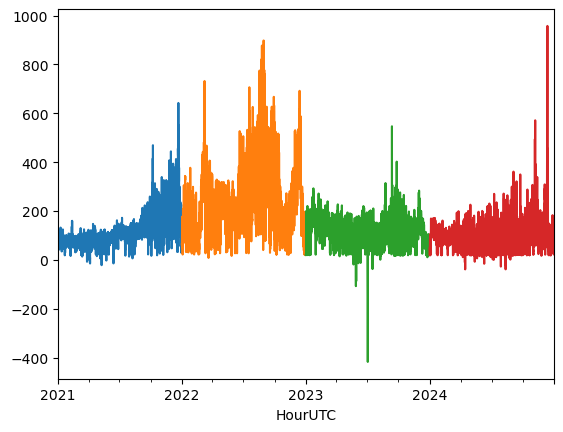

In [10]:

import_price21.plot()
import_price22.plot()
import_price23.plot()
import_price24.plot()

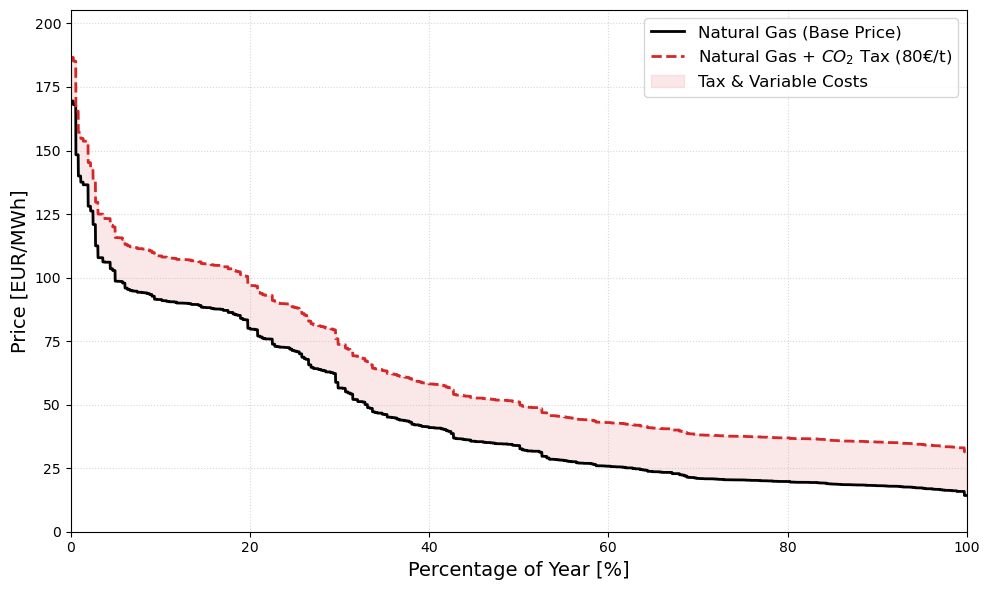

In [11]:

# 1. Setup Data
base_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"].sort_values(ascending=False).values
# 0.202 = Emission Factor (tCO2/MWh), 80 = Carbon Price (EUR/t), 1.007 = Additional variable cost
taxed_price = (NG_price["MarginalPurchasePriceEUR_MWh"]["2021"] + 0.202*80 + 1.007).sort_values(ascending=False).values

# Create a percentage x-axis (0-100%) - standard for duration curves
x = np.linspace(0, 100, len(base_price))

# 2. Plotting
plt.figure(figsize=(10, 6), dpi=100)

# Plot lines
plt.plot(x, base_price, color="black", linewidth=2, label="Natural Gas (Base Price)")
plt.plot(x, taxed_price, color="#d62728", linewidth=2, linestyle="--", label="Natural Gas + $CO_2$ Tax (80€/t)")

# 3. Add a "fill" to highlight the tax impact
plt.fill_between(x, base_price, taxed_price, color="#d62728", alpha=0.1, label="Tax & Variable Costs")

# 4. Styling
#plt.title("Natural Gas Price Duration Curve (2021)", fontsize=14, pad=15)
plt.ylabel("Price [EUR/MWh]", fontsize=14)
plt.xlabel("Percentage of Year [%]", fontsize=14)
plt.xlim(0, 100)
plt.ylim(0, max(taxed_price) * 1.1) # Auto-scale with 10% headroom

# 5. Legend and Grid
plt.legend(frameon=True, loc='upper right', fontsize = 12)
plt.grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

# Carbon Emission Grid

In [12]:
# Carbon Emissions Grid
import pandas as pd
import requests

# g/Kwh -> t/MWh

def get_danish_co2_data(start_date="2023-01-01", end_date="2023-12-31"):
    # The API uses a 'Where' filter for dates. 
    # We target DK1 (West Denmark/Skive area)
    url = "https://api.energidataservice.dk/dataset/CO2Emis"
    params = {
        'filter': '{"PriceArea":["DK1"]}',
        'start': start_date,
        'end': end_date,
        'columns': 'Minutes5UTC,CO2Emission',
        'sort': 'Minutes5UTC ASC'
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    # Convert to DataFrame
    df = pd.DataFrame(data['records'])
    
    # Convert time to datetime objects and set as index
    df['Minutes5UTC'] = pd.to_datetime(df['Minutes5UTC'])
    df.set_index('Minutes5UTC', inplace=True)
    
    # The API provides 5-min data. Resample to HOURLY to match PyPSA
    # 'mean()' is used to get the average emission for that hour
    df_hourly = df['CO2Emission'].resample('h').mean()
    
    return df_hourly

# Example: Get data for your n23 year
co2_21_24 = get_danish_co2_data("2021-01-01", "2025-01-01")
print(co2_21_24.head())

Minutes5UTC
2020-12-31 23:00:00    190.833333
2021-01-01 00:00:00    196.000000
2021-01-01 01:00:00    168.166667
2021-01-01 02:00:00    160.083333
2021-01-01 03:00:00    161.083333
Freq: h, Name: CO2Emission, dtype: float64


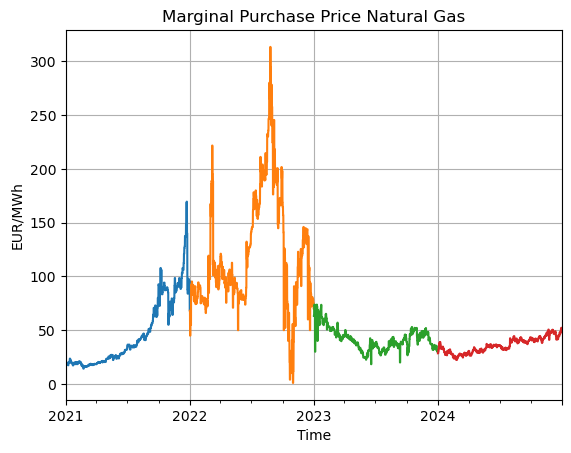

In [13]:

# To add it to your PyPSA network:
# n23.generators_t.weight_carbon = co2_2023.values
grid_emissions = co2_21_24/1e3 # t/MWh
NG_price["MarginalPurchasePriceEUR_MWh"]["2021"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2022"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2023"].plot()
NG_price["MarginalPurchasePriceEUR_MWh"]["2024"].plot()
#elspotprices["SpotPriceEUR"].plot()
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.xlim("2021-01-01", "2024-12-31")
plt.title("Marginal Purchase Price Natural Gas")
plt.grid()


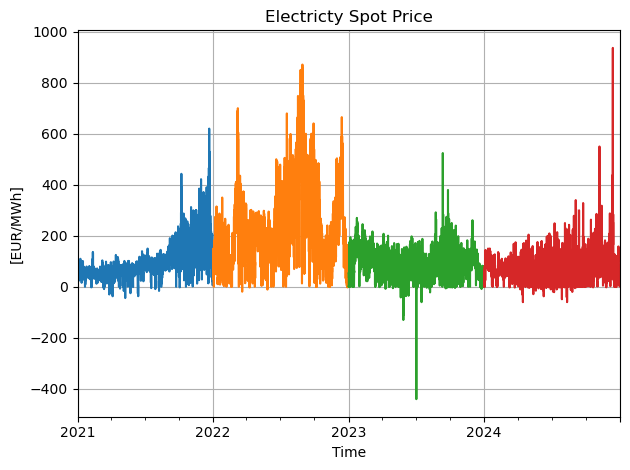

In [14]:
elspotprices["SpotPriceEUR"]["2021"].plot()
elspotprices["SpotPriceEUR"]["2022"].plot()
elspotprices["SpotPriceEUR"]["2023"].plot()
elspotprices["SpotPriceEUR"]["2024"].plot()
plt.ylabel("[EUR/MWh]")
plt.xlabel("Time")
plt.grid()
plt.title("Electricty Spot Price")
#plt.legend(["2021", "2022", "2023", "2024"])
plt.tight_layout()
plt.show()


In [15]:
"Filling Missing Data Values";
grid_emissions["2021":"2024"] = grid_emissions["2021":"2024"].ffill().bfill()
grid_emissions["2021":"2024"].isna().sum()

np.int64(0)

Text(0, 0.5, 'Emissions Intensity [$t_{CO_2}/MWh$]')

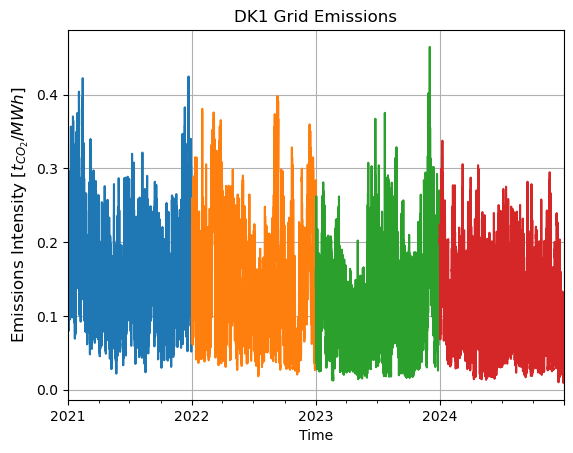

In [16]:
grid_emissions["2021"].plot()
grid_emissions["2022"].plot()
grid_emissions["2023"].plot()
grid_emissions["2024"].plot()
plt.title("DK1 Grid Emissions")
plt.xlabel("Time")
plt.grid()
plt.ylabel(r"Emissions Intensity [$t_{CO_2}/MWh$]", fontsize=12)


Text(0.5, 1.0, 'ACF Spot Prices')

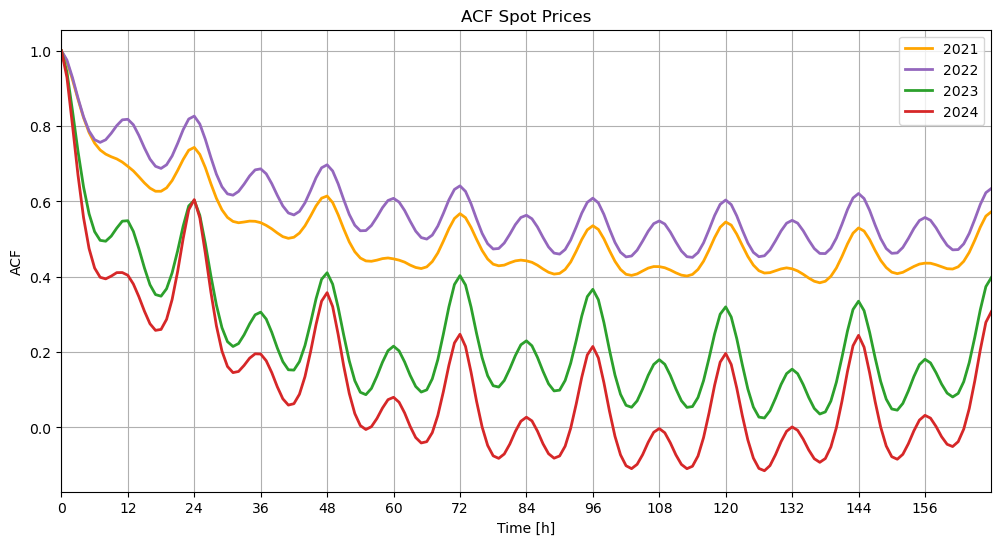

In [17]:

# 1. Calculate the ACF values for a week (168 hours)
nlags = 24*7*1
acf_price21 = acf(elspotprices["SpotPriceEUR"]["2021"], nlags=nlags)
acf_price22 = acf(elspotprices["SpotPriceEUR"]["2022"], nlags = nlags)
acf_price23 = acf(elspotprices["SpotPriceEUR"]["2023"], nlags = nlags)
acf_price24 = acf(elspotprices["SpotPriceEUR"]["2024"], nlags = nlags)
#acf_solar22 = acf(CF_solar["2022"], nlags=nlags)

# 2. Plot using plt.plot() for clarity over long durations
plt.figure(figsize=(12, 6))
plt.grid()
# Plot wind in blue and solar in orange
plt.plot(range(len(acf_price21)), acf_price21, label='2021', color='orange', linewidth=2)
plt.plot(range(len(acf_price22)), acf_price22, label='2022', color='tab:purple', linewidth=2)
plt.plot(range(len(acf_price23)), acf_price23, label='2023', color='tab:green', linewidth=2)
plt.plot(range(len(acf_price24)), acf_price24, label='2024', color='tab:red', linewidth=2)
plt.xlim(0,24*7)
plt.xticks(range(0,24*7,12))
plt.xlabel("Time [h]")
plt.ylabel("ACF")
plt.legend()
plt.title("ACF Spot Prices")


# MGA Scenario + Datacentre

In [400]:
def add_carriers(n):
    # Electricity Carriers
    n.add("Carrier", "onshorewind", color="#235ebc", nice_name="Onshore Wind")
    n.add("Carrier", "solar", color="#f9d002", nice_name="Solar PV")
    n.add("Carrier", "electricity", color="#ffde00")
    
    # Grid Interaction
    n.add("Carrier", "imports", color="#d3d3d3", nice_name="Grid Import")
    n.add("Carrier", "exports", color="#a9a9a9", nice_name="Grid Export")

    # Thermal & Storage
    # Note: 78.4% efficiency logic is usually handled in the Link, 
    # but the carrier helps with labeling.
    n.add("Carrier", "RONDO_store", color="#e6194b", nice_name="RONDO Storage")
    n.add("Carrier", "RONDO_charge", color="#fabebe")
    n.add("Carrier", "RONDO_discharge", color="#911eb4")
    n.add("Carrier", "El_Boiler", color="#f58231", nice_name="Electric Boiler")
    n.add("Carrier", "NG_boiler")


    # Gas & Biomass
    n.add("Carrier", "gas", color="#525252", nice_name="Natural Gas") 
    n.add("Carrier", "pellets", color="#808000")
    n.add("Carrier", "biomass", unit="t/h", color="#2ca02c")
    
    # Circular Economy & PtX
    n.add("Carrier", "Pyrolysis", color="#3cb44b")
    n.add("Carrier", "methanol", color="#4363d8")
    n.add("Carrier", "CO2", unit="t/h", color="#000000")
    n.add("Carrier", "biochar", color="#469990")
   
    n.add("Carrier", "biochar_sequestered")
    n.add("Carrier", "Methanolisation")
    n.add("Carrier", "methane")

    n.add("Carrier", "heat")
    n.add("Carrier", "battery_storage")

In [24]:
def heat_load(n,P_heat = 5):
    n.add("Load", "Biogas_Heat", carrier = "heat",
        bus = "Heat_MT",
        p_set = P_heat)

def el_load(n,P_el = 2):
    n.add("Load", "Biogas_el", carrier = "electricity",
        bus = "Greenlab",
        p_set = P_el)

In [401]:
def add_battery2(n,P_nom, max_t, cyclic_operation = True):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="Greenlab",  # Use your electricity bus name {EuroWind, Greenlab}
        carrier="battery_storage",
        max_hours= max_t,  # 22 MW * 2 h = 44 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"],
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # Discharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_min = 22,
        p_nom_max = 100,
        p_nom_extendable=True,
        cyclic_state_of_charge=cyclic_operation)

In [26]:
def add_skive_generators2(n,s_cf,w_cf):

    # EuroWind Owns These Assets
    n.add("Generator", "Skive_Solar", carrier="solar",
        bus = "Greenlab" , # Greenlab , EuroWind
        capital_cost=costs.at["solar", "capital_cost"],
        #marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu= s_cf, 
        p_nom = 30,
        p_nom_extendable = True,
        p_nom_min = 30,
        p_nom_max = 90)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "Greenlab",
        capital_cost=costs.at["onwind", "capital_cost"],
        #marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu= w_cf,
        p_nom = 54,
        p_nom_extendable = True,
        p_nom_min = 54,
        p_nom_max = 150)

In [27]:
def add_SkyClean_simple(n,CO2tax):  
    n.add("Generator","pellets input",
        bus="pellets",
        carrier="pellets",
        p_nom_extendable=True,
        marginal_cost= 62) #€/MWh (Price of straw pellets 380 €/t

    n.add("Store","pellets store",
     e_initial = (0.12*100)*len(n.snapshots), # MW (avialable pellets from a biogas plant) 
     e_nom = (0.12*100)*len(n.snapshots),
     bus = "pellets",
     carrier = "pellets",
     e_nom_extendable = False,
     e_cyclic = False)
    
    # straw pellets cost from 35 - 82 EUR/ton
    # LHV_pellets = 16 MJ/kg

    n.add("Link", "pyrolysis",
        bus0="pellets",
        bus1="Heat_MT",
        bus2="biochar",
        bus3 = "Greenlab",
        p_nom_extendable=False,
        p_nom=2,
        efficiency = 8.5/20, # MW , 8.2/21.7 , Heat High Temp
        efficiency2 = 9/20, # MW , 10.1/21.7 , Biochar
        efficiency3 = -0.02, # MW, auxillary power (2 %)
        carrier="Pyrolysis",
        capital_cost=costs.at["biochar pyrolysis","capital_cost"],
        #marginal_cost = 62, # EUR/MWh (cost of buying pellets from market)
        ) 

    
    n.add("Link", "biochar sequestration",
        bus0="biochar",
        bus1="biochar sequestration",
        efficiency=1,
        #p_nom = 1, # MW  
        p_nom_extendable = True,
        marginal_cost= -0.313*CO2tax,   #CO2 tax   or -0.164 (tCO2/MWh_pell)?  # -1  * co2_credits #-13.12eur/MWh
        carrier="biochar") 

    n.add("Store", "biochar sequestred",
        bus="biochar sequestration",
        #e_nom = 8e3,
        e_nom_extendable=True,
        e_cyclic=False,
        carrier="biochar_sequestered")

In [28]:
"High Temprature Bus (350)";
def add_TES_rondo2(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        e_nom= e_nom_store, # MWh
        e_nom_extendable=True,
        e_nom_min = e_nom_store,
        e_nom_max = 300,
        e_cyclic=False,
        standing_loss= 1.2/100, # 1.2% per hour
        carrier = "RONDO_store",
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link","El_to_TES_Rondo",
        bus0="Greenlab",
        bus1="TES_Rondo",
        p_nom_extendable=True,
        p_nom_min = p_nom_charge,
        #p_nom_max = p_nom_charge, 
        p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "RONDO_charge",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link", "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_MT",
        p_nom = p_nom_discharge,
        p_nom_extendable=True,
        p_nom_min = p_nom_discharge,
        #p_nom_max = p_nom_discharge,
        efficiency=0.90*0.8, # Including Efficency of Heat Exchanger here
        carrier = "RONDO_discharge",
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])

In [29]:
def rondo_constraints(n, snapshots):
    model = n.model
    store_name = "Rondo_Concrete_Heat_Storage"
    charge_link = "El_to_TES_Rondo"
    discharge_link = "TES_Rondo_to_Heat_Bus_Skive"

    # 1. Identify if components are Variables (extendable)
    # Using .index on the xarray variable is the most reliable way to check membership
    is_store_var = "Store-e_nom" in model.variables and store_name in model.variables["Store-e_nom"].labels.values
    is_charge_var = "Link-p_nom" in model.variables and charge_link in model.variables["Link-p_nom"].labels.values
    is_discharge_var = "Link-p_nom" in model.variables and discharge_link in model.variables["Link-p_nom"].labels.values

    # 2. Get Capacity (e_nom)
    e_nom = model.variables["Store-e_nom"].loc[store_name] if is_store_var else n.stores.at[store_name, "e_nom"]
    
    # 3. Add Charge Constraint (24% Ratio)
    if is_store_var or is_charge_var:
        p_nom_charge = model.variables["Link-p_nom"].loc[charge_link] if is_charge_var else n.links.at[charge_link, "p_nom"]
        model.add_constraints(p_nom_charge - 0.24 * e_nom == 0, name="Rondo_charge_ratio")

    # 4. Add Discharge Constraint (7% Ratio)
    if is_store_var or is_discharge_var:
        p_nom_discharge = model.variables["Link-p_nom"].loc[discharge_link] if is_discharge_var else n.links.at[discharge_link, "p_nom"]
        model.add_constraints(p_nom_discharge - 0.07 * e_nom == 0, name="Rondo_discharge_ratio")

In [30]:
def  add_electric_boiler2(n):
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "Greenlab",
        bus1="Heat_MT",
        p_nom = 10, # MW,
        p_nom_extendable = False,
        #p_nom = 10,
        #p_nom_min = 10,
        #p_nom_max = 10,
        efficiency=0.95, # 0.9
        carrier = "El_Boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"],
        #marginal_cost = costs.at["electric boiler steam","marginal_cost"]
        )

In [402]:
def add_NG_boiler2(n,CO2tax, NG_price):
     n.add("Generator",
        "NG grid",
        bus="NG",
        carrier="gas",
        p_nom = 6,
        p_nom_min = 6,
        marginal_cost = NG_price + 0.202*CO2tax + 1.007, #0.206  tCO2/MWh *  80EUR/tC02 + VOM 1.007EUR/MWh
        p_nom_extendable=False,)

     n.add("Link","NG boiler",
        bus0="NG",
        bus1="Heat_MT",
        carrier = "NG_boiler",
        capital_cost = costs.at["decentral gas boiler","capital_cost"],
        efficiency=0.9, # 0.98
        p_nom=6,
        #p_nom_min = 6,
        p_nom_extendable=False,) 

- currently there is 84 MW {Generation}
- assuming currently that Generation = Import
- Transformer Stations = Gen[MW] + Imports[MW]
- 200 >= P_gen + P_import

In [37]:
def add_grid2(n, price_import, price_export, grid_emissions, CO2tax):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
          bus="Grid_Import",
          p_nom_extendable=True,
          p_nom = 84, # GCP limit
          p_nom_min = 84,
          p_nom_max = 120,
          efficiency=1.0,
          marginal_cost=0,
          capital_cost=0.0,
          carrier="imports")

    n.add("Link", "Imports",
          bus0="Grid_Import",
          bus1="Greenlab",   # [EuroWind or Greenlab]
          p_nom=84,
          p_nom_min = 84,
          p_nom_max = 120,
          p_nom_extendable=True,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="imports",
          capital_cost = costs.at["electricity grid connection", "capital_cost"],
          marginal_cost= price_import + grid_emissions*CO2tax)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          #e_nom = 130e3, # MWh 
          e_0 = 0,
          capital_cost=0.0,
          standing_loss=0.0,
          carrier="exports")

    n.add("Link", "Exports",
          bus0="Greenlab",   # [EuroWind or Greenlab]
          bus1="Grid_Export",
          p_nom=84,
          p_nom_min = 84,
          p_nom_max = 120,
          p_nom_extendable=True,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="exports",
          marginal_cost=price_export)

- Imports = Exports

In [38]:
def grid_capacity_constraint(n, snapshots):
    """
    Forces the nominal capacity of the Import link to equal the Export link.
    """
    # 1. Check if Link-p_nom is a variable (extendable)
    if "Link-p_nom" in n.model.variables:
        # 2. Use .loc to select by label without needing the dimension name
        # This is exactly how your rondo_constraints handles e_nom
        import_p_nom = n.model.variables["Link-p_nom"].loc["Imports"]
        export_p_nom = n.model.variables["Link-p_nom"].loc["Exports"]
        
        # 3. Add the constraint
        n.model.add_constraints(
            import_p_nom - export_p_nom == 0, 
            name="Link-grid_equity"
        )

In [39]:
def skive_generation_grid_limit(n, snapshots):
    """
    Limits combined Wind + Solar capacity to the size of the Export Link.
    Constraint: Skive_Solar.p_nom + Skive_Onshore_Wind.p_nom <= Exports.p_nom
    """
    model = n.model
    
    # Ensure all necessary variables are in the optimization model
    if "Generator-p_nom" in model.variables and "Link-p_nom" in model.variables:
        
        solar_p = model.variables["Generator-p_nom"].loc["Skive_Solar"]
        wind_p = model.variables["Generator-p_nom"].loc["Skive_Onshore_Wind"]
        import_p = model.variables["Link-p_nom"].loc["Imports"]
        export_p = model.variables["Link-p_nom"].loc["Exports"]

        # This allows the solver to build UP TO the export capacity
        model.add_constraints(
            solar_p + wind_p - export_p <= 0, 
            name="Grid Symmetry")

       # To this (if you want the 200MW total site limit):
        #model.add_constraints(solar_p + wind_p + import_p <= 200
        #, name="Substation Cap")

In [40]:
# --- NEW: Combined Extra Functionality ---
def combined_constraints(n, snapshots):
        # 1. Run your existing Rondo constraints
        rondo_constraints(n, snapshots)
        # 2. Run the new grid capacity constraint
        grid_capacity_constraint(n, snapshots)
        # 3. Generation + Grid Limit
        skive_generation_grid_limit(n, snapshots)

In [403]:
def build_network_simple_w_datacentre(P_el_extra, P_heat, P_el, CO2_tax, grid_emissions, p_import, p_export, NG_price, horizon, overlap):
    n = pypsa.Network()
    n.set_snapshots(NG_price.index)

    # Align time-series data
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_imp = p_import.loc[n.snapshots].values
    p_exp = p_export.loc[n.snapshots].values
    grid_ems = grid_emissions.reindex(n.snapshots).ffill().values
    
    add_carriers(n)

    # Electricity & Generators
    n.add("Bus", "Greenlab", carrier="electricity")
    add_skive_generators2(n, s_cf, w_cf)
    add_battery2(n, P_nom=22, max_t=2, cyclic_operation=False)

    # Grid Connections
    n.add("Bus", "Grid_Import", carrier="imports")
    n.add("Bus", "Grid_Export", carrier="exports")
    add_grid2(n, price_import=p_imp, price_export=p_exp, grid_emissions=grid_ems, CO2tax=CO2_tax)

    # Heat & Boilers
    n.add("Bus", "Heat_MT", carrier="heat")
    add_electric_boiler2(n)

    # RONDO Storage
    n.add("Bus", "TES_Rondo", carrier="RONDO_store")
    # Make sure the name inside this helper function matches "Rondo_Concrete_Heat_Storage"
    add_TES_rondo2(n, e_nom_store=100, p_nom_charge=24, p_nom_discharge=7)

    # Biogas/SkyClean Section
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "biochar", carrier="biochar")
    n.add("Bus", "biochar sequestration", carrier="biochar_sequestered")
    add_SkyClean_simple(n, CO2tax=CO2_tax)

    # Natural Gas
    n.add("Bus", "NG", carrier="gas")
    add_NG_boiler2(n, CO2tax=CO2_tax, NG_price=NG_price)

    # Loads
    heat_load(n, P_heat=P_heat)
    el_load(n, P_el=P_el)

    n.add("Load", "Datacentre",
          bus="Greenlab",
          p_set=P_el_extra,
          carrier="electricity")

    # --- Solving Section ---
    if horizon is not None:
        # Rolling Horizon Optimization
        n.optimize.optimize_with_rolling_horizon(
            assign_all_duals=True,
            solver_name="gurobi", 
            horizon=horizon, 
            overlap=overlap,
            extra_functionality=combined_constraints # Pass function reference
        )
    else:
        # Full Year Optimization
        n.optimize(
            assign_all_duals=True,
            solver_name="gurobi",
            extra_functionality=combined_constraints# Pass function reference
        )

    return n

In [42]:
n21_w_datacentre = build_network_simple_w_datacentre(P_el_extra = 100,P_heat = 5, P_el = 2,CO2_tax = 80, grid_emissions = grid_emissions["2021"],p_import = import_price21, p_export = export_price21, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"], horizon = None, overlap = None)

Index(['NG boiler'], dtype='object', name='name')
Index(['Skive_Battery'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 16.26it/s]
INFO:linopy.io: Writing time: 4.81s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 14688 iterations and 5.70 seconds (2.78 work units)


INFO:gurobipy:Solved in 14688 iterations and 5.70 seconds (2.78 work units)


Optimal objective  9.425878946e+07


INFO:gurobipy:Optimal objective  9.425878946e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210110 primals, 472738 duals
Objective: 9.43e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Grid Symmetry were not assigned to the network.


In [539]:
n21_wo_datacentre = build_network_simple_w_datacentre(P_el_extra = 0,P_heat = 5, P_el = 2,CO2_tax = 80, grid_emissions = grid_emissions["2021"],p_import = import_price21, p_export = export_price21, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2021"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 18.13it/s]
INFO:linopy.io: Writing time: 4.57s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 13573 iterations and 6.11 seconds (2.82 work units)


INFO:gurobipy:Solved in 13573 iterations and 6.11 seconds (2.82 work units)


Optimal objective -8.699928230e+06


INFO:gurobipy:Optimal objective -8.699928230e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210110 primals, 472738 duals
Objective: -8.70e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Grid Symmetry were not assigned to the network.


In [126]:
n22_w_datacentre = build_network_simple_w_datacentre(P_el_extra = 100,P_heat = 5, P_el = 2,CO2_tax = 80, grid_emissions = grid_emissions["2022"],p_import = import_price22, p_export = export_price22, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2022"], horizon = None, overlap = None)

Index(['NG boiler'], dtype='object', name='name')
Index(['Skive_Battery'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 18.56it/s]
INFO:linopy.io: Writing time: 4.51s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 13325 iterations and 6.35 seconds (3.12 work units)


INFO:gurobipy:Solved in 13325 iterations and 6.35 seconds (3.12 work units)


Optimal objective  1.917459251e+08


INFO:gurobipy:Optimal objective  1.917459251e+08
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210254 primals, 473062 duals
Objective: 1.92e+08
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Grid Symmetry were not assigned to the network.


In [540]:
n22_wo_datacentre = build_network_simple_w_datacentre(P_el_extra = 0,P_heat = 5, P_el = 2,CO2_tax = 80, grid_emissions = grid_emissions["2022"],p_import = import_price22, p_export = export_price22, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2022"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 18.90it/s]
INFO:linopy.io: Writing time: 4.9s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 12788 iterations and 7.21 seconds (3.55 work units)


INFO:gurobipy:Solved in 12788 iterations and 7.21 seconds (3.55 work units)


Optimal objective -3.017891897e+07


INFO:gurobipy:Optimal objective -3.017891897e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210254 primals, 473062 duals
Objective: -3.02e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Grid Symmetry were not assigned to the network.


In [127]:
n23_w_datacentre = build_network_simple_w_datacentre(P_el_extra = 100,P_heat = 5, P_el = 2,CO2_tax = 80, grid_emissions = grid_emissions["2023"],p_import = import_price23, p_export = export_price23, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2023"], horizon = None, overlap = None)

Index(['NG boiler'], dtype='object', name='name')
Index(['Skive_Battery'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 20.24it/s]
INFO:linopy.io: Writing time: 4.14s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 14227 iterations and 6.49 seconds (3.12 work units)


INFO:gurobipy:Solved in 14227 iterations and 6.49 seconds (3.12 work units)


Optimal objective  8.901528288e+07


INFO:gurobipy:Optimal objective  8.901528288e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210254 primals, 473062 duals
Objective: 8.90e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Grid Symmetry were not assigned to the network.


In [541]:
n23_wo_datacentre = build_network_simple_w_datacentre(P_el_extra = 0,P_heat = 5, P_el = 2,CO2_tax = 80, grid_emissions = grid_emissions["2023"],p_import = import_price23, p_export = export_price23, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2023"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 18.71it/s]
INFO:linopy.io: Writing time: 4.78s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 13390 iterations and 6.41 seconds (3.19 work units)


INFO:gurobipy:Solved in 13390 iterations and 6.41 seconds (3.19 work units)


Optimal objective -9.826353667e+06


INFO:gurobipy:Optimal objective -9.826353667e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210254 primals, 473062 duals
Objective: -9.83e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Grid Symmetry were not assigned to the network.


In [46]:
n24_w_datacentre = build_network_simple_w_datacentre(P_el_extra = 100,P_heat = 5, P_el = 2,CO2_tax = 80, grid_emissions = grid_emissions["2024"],p_import = import_price24, p_export = export_price24, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2024"], horizon = None, overlap = None)

Index(['NG boiler'], dtype='object', name='name')
Index(['Skive_Battery'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 19.25it/s]
INFO:linopy.io: Writing time: 4.48s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 13570 iterations and 6.74 seconds (3.40 work units)


INFO:gurobipy:Solved in 13570 iterations and 6.74 seconds (3.40 work units)


Optimal objective  7.724120125e+07


INFO:gurobipy:Optimal objective  7.724120125e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210830 primals, 474358 duals
Objective: 7.72e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Grid Symmetry were not assigned to the network.


In [542]:
n24_wo_datacentre = build_network_simple_w_datacentre(P_el_extra = 0,P_heat = 5, P_el = 2,CO2_tax = 80, grid_emissions = grid_emissions["2024"],p_import = import_price24, p_export = export_price24, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2024"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 18.94it/s]
INFO:linopy.io: Writing time: 4.73s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 12174 iterations and 6.58 seconds (3.34 work units)


INFO:gurobipy:Solved in 12174 iterations and 6.58 seconds (3.34 work units)


Optimal objective -7.249423326e+06


INFO:gurobipy:Optimal objective -7.249423326e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210830 primals, 474358 duals
Objective: -7.25e+06
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Grid Symmetry were not assigned to the network.


(70.0, 160.0)

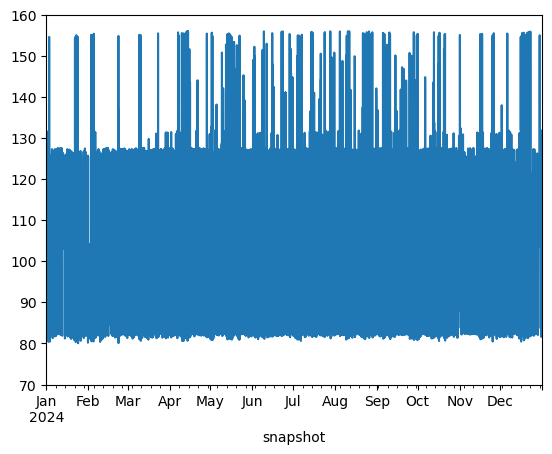

In [ ]:
(n24_w_datacentre.links_t.p0["Imports"] + n24_w_datacentre.generators_t.p["Skive_Solar"] + n24_w_datacentre.generators_t.p["Skive_Onshore_Wind"]).plot()
plt.ylim(70,160)

In [615]:
n24_wo_datacentre.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Grid Import                 120.00000                84.0   
            Natural Gas                   6.00000                 6.0   
            Onshore Wind                 54.00000                54.0   
            Solar PV                     30.00000                30.0   
Link        Electric Boiler              10.00000                10.0   
            Grid Export                  84.00000                84.0   
            Grid Import                  84.00000                84.0   
            NG_boiler                     6.00000                 6.0   
            Pyrolysis                     2.00000                 2.0   
            RONDO_charge                 24.00000                24.0   
            RONDO_discharge               7.00000                 7.0   
            biochar                       0.90000                 0.0   
Load        electricity                   0.00000                 0.0   
            heat                          0.00000                 0.0   
StorageUnit battery_storage              22.00000                22.0   
Store       Grid Export              108678.09886                 0.0   
            RONDO Storage               100.00000               100.0   
            biochar_sequestered        7905.60000                 0.0   
            pellets                  105408.00000            105408.0   

                                       Supply    Withdrawal  Energy Balance  \
Generator   Grid Import            2618.59317       0.00000      2618.59317   
            Natural Gas           21076.81381       0.00000     21076.81381   
            Onshore Wind         126101.23636       0.00000    126101.23636   
            Solar PV              28927.48800       0.00000     28927.48800   
Link        Electric Boiler           0.00000    8838.66994     -8838.66994   
            Grid Export               0.00000  112039.27718   -112039.27718   
            Grid Import               0.00000    2618.59317     -2618.59317   
            NG_boiler                 0.00000   21076.81381    -21076.81381   
            Pyrolysis                 0.00000   17568.00000    -17568.00000   
            RONDO_charge              0.00000   14627.66001    -14627.66001   
            RONDO_discharge           0.00000   12621.84879    -12621.84879   
            biochar                   0.00000    7905.60000     -7905.60000   
Load        electricity               0.00000   17568.00000    -17568.00000   
            heat                      0.00000   43920.00000    -43920.00000   
StorageUnit battery_storage       22888.18608   27031.97869     -4143.79260   
Store       Grid Export               0.00000  108678.09886   -108678.09886   
            RONDO Storage         11384.74716   13098.00518     -1713.25802   
            biochar_sequestered       0.00000    7905.60000     -7905.60000   
            pellets               17568.00000       0.00000     17568.00000   

                                Transmission  Capacity Factor   Curtailment  \
Generator   Grid Import                  0.0         0.002484  1.051461e+06   
            Natural Gas                  0.0         0.399910  3.162719e+04   
            Onshore Wind                 0.0         0.265848  3.205640e+03   
            Solar PV                     0.0         0.109773  2.944440e+02   
Link        Electric Boiler              0.0         0.100622  0.000000e+00   
            Grid Export                  0.0         0.151844  0.000000e+00   
            Grid Import                  0.0         0.003549  0.000000e+00   
            NG_boiler                    0.0         0.399910  0.000000e+00   
            Pyrolysis                    0.0         1.000000  0.000000e+00   
            RONDO_charge                 0.0         0.069386  0.000000e+00   
            RONDO_discharge              0.0         0.205273  0.000000e+00   
            biochar                      0.

In [568]:
n24_wo_datacentre.links_t.p0["Exports"].max()

70.558432

In [555]:
n24_wo_datacentre.statistics.optimal_capacity()

component    carrier            
Generator    Grid Import               120.00000
             Natural Gas                 6.00000
             Onshore Wind               54.00000
             Solar PV                   30.00000
Link         Electric Boiler            10.00000
             Grid Export                84.00000
             Grid Import                84.00000
             NG_boiler                   6.00000
             Pyrolysis                   2.00000
             RONDO_charge               24.00000
             RONDO_discharge             7.00000
             biochar                     0.90000
StorageUnit  battery_storage            22.00000
Store        Grid Export            108678.09886
             RONDO Storage             100.00000
             biochar_sequestered      7905.60000
             pellets                105408.00000
dtype: float64

In [523]:
n24_w_datacentre.statistics.capex() - n24_wo_datacentre.statistics.capex()

component    carrier        
Generator    Onshore Wind       4.619028e+06
             Solar PV           0.000000e+00
Link         Electric Boiler    0.000000e+00
             Grid Import        6.396439e+05
             NG_boiler          0.000000e+00
             Pyrolysis          0.000000e+00
             RONDO_charge       0.000000e+00
             RONDO_discharge    0.000000e+00
StorageUnit  battery_storage    0.000000e+00
Store        RONDO Storage      0.000000e+00
dtype: float64

In [622]:
n24_wo_datacentre.statistics.capex()

component    carrier        
Generator    Onshore Wind       6.928542e+06
             Solar PV           1.936804e+06
Link         Electric Boiler    8.896764e+04
             Grid Import        1.492503e+06
             NG_boiler          3.342596e+05
             Pyrolysis          4.658478e+07
             RONDO_charge       3.828314e+05
             RONDO_discharge    4.057112e+05
StorageUnit  battery_storage    2.119674e+06
Store        RONDO Storage      2.434916e+05
dtype: float64

In [635]:
n23_w_datacentre.statistics.opex()

component  carrier    
Generator  Natural Gas    1.821116e+06
Link       Grid Import    8.213291e+07
           biochar       -1.974154e+05
dtype: float64

In [634]:
n22_w_datacentre.statistics.opex()

component  carrier    
Generator  Natural Gas    4.412150e+06
Link       Grid Export   -1.922248e+04
           Grid Import    1.783313e+08
           biochar       -1.974154e+05
dtype: float64

In [639]:
n22_w_datacentre.statistics.optimal_capacity()

component    carrier            
Generator    Grid Import               120.00000
             Natural Gas                 6.00000
             Onshore Wind               90.00000
             Solar PV                   30.00000
Link         Electric Boiler            10.00000
             Grid Export               120.00000
             Grid Import               120.00000
             NG_boiler                   6.00000
             Pyrolysis                   2.00000
             RONDO_charge               24.00000
             RONDO_discharge             7.00000
             biochar                     0.90000
StorageUnit  battery_storage            63.10495
Store        Grid Export               177.72533
             RONDO Storage             100.00000
             biochar_sequestered      7884.00000
             pellets                105120.00000
dtype: float64

In [630]:
90*costs.at["onwind", "capital_cost"]/1e7

np.float64(1.1547569728980074)

In [627]:
30*costs.at["solar", "capital_cost"]/1e6

np.float64(1.936804300673375)

In [603]:
n22_wo_datacentre.statistics.installed_capacity()

component    carrier        
Generator    Grid Import            84.0
             Natural Gas             6.0
             Onshore Wind           54.0
             Solar PV               30.0
Link         Electric Boiler        10.0
             Grid Export            84.0
             Grid Import            84.0
             NG_boiler               6.0
             Pyrolysis               2.0
             RONDO_charge           24.0
             RONDO_discharge         7.0
StorageUnit  battery_storage        22.0
Store        RONDO Storage         100.0
             pellets            105120.0
dtype: float64

In [509]:
n21_w_datacentre.statistics.opex()

component  carrier    
Generator  Natural Gas    2.182246e+06
Link       Grid Import    8.701515e+07
           biochar       -1.972801e+05
dtype: float64

In [510]:
n21_wo_datacentre.statistics.opex()

component  carrier    
Generator  Natural Gas    1.680215e+06
Link       Grid Export   -1.550927e+07
           Grid Import    6.773636e+04
           biochar       -1.972801e+05
dtype: float64

In [500]:
n21_w_datacentre.statistics.opex().sum()/1e6, n21_w_datacentre.statistics.capex().sum()/1e6

(np.float64(89.00011762935), np.float64(65.77623117375))

In [501]:
n21_wo_datacentre.statistics.opex().sum()/1e6,  n21_wo_datacentre.statistics.capex().sum()/1e6

(np.float64(-13.95860005692), np.float64(65.77623117375))

In [502]:
n22_w_datacentre.statistics.opex().sum()/1e6, n22_w_datacentre.statistics.capex().sum()/1e6

(np.float64(182.52684039981), np.float64(69.73664406494))

In [503]:
n22_wo_datacentre.statistics.opex().sum()/1e6,  n22_wo_datacentre.statistics.capex().sum()/1e6

(np.float64(-36.954334766529996), np.float64(67.29297514343999))

In [505]:
n23_wo_datacentre.statistics.opex().sum()/1e6,  n23_wo_datacentre.statistics.capex().sum()/1e6

(np.float64(-15.08502549346), np.float64(65.77623117375))

In [504]:
n23_w_datacentre.statistics.opex().sum()/1e6,  n23_w_datacentre.statistics.capex().sum()/1e6

(np.float64(83.75661105133), np.float64(65.77623117375))

In [506]:
n24_wo_datacentre.statistics.opex().sum()/1e6,  n24_wo_datacentre.statistics.capex().sum()/1e6

(np.float64(-7.2494233263700005), np.float64(60.51755934719001))

In [507]:
n24_w_datacentre.statistics.opex().sum()/1e6,  n24_w_datacentre.statistics.capex().sum()/1e6

(np.float64(71.98252942062999), np.float64(65.77623117375))

In [477]:
elspotprices["SpotPriceEUR"]["2021":"2024"]

HourUTC
2021-01-01 00:00:00    48.189999
2021-01-01 01:00:00    44.680000
2021-01-01 02:00:00    42.919998
2021-01-01 03:00:00    40.389999
2021-01-01 04:00:00    40.200001
                         ...    
2024-12-31 19:00:00    19.000000
2024-12-31 20:00:00    15.700000
2024-12-31 21:00:00     9.060000
2024-12-31 22:00:00     0.520000
2024-12-31 23:00:00     2.160000
Name: SpotPriceEUR, Length: 35064, dtype: float64

In [487]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

<Axes: xlabel='snapshot'>

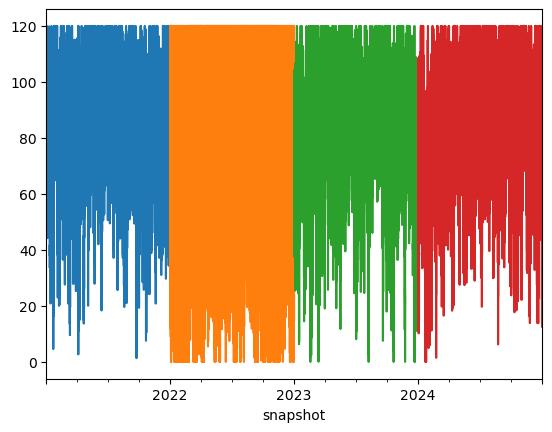

In [494]:
#elspotprices["SpotPriceEUR"]["2021":"2024"].plot()
n21_w_datacentre.links_t.p0["Imports"].plot()
n22_w_datacentre.links_t.p0["Imports"].plot()
n23_w_datacentre.links_t.p0["Imports"].plot()
n24_w_datacentre.links_t.p0["Imports"].plot()

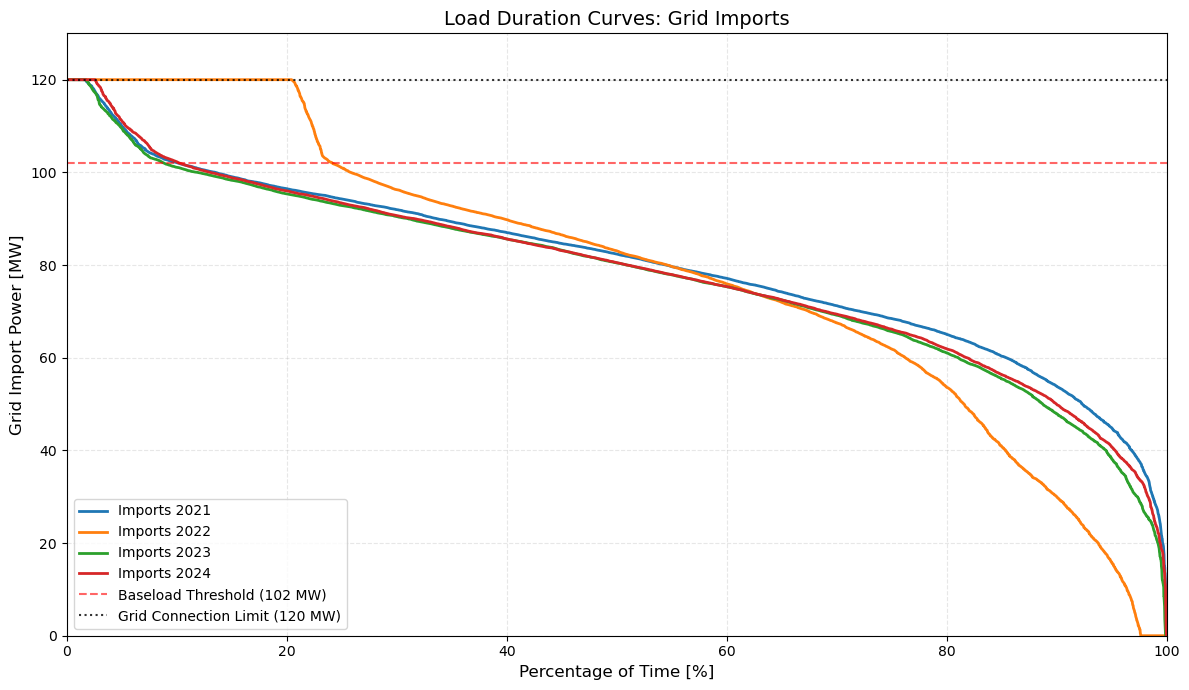

In [497]:
import matplotlib.pyplot as plt
import numpy as np

# List of your networks and labels
networks = {
    "2021": n21_w_datacentre,
    "2022": n22_w_datacentre,
    "2023": n23_w_datacentre,
    "2024": n24_w_datacentre
}

plt.figure(figsize=(12, 7))

for year, n in networks.items():
    # Extract, sort descending, and normalize the x-axis to percentage
    imports = n.links_t.p0["Imports"].sort_values(ascending=False).values
    x = np.linspace(0, 100, len(imports))
    plt.plot(x, imports, label=f"Imports {year}", linewidth=2)

# Marking the critical 105 MW Baseload
plt.axhline(102, color='red', linestyle='--', alpha=0.6, label='Baseload Threshold (102 MW)')
# Marking the 120 MW Infrastructure Limit
plt.axhline(120, color='black', linestyle=':', alpha=0.8, label='Grid Connection Limit (120 MW)')

plt.xlabel("Percentage of Time [%]", fontsize=12)
plt.ylabel("Grid Import Power [MW]", fontsize=12)
plt.title("Load Duration Curves: Grid Imports", fontsize=14)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.ylim(0, 130)
plt.xlim(0, 100)

plt.tight_layout()
#plt.savefig("Import_Duration_Curves.png", dpi=300)

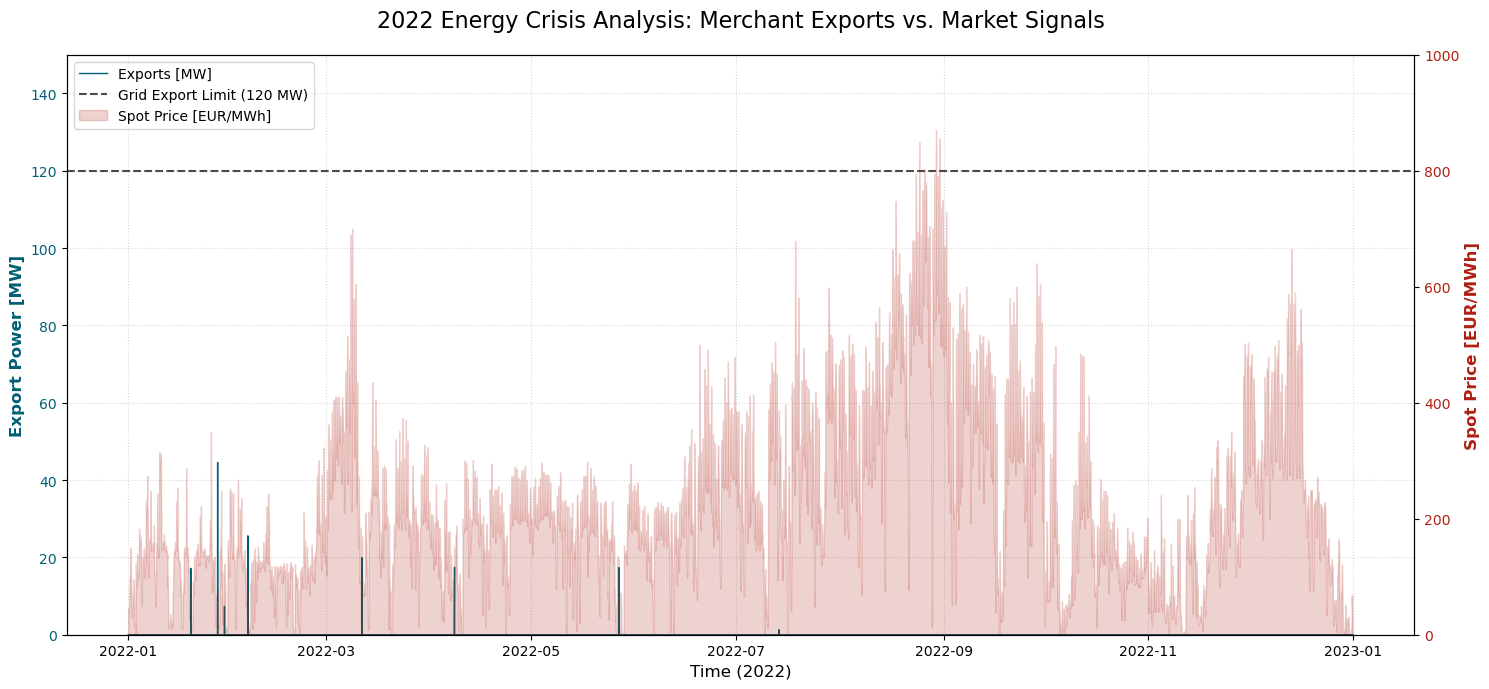

In [490]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(15, 7))

# Primary Axis: Export Power (MW) for 2022
export_2022 = n22_w_datacentre.links_t.p0["Exports"]
ax1.plot(export_2022.index, export_2022.values, color='#005f73', label='Exports [MW]', linewidth=1)

# Add the Infrastructure Ceiling (120 MW) - The "Export Pipe" Limit
ax1.axhline(120, color='black', linestyle='--', alpha=0.7, label='Grid Export Limit (120 MW)')

ax1.set_ylabel('Export Power [MW]', color='#005f73', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 150)
ax1.tick_params(axis='y', labelcolor='#005f73')
ax1.set_xlabel('Time (2022)', fontsize=12)

# Secondary Axis: Spot Price (EUR/MWh) for 2022
ax2 = ax1.twinx()
price_2022 = elspotprices["SpotPriceEUR"]["2022"]
# Use fill_between to highlight the extreme spikes
ax2.fill_between(price_2022.index, 0, price_2022.values, color='#ae2012', alpha=0.2, label='Spot Price [EUR/MWh]')

ax2.set_ylabel('Spot Price [EUR/MWh]', color='#ae2012', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1000)
ax2.tick_params(axis='y', labelcolor='#ae2012')

plt.title('2022 Energy Crisis Analysis: Merchant Exports vs. Market Signals', fontsize=16, pad=20)
ax1.grid(True, which='both', linestyle=':', alpha=0.5)

# Combined Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
#plt.savefig("2022_Market_Focus.png", dpi=300)

<Axes: xlabel='snapshot'>

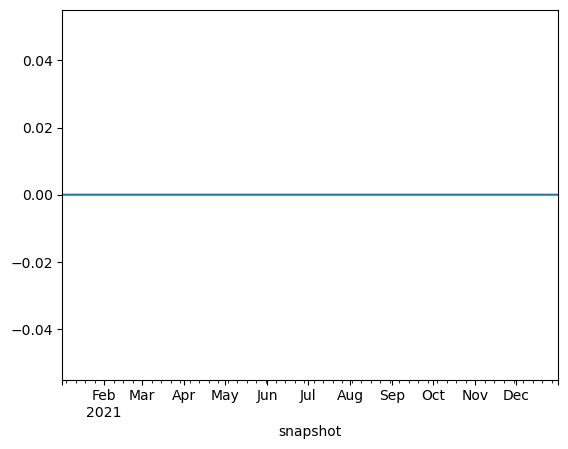

In [45]:
n21_w_datacentre.links_t.p0["Exports"].plot()

In [435]:
n22_wo_datacentre.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Grid Import                 120.00000                84.0   
            Natural Gas                   6.00000                 6.0   
            Onshore Wind                 90.00000                54.0   
            Solar PV                     30.00000                30.0   
Link        Electric Boiler              10.00000                10.0   
            Grid Export                 120.00000                84.0   
            Grid Import                 120.00000                84.0   
            NG_boiler                     6.00000                 6.0   
            Pyrolysis                     2.00000                 2.0   
            RONDO_charge                 24.00000                24.0   
            RONDO_discharge               7.00000                 7.0   
            biochar                       0.90000                 0.0   
Load        electricity                   0.00000                 0.0   
            heat                          0.00000                 0.0   
StorageUnit battery_storage              37.74222                22.0   
Store       Grid Export              198758.14647                 0.0   
            RONDO Storage               100.00000               100.0   
            biochar_sequestered        7884.00000                 0.0   
            pellets                  105120.00000            105120.0   

                                       Supply    Withdrawal  Energy Balance  \
Generator   Grid Import            4369.94031       0.00000      4369.94031   
            Natural Gas           27288.57479       0.00000     27288.57479   
            Onshore Wind         208609.25586       0.00000    208609.25586   
            Solar PV              32213.52000       0.00000     32213.52000   
Link        Electric Boiler           0.00000    6439.64792     -6439.64792   
            Grid Export               0.00000  204905.30564   -204905.30564   
            Grid Import               0.00000    4369.94031     -4369.94031   
            NG_boiler                 0.00000   27288.57479    -27288.57479   
            Pyrolysis                 0.00000   17520.00000    -17520.00000   
            RONDO_charge              0.00000    9281.41347     -9281.41347   
            RONDO_discharge           0.00000    7884.19051     -7884.19051   
            biochar                   0.00000    7884.00000     -7884.00000   
Load        electricity               0.00000   17520.00000    -17520.00000   
            heat                      0.00000   43800.00000    -43800.00000   
StorageUnit battery_storage       40351.50266   46916.35359     -6564.85093   
Store       Grid Export               0.00000  198758.14647   -198758.14647   
            RONDO Storage          7575.10600    8786.70069     -1211.59469   
            biochar_sequestered       0.00000    7884.00000     -7884.00000   
            pellets               17520.00000       0.00000     17520.00000   

                                Transmission  Capacity Factor   Curtailment  \
Generator   Grid Import                  0.0         0.004157  1.046830e+06   
            Natural Gas                  0.0         0.519188  2.527143e+04   
            Onshore Wind                 0.0         0.264598  1.465218e+03   
            Solar PV                     0.0         0.122578  0.000000e+00   
Link        Electric Boiler              0.0         0.073512  0.000000e+00   
            Grid Export                  0.0         0.194925  0.000000e+00   
            Grid Import                  0.0         0.004157  0.000000e+00   
            NG_boiler                    0.0         0.519188  0.000000e+00   
            Pyrolysis                    0.0         1.000000  0.000000e+00   
            RONDO_charge                 0.0         0.044147  0.000000e+00   
            RONDO_discharge              0.0         0.128574  0.000000e+00   
            biochar                      0.

In [600]:
n24_w_datacentre.objective/1e6

77.24120124714572

In [447]:
n24_w_datacentre.statistics.optimal_capacity()

component    carrier            
Generator    Grid Import               120.0
             Natural Gas                 6.0
             Onshore Wind               90.0
             Solar PV                   30.0
Link         Electric Boiler            10.0
             Grid Export               120.0
             Grid Import               120.0
             NG_boiler                   6.0
             Pyrolysis                   2.0
             RONDO_charge               24.0
             RONDO_discharge             7.0
             biochar                     0.9
StorageUnit  battery_storage            22.0
Store        RONDO Storage             100.0
             biochar_sequestered      7905.6
             pellets                105408.0
dtype: float64

In [472]:
30*CF_solar["2021"].max() + 90*CF_wind["2021"].min()

22.086779999999997

In [ ]:
print(n24_w_datacentre.links.index)
print(n24_w_datacentre.generators.index)
print(n24_w_datacentre.stores.index)

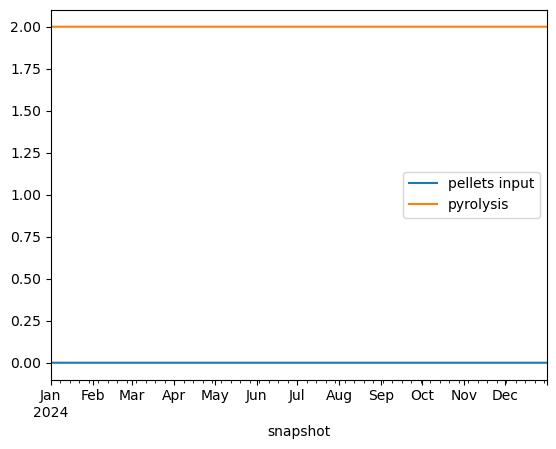

In [110]:
n24_w_datacentre.generators_t.p["pellets input"].plot()
n24_w_datacentre.links_t.p0["pyrolysis"].plot()
plt.legend()

# MGA

In [48]:
from pypsa.optimization.mga import generate_directions_random
from scipy.spatial import ConvexHull, convex_hull_plot_2d
from matplotlib.collections import LineCollection

In [60]:

def run_mga_multi_dimensions(network, slack, num_directions=10, seed=0):
    """
    Explores the near-optimal space in multiple random directions 
    to map the feasibility 'kite'.
    """
    # 1. Safely unlock the solver model
    model = getattr(network, "model", None)
    if model is not None:
        model.solver_model = None
    
    # 2. Prepare local copy
    n_temp = network.copy()
    
    # 3. Define the search dimensions (Decision Variables)
    dimensions = {
        "wind": {"Generator": {"p_nom": {"Skive_Onshore_Wind": 1}}},
        "solar": {"Generator": {"p_nom": {"Skive_Solar": 1}}},
        "rondo": {"Store": {"e_nom": {"Rondo_Concrete_Heat_Storage": 1}}},
        "battery": {"StorageUnit": {"p_nom": {"Skive_Battery": 1}}},
        "grid": {"Link": {"p_nom": {"Imports": 1}}},
        #"NG boiler": {"links": {"p_nom": {"NG boiler": 0}}},
        #"RONDO discharger": {"links": {"p_nom": {"TES_Rondo_to_Heat_Bus_Skive": 0}}},
        #"El boiler": {"links": {"p_nom": {"Boiler_Skive": 0}}},
    }
    
    # 4. Generate random search vectors
    #directions = generate_directions_random(dimensions.keys(), num_directions, seed=seed)
    directions = pypsa.optimization.mga.generate_directions_halton(dimensions.keys(), num_directions, seed=0)
    
    # 5. Solve in parallel
    print(f"Solving MGA in {num_directions} directions | Slack: {slack*100}%")

    # This returns the directions used and the resulting coordinate points
    dirs, pts = n_temp.optimize.optimize_mga_in_multiple_directions(
        dimensions=dimensions,
        directions=directions,
        slack=slack,
        solver_name="gurobi",
        max_parallel=8 # Adjust based on your CPU cores
    )
    
    return dirs, pts

In [ ]:
# 1. Run the multi-directional search
n21_mga = run_mga_multi_dimensions(n21_w_datacentre, slack=0.01, num_directions=20)

Solving MGA in 20 directions | Slack: 1.0%


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\Pulin\AppData\Local\Temp\tmpbj0n21hb.nc contains: stores, generators, loads, sub_networks, buses, links, storage_units, carriers


(        wind     solar     rondo   battery      grid
0  -0.097929 -0.325165  0.848547 -0.374254 -0.156777
1  -0.508412  0.258821 -0.153127  0.314947  0.742893
2   0.236242 -0.604122  0.188711 -0.595259 -0.435065
3  -0.214323 -0.125267 -0.710370 -0.650561 -0.102557
4   0.871843 -0.447189 -0.015514  0.117630  0.160730
5  -0.486774  0.437690  0.476060 -0.250080 -0.531325
6   0.248113 -0.023206  0.874153  0.303341 -0.285907
7   0.133140  0.348525  0.100352  0.910607  0.146729
8  -0.377527 -0.480893  0.629306  0.474280  0.072439
9   0.383315  0.139466 -0.335113  0.146003 -0.836661
10 -0.234232 -0.133651 -0.051324 -0.890352 -0.363198
11  0.747489 -0.506009  0.056586 -0.319178 -0.283088
12 -0.855632  0.422914  0.132496  0.177376  0.200050
13 -0.323437  0.191168 -0.355207 -0.520679  0.679385
14 -0.131811  0.101719 -0.785212  0.341299  0.489118
15  0.159766  0.799495 -0.080204 -0.025486 -0.572887
16  0.650136 -0.144436 -0.475671  0.548795 -0.170362
17 -0.365545 -0.592123 -0.637933 -0.104337  0

In [128]:

n22_mga = run_mga_multi_dimensions(n22_w_datacentre, slack=0.01, num_directions=20)

Solving MGA in 20 directions | Slack: 1.0%


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\Pulin\AppData\Local\Temp\tmpc1x_g8v5.nc contains: stores, generators, loads, sub_networks, buses, links, storage_units, carriers


In [129]:
n23_mga = run_mga_multi_dimensions(n23_w_datacentre, slack=0.01, num_directions=20)

Solving MGA in 20 directions | Slack: 1.0%


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\Pulin\AppData\Local\Temp\tmput0njq3n.nc contains: stores, generators, loads, sub_networks, buses, links, storage_units, carriers


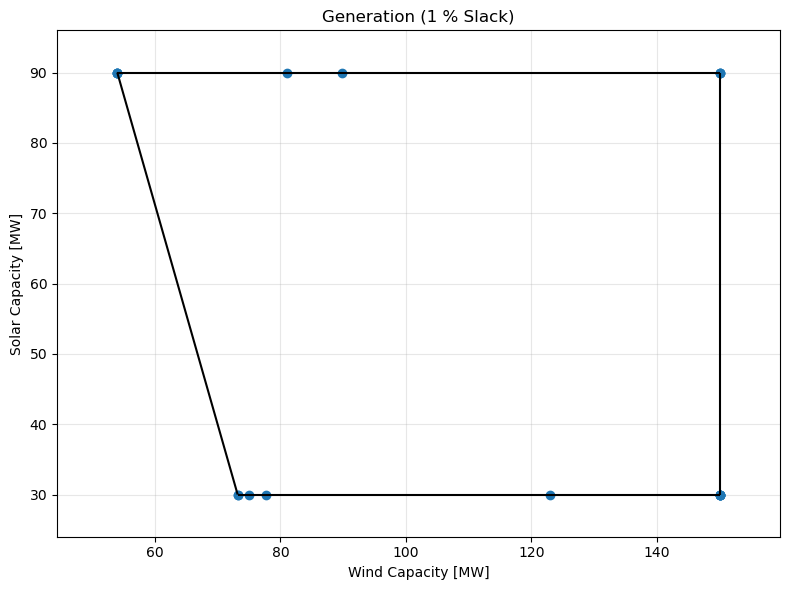

In [70]:

# Create a figure for the Storage trade-off
fig, ax = plt.subplots(figsize=(8, 6))

# Extract the storage coordinates
# Note: Ensure these column names match your pts dataframe (e.g., 'rondo' and 'battery')
pts_storage = n21_mga[1][['wind', 'solar']]
hull_storage = ConvexHull(pts_storage)

# Plot the convex hull
convex_hull_plot_2d(hull_storage, ax)

# Style the plot
ax.set_xlabel("Wind Capacity [MW]")
ax.set_ylabel("Solar Capacity [MW]")
ax.set_title("Generation (1 % Slack)")
ax.grid(True, alpha=0.3)

# Add a marker for the baseline (if you have the values)
# ax.scatter(opt_rondo, opt_battery, color='red', marker='*', s=200, label='Optimal')
plt.tight_layout()
plt.show()

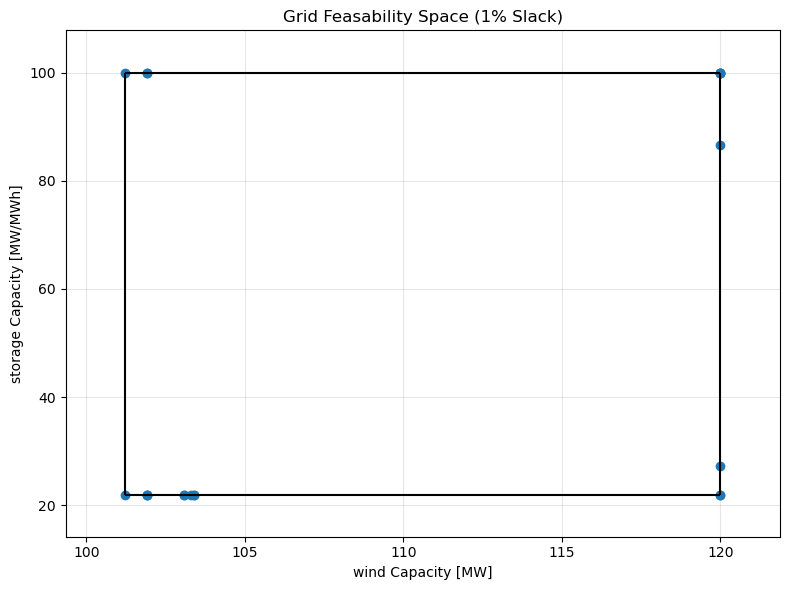

In [87]:
# Create a figure for the Storage trade-off
fig, ax = plt.subplots(figsize=(8, 6))

# Extract the storage coordinates
# Note: Ensure these column names match your pts dataframe (e.g., 'rondo' and 'battery')
pts_storage = n21_mga[1][['grid', 'battery']]
pts_storage2 = n21_mga[1][['grid', 'rondo']]

hull_storage = ConvexHull(pts_storage)
#hull_storage2 = ConvexHull(pts_storage2)

# Plot the convex hull
convex_hull_plot_2d(hull_storage, ax)
#convex_hull_plot_2d(hull_storage2, ax)

# Style the plot
ax.set_xlabel("wind Capacity [MW]")
ax.set_ylabel("storage Capacity [MW/MWh]")
ax.set_title("Grid Feasability Space (1% Slack)")
ax.grid(True, alpha=0.3)

# Add a marker for the baseline (if you have the values)
# ax.scatter(opt_rondo, opt_battery, color='red', marker='*', s=200, label='Optimal')
plt.tight_layout()
plt.show()

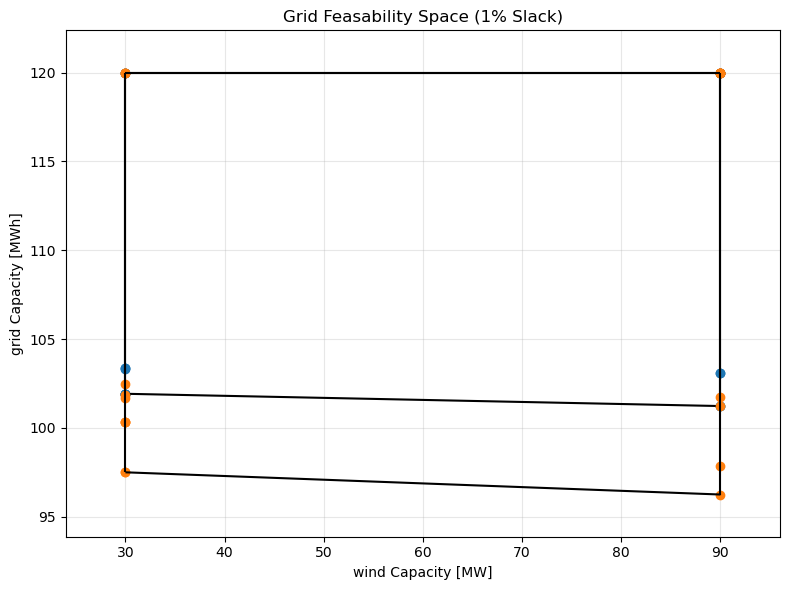

In [ ]:

# Create a figure for the Storage trade-off
fig, ax = plt.subplots(figsize=(8, 6))

# Extract the storage coordinates
# Note: Ensure these column names match your pts dataframe (e.g., 'rondo' and 'battery')
pts_storage = n21_mga[1][['wind', 'grid']]
pts_storage2 = n24_mga[1][['wind', 'grid']]
hull_storage = ConvexHull(pts_storage)
hull_storage2 = ConvexHull(pts_storage2)

# Plot the convex hull
convex_hull_plot_2d(hull_storage, ax)
convex_hull_plot_2d(hull_storage2, ax)

# Style the plot
ax.set_xlabel("wind Capacity [MW]")
ax.set_ylabel("grid Capacity [MWh]")
ax.set_title("Grid Feasability Space (1% Slack)")
ax.grid(True, alpha=0.3)

# Add a marker for the baseline (if you have the values)
# ax.scatter(opt_rondo, opt_battery, color='red', marker='*', s=200, label='Optimal')
plt.tight_layout()
plt.show()

In [130]:
n23_w_datacentre

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 9
 - Carrier: 20
 - Generator: 5
 - Link: 8
 - Load: 3
 - StorageUnit: 1
 - Store: 4
 - SubNetwork: 9
Snapshots: 8760

In [ ]:
n24_mga = run_mga_multi_dimensions(n24_w_datacentre, slack=0.01, num_directions=20)

In [ ]:
# 1. Run the multi-directional search
n24_mga = run_mga_multi_dimensions(n24_w_datacentre, slack=0.01, num_directions=20)
# 2. Display the first few points
#print(n24_mga.head())

Solving MGA in 20 directions | Slack: 1.0%


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\Pulin\AppData\Local\Temp\tmpljbccjbj.nc contains: stores, generators, loads, sub_networks, buses, links, storage_units, carriers


In [95]:
n24_w_datacentre.objective/1e6

77.24120124714572

In [172]:
n24_mga[1]

,wind,solar,rondo,battery,grid
0,76.045395,30.0,300.0,22.000000,101.690090
1,92.308093,90.0,100.0,86.573920,120.000000
2,150.000000,30.0,300.0,22.000000,100.334455
3,69.335435,30.0,100.0,22.000000,102.451535
4,150.000000,30.0,100.0,100.000000,120.000000
5,66.799300,90.0,300.0,22.000000,101.249710
6,150.000000,30.0,300.0,100.000000,97.502949
7,150.000000,90.0,300.0,100.000000,120.000000
8,119.032127,30.0,300.0,100.000000,120.000000
9,150.000000,90.0,100.0,100.000000,96.252844


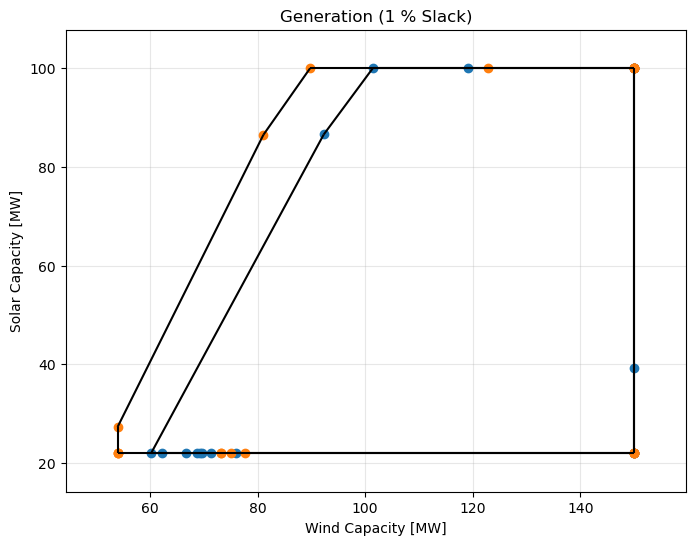

In [116]:
# Create a figure for the Storage trade-off
fig, ax = plt.subplots(figsize=(8, 6))

# Extract the storage coordinates
# Note: Ensure these column names match your pts dataframe (e.g., 'rondo' and 'battery')
pts_storage = n24_mga[1][['wind', 'battery']]
pts_storage2 = n21_mga[1][['wind', 'battery']]
hull_storage = ConvexHull(pts_storage)
hull_storage2 = ConvexHull(pts_storage2)

# Plot the convex hull
convex_hull_plot_2d(hull_storage, ax)
convex_hull_plot_2d(hull_storage2, ax)

# Style the plot
ax.set_xlabel("Wind Capacity [MW]")
ax.set_ylabel("Solar Capacity [MW]")
ax.set_title("Generation (1 % Slack)")
ax.grid(True, alpha=0.3)

# Add a marker for the baseline (if you have the values)
# ax.scatter(opt_rondo, opt_battery, color='red', marker='*', s=200, label='Optimal')
# plt.tight_layout()
plt.show()

In [164]:
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
import numpy as np

def plot_mga_evolution_final(df_list, x_col, y_col, labels, colors=None, title=None):
    """
    Plots MGA spaces for multiple years with a single legend entry per year.
    """
    if colors is None:
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # Standard professional palette
    
    fig, ax = plt.subplots(figsize=(11, 7), dpi=100)

    for df, label, color in zip(df_list, labels, colors):
        # Extract the coordinate points (assuming df is the [1] index of the MGA output)
        data = df[1] if isinstance(df, (tuple, list)) else df
        points = data[[x_col, y_col]].values
        
        # Calculate Convex Hull
        hull = ConvexHull(points)
        hull_points = points[hull.vertices]
        hull_points = np.vstack((hull_points, hull_points[0])) 
        
        # 1. Shaded area (No label)
        #ax.fill(hull_points[:,0], hull_points[:,1], color=color, alpha=0.12)
        
        # 2. Boundary Line (This gets the SINGLE label for the legend)
        ax.plot(hull_points[:,0], hull_points[:,1], color=color, lw=2.5, 
                label=f"{label}", zorder=5)
        
        # 3. MGA Direction Points (label=None ensures these stay out of the legend)
        ax.scatter(points[:,0], points[:,1], color=color, s=30, edgecolors='white', 
                   linewidth=0.6, zorder=10, label=None)

    # Dictionary for automated unit formatting
    unit_map = {
        "wind": "MW", "solar": "MW", "grid": "MW", 
        "battery": "MW", "rondo": "MWh"
    }
    x_unit = unit_map.get(x_col.lower(), "MW")
    y_unit = unit_map.get(y_col.lower(), "MWh")

    # Final Styling
    ax.set_xlabel(f"{x_col.capitalize()} Capacity [{x_unit}]", fontweight='bold', fontsize=11)
    ax.set_ylabel(f"{y_col.capitalize()} Capacity [{y_unit}]", fontweight='bold', fontsize=11)
    
    if title:
        ax.set_title(title, fontsize=15, pad=25, fontweight='bold')
    
    ax.grid(True, linestyle='--', alpha=0.35, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Place legend neatly outside to the right
    ax.legend(title="Feasibility Space", frameon=False, 
              fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    return fig, ax

# Example usage:
# plot_mga_evolution_final([n21_mga, n22_mga, n23_mga, n24_mga], 'wind', 'grid', years, title="Infrastructure Evolution")

In [216]:
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
import numpy as np

def plot_mga_evolution_final(df_list, x_col, y_col, labels, colors=None, title=None):
    """
    Plots MGA spaces for multiple years with internal baseline definitions.
    """
    if colors is None:
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    # Internal definition of optimal baseline capacities (Current Installed)
    # Based on your statistics.optimal_capacity() outputs
    baselines = {
        "2021": {"wind": 54.0, "solar": 30.0, "rondo": 100.0, "battery": 22.0, "grid": 84.0},
        "2022": {"wind": 54.0, "solar": 30.0, "rondo": 100.0, "battery": 22, "grid": 84},
        "2023": {"wind": 54.0, "solar": 30.0, "rondo": 100.0, "battery": 22.0, "grid": 84},
        "2024": {"wind": 54.0, "solar": 30.0, "rondo": 100.0, "battery": 22.0, "grid": 84}
    }

    fig, ax = plt.subplots(figsize=(11, 7), dpi=100)

    for df, label, color in zip(df_list, labels, colors):
        data = df[1] if isinstance(df, (tuple, list)) else df
        points = data[[x_col, y_col]].values
        
        # 1. Calculate and Plot Convex Hull
        hull = ConvexHull(points)
        hull_points = points[hull.vertices]
        hull_points = np.vstack((hull_points, hull_points[0])) 
        
        # Optional: Uncomment if you want shaded kites
        # ax.fill(hull_points[:,0], hull_points[:,1], color=color, alpha=0.1)
        
        # 2. Plot Boundary Line
        ax.plot(hull_points[:,0], hull_points[:,1], color=color, lw=2.5, 
                label=f"{label}", zorder=5)
        
        # 3. Plot MGA Direction Points
        ax.scatter(points[:,0], points[:,1], color=color, s=30, edgecolors='white', 
                   linewidth=0.6, zorder=10, label=None)

        # 4. Plot Internal Baseline Marker
        # Checks if the label (e.g., '2024') exists in our dictionary
        if label in baselines:
            bx = baselines[label].get(x_col.lower())
            by = baselines[label].get(y_col.lower())
            
            if bx is not None and by is not None:
                ax.scatter(bx, by, color=color, marker='*', s=250, edgecolors='black', 
                           linewidth=1.0, zorder=20, label=None)

    # Unit Mapping
    unit_map = {"wind": "MW", "solar": "MW", "grid": "MW", "battery": "MW", "rondo": "MWh"}
    x_unit = unit_map.get(x_col.lower(), "MW")
    y_unit = unit_map.get(y_col.lower(), "MWh")

    # Final Styling
    ax.set_xlabel(f"{x_col.capitalize()} Capacity [{x_unit}]", fontweight='bold', fontsize=11)
    ax.set_ylabel(f"{y_col.capitalize()} Capacity [{y_unit}]", fontweight='bold', fontsize=11)
    
    if title:
        ax.set_title(title, fontsize=15, pad=25, fontweight='bold')
    
    ax.grid(True, linestyle='--', alpha=0.35, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.legend(title="Feasibility Space", frameon=False, 
              fontsize=10, bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    return fig, ax

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Wind Capacity [MW]', ylabel='Grid Capacity [MW]'>)

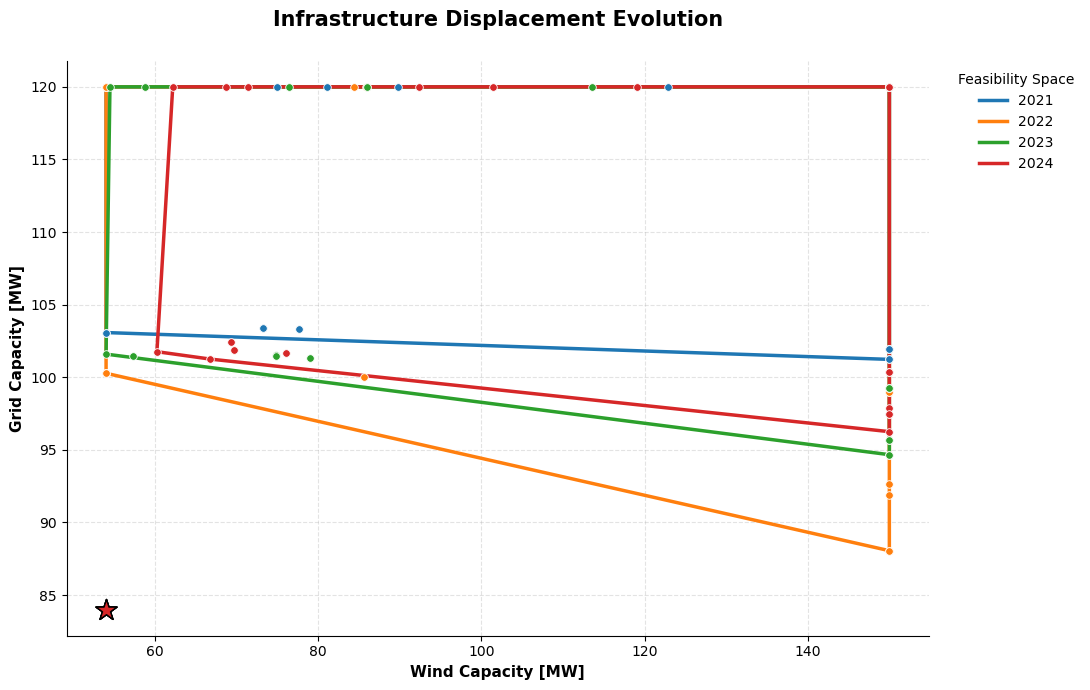

In [217]:

# Example usage:
plot_mga_evolution_final([n21_mga[1], n22_mga[1],n23_mga[1],n24_mga[1]], 'wind', 'grid', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Grid Capacity [MW]', ylabel='Battery Capacity [MW]'>)

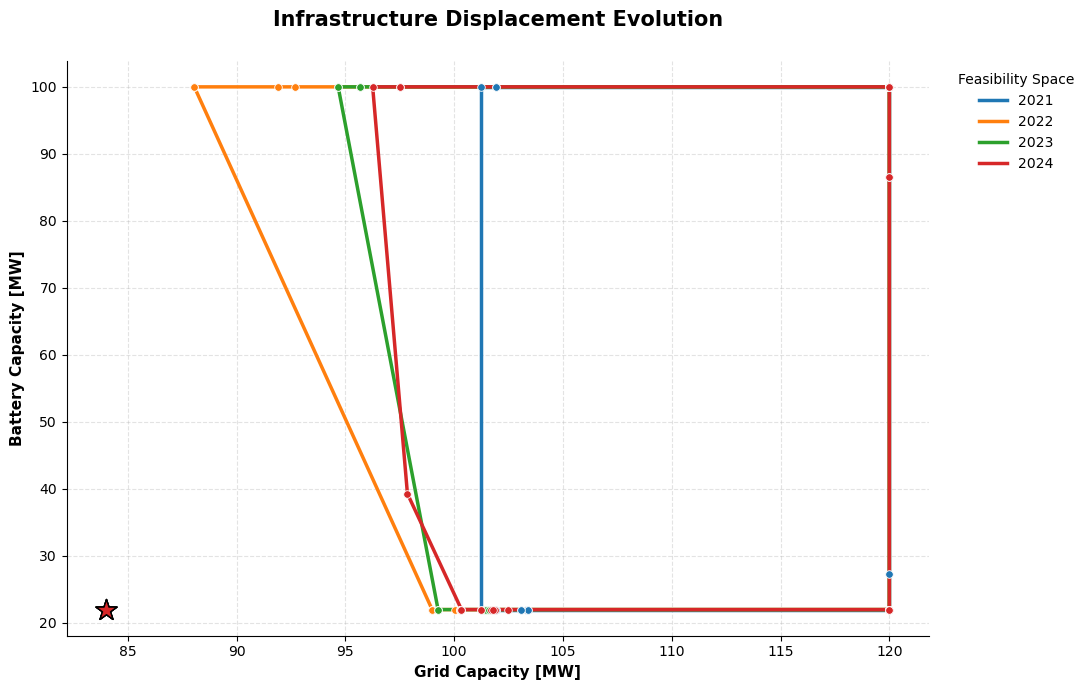

In [233]:

plot_mga_evolution_final([n21_mga[1], n22_mga[1],n23_mga[1],n24_mga[1]], 'grid', 'battery', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Wind Capacity [MW]', ylabel='Solar Capacity [MW]'>)

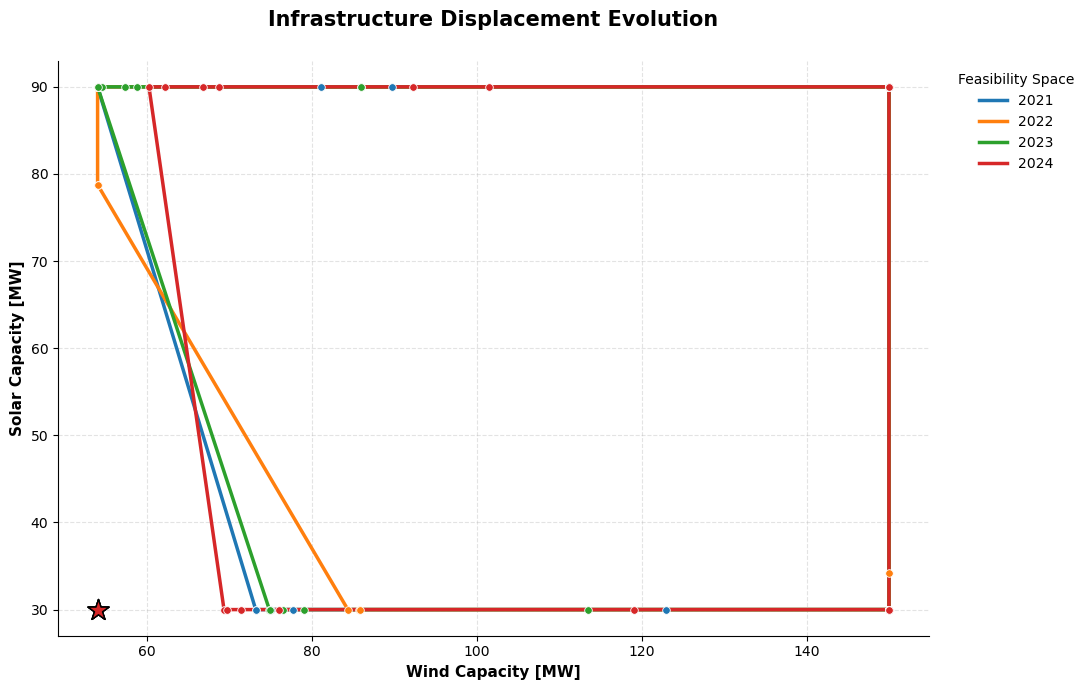

In [218]:

plot_mga_evolution_final([n21_mga[1], n22_mga[1],n23_mga[1],n24_mga[1]], 'wind', 'solar', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Wind Capacity [MW]', ylabel='Battery Capacity [MW]'>)

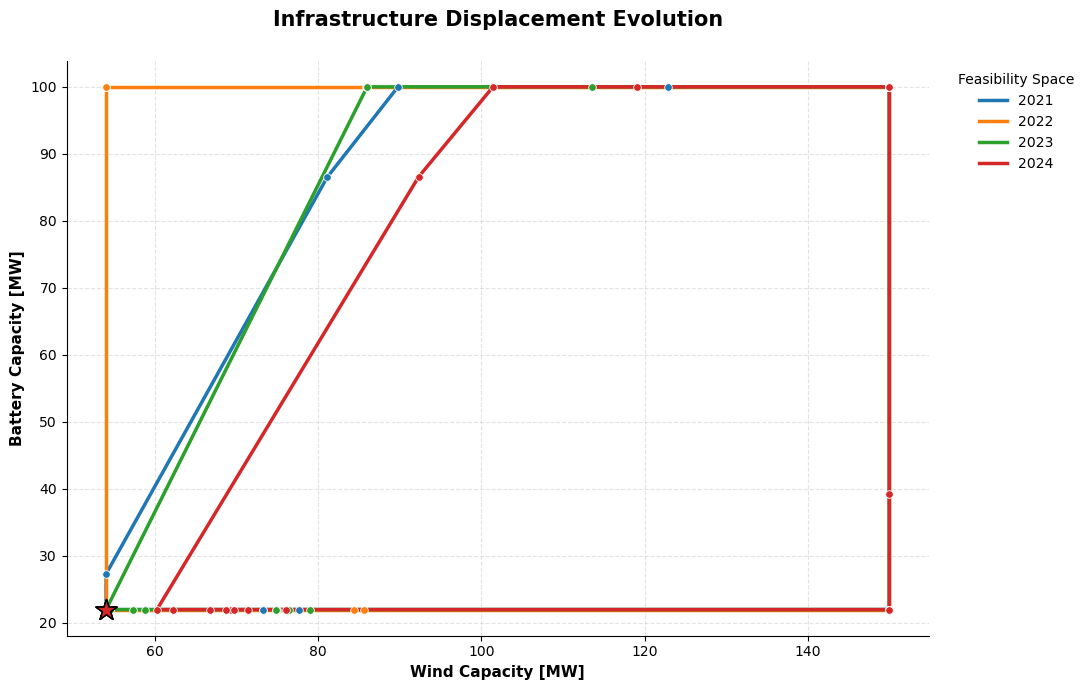

In [219]:

plot_mga_evolution_final([n21_mga[1], n22_mga[1],n23_mga[1],n24_mga[1]], 'wind', 'battery', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Grid Capacity [MW]', ylabel='Rondo Capacity [MWh]'>)

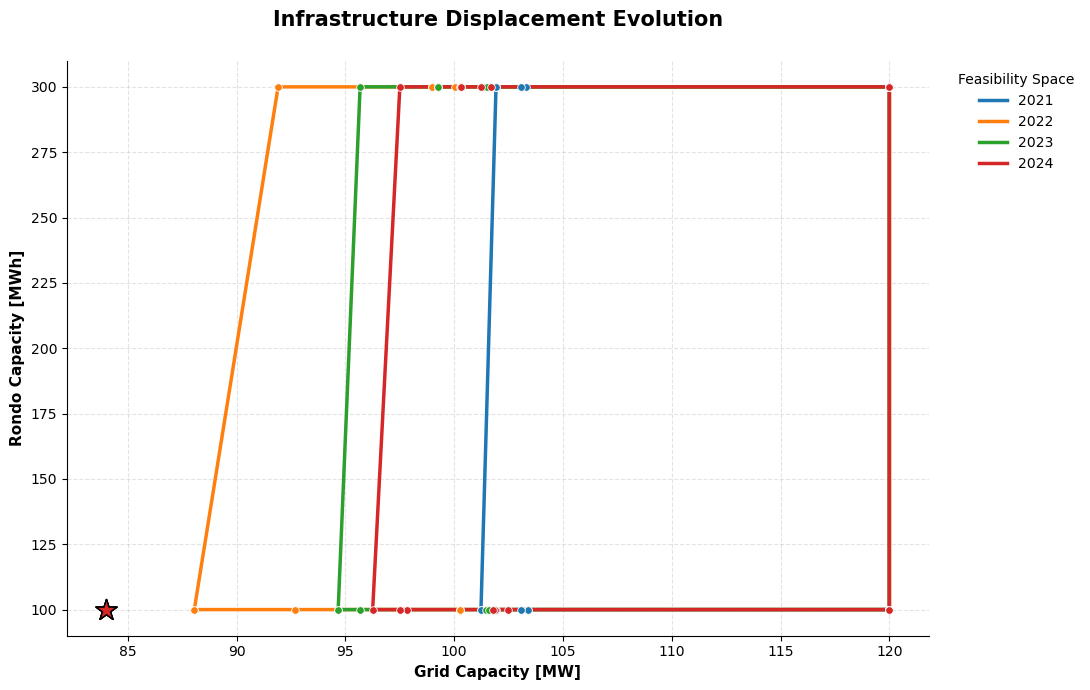

In [220]:

plot_mga_evolution_final([n21_mga[1], n22_mga[1],n23_mga[1],n24_mga[1]], 'grid', 'rondo', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Battery Capacity [MW]', ylabel='Rondo Capacity [MWh]'>)

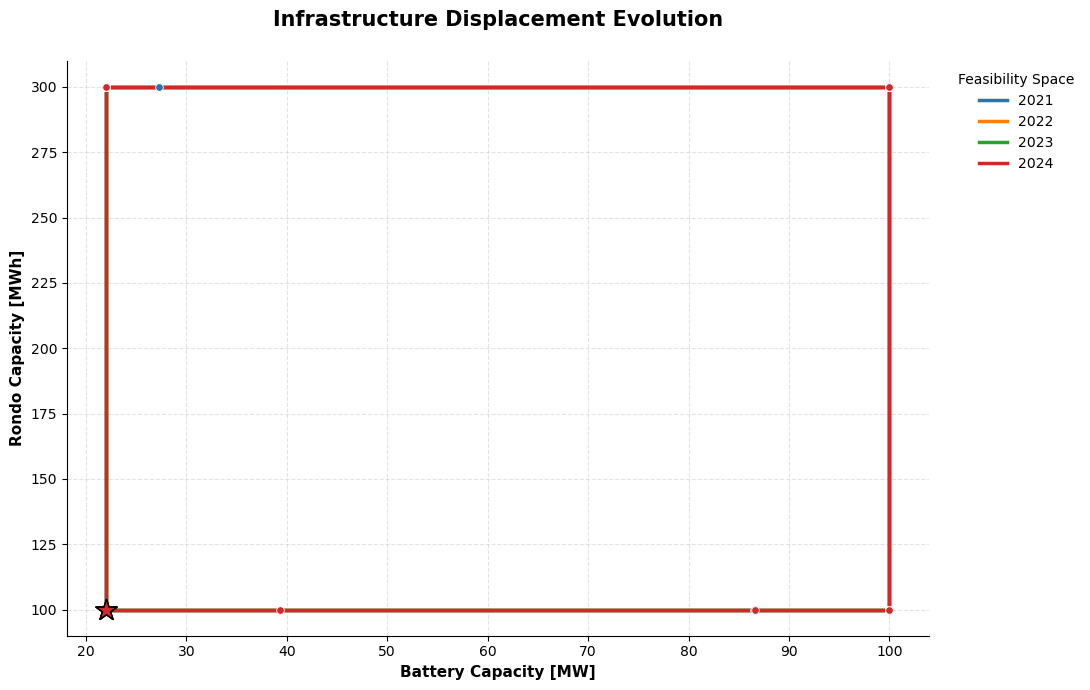

In [221]:

plot_mga_evolution_final([n21_mga[1], n22_mga[1],n23_mga[1],n24_mga[1]], 'battery', 'rondo', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Wind Capacity [MW]', ylabel='Rondo Capacity [MWh]'>)

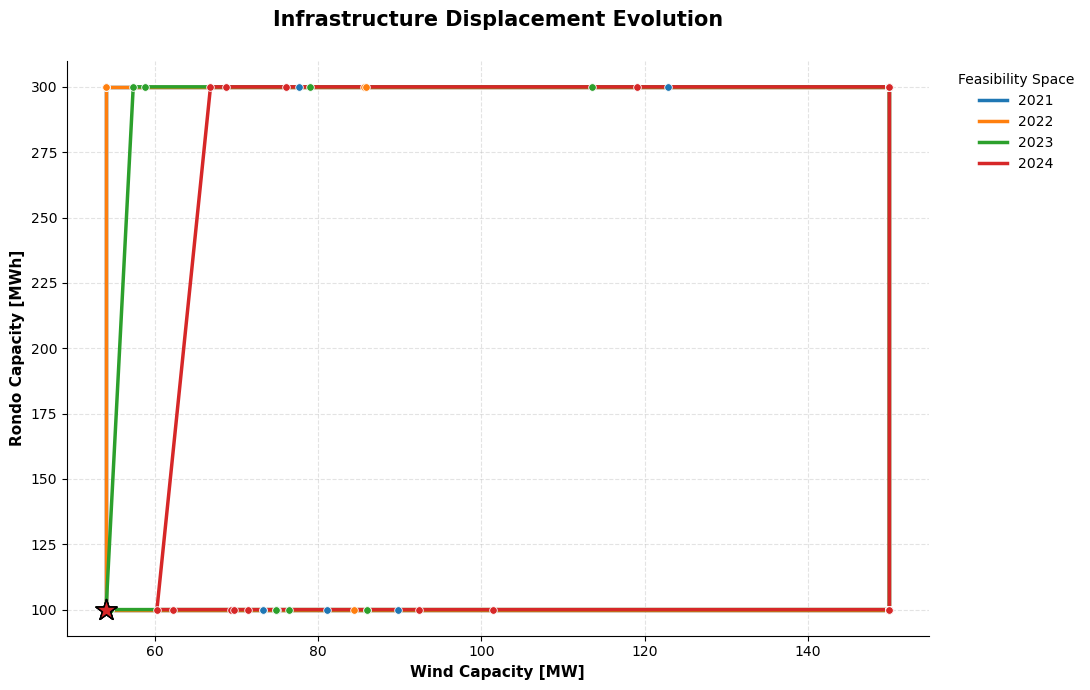

In [229]:

plot_mga_evolution_final([n21_mga[1], n22_mga[1],n23_mga[1],n24_mga[1]], 'wind', 'rondo', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

In [425]:
def plot_heat_production(n, title="Annual Heat Production"):
    """
    Plots the annual heat production for RONDO, Electric Boiler, 
    NG Boiler, and Pyrolysis from a PyPSA network.
    """
    # 1. Define the links we are looking for
    target_links = {
        #"RONDO": "Heat_Exchanger_Rondo",
        "RONDO": "TES_Rondo_to_Heat_Bus_Skive",
        "Electric Boiler": "Boiler_Skive",
        "NG Boiler": "NG boiler",
        "Pyrolysis": "pyrolysis"
    }
    
    # 2. Extract values safely (handles missing links with 0.0)
    data = {}
    for label, link_name in target_links.items():
        if link_name in n.links.index:
            # Note: we use .get() or check existence to avoid KeyErrors
            # Summing p1 (output) and converting MW -> GWh
            data[label] = (-n.links_t.p1[link_name].sum()) / 1e3
        else:
            data[label] = 0.0
            
    annual_heat = pd.Series(data)
    total_gwh = annual_heat.sum()
    
    # Avoid division by zero if network is empty/unsolved
    if total_gwh == 0:
        print("Warning: Total heat production is 0. Check if the network is solved.")
        return
    
    # 3. Aesthetics & Sorting
    nice_colors = {'RONDO': '#FFB74D', 'Electric Boiler': '#64B5F6', 
                   'NG Boiler': '#E57373', 'Pyrolysis': '#81C784'}
    
    annual_heat_sorted = annual_heat.sort_values(ascending=False)
    plot_colors = [nice_colors[idx] for idx in annual_heat_sorted.index]
    
    # 4. Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(annual_heat_sorted.index, annual_heat_sorted.values, 
                  color=plot_colors, edgecolor='white', linewidth=1)

    # 5. Data Labels
    for bar in bars:
        height = bar.get_height()
        label_idx = annual_heat_sorted.index[bars.index(bar)]
        pct = (height / total_gwh * 100)
        
        ax.text(bar.get_x() + bar.get_width()/2., height + (total_gwh * 0.01),
                f'{height:.1f} GWh\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Formatting
    ax.set_title(title, fontsize=16, fontweight='bold', pad=25)
    ax.set_ylabel("Total Heat Production [GWh]", fontsize=13)
    ax.set_xlabel("Technology", fontsize=13)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', alpha=0.6)
    
    plt.ylim(0, annual_heat_sorted.max() * 1.2)
    plt.tight_layout()
    plt.show()


In [594]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_heat_comparison(networks_dict, title="Annual Heat Production Comparison"):
    """
    Compares annual heat production across multiple PyPSA networks.
    networks_dict: {'Label1': n1, 'Label2': n2, ...}
    """
    target_links = {
        "RONDO": "TES_Rondo_to_Heat_Bus_Skive",
        "Electric Boiler": "Boiler_Skive",
        "NG Boiler": "NG boiler",
        "Pyrolysis": "pyrolysis"
    }
    
    # 1. Aggregate data into a DataFrame
    all_data = []
    for label, n in networks_dict.items():
        year_data = {"Scenario": label}
        for tech, link_name in target_links.items():
            if link_name in n.links.index:
                # MW -> GWh
                year_data[tech] = (-n.links_t.p1[link_name].sum()) / 1e3
            else:
                year_data[tech] = 0.0
        all_data.append(year_data)
    
    df = pd.DataFrame(all_data).set_index("Scenario")
    
    # 2. Colors matching your previous aesthetic
    nice_colors = ['#FFB74D', '#64B5F6', '#E57373', '#81C784'] # Rondo, El-Boiler, NG, Pyro
    
    # 3. Plotting
    ax = df.plot(kind='bar', stacked=True, figsize=(12, 7), color=nice_colors, edgecolor='white', width=0.7)

    # 4. Annotate totals and percentages
    for i, (idx, row) in enumerate(df.iterrows()):
        total = row.sum()
        # Total GWh label on top of stack
        ax.text(i, total + (df.values.max() * 0.02), f"\n{total:.1f} GWh", 
                ha='center', va='bottom', fontweight='bold', fontsize=10)
        
        # Optional: Add small % labels inside the segments
        cumulative = 0
        for val in row:
            if val > (total * 0.01): # Only label if segment is > 5% of total
                ax.text(i, cumulative + val/2, f'{val/total*100:.0f}%', 
                        ha='center', va='center', color='white', fontweight='bold', fontsize=9)
            cumulative += val

    # Formatting
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel("Annual Heat Production [GWh]", fontsize=12)
    ax.set_xlabel("Scenario", fontsize=12)
    ax.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# How to call it:

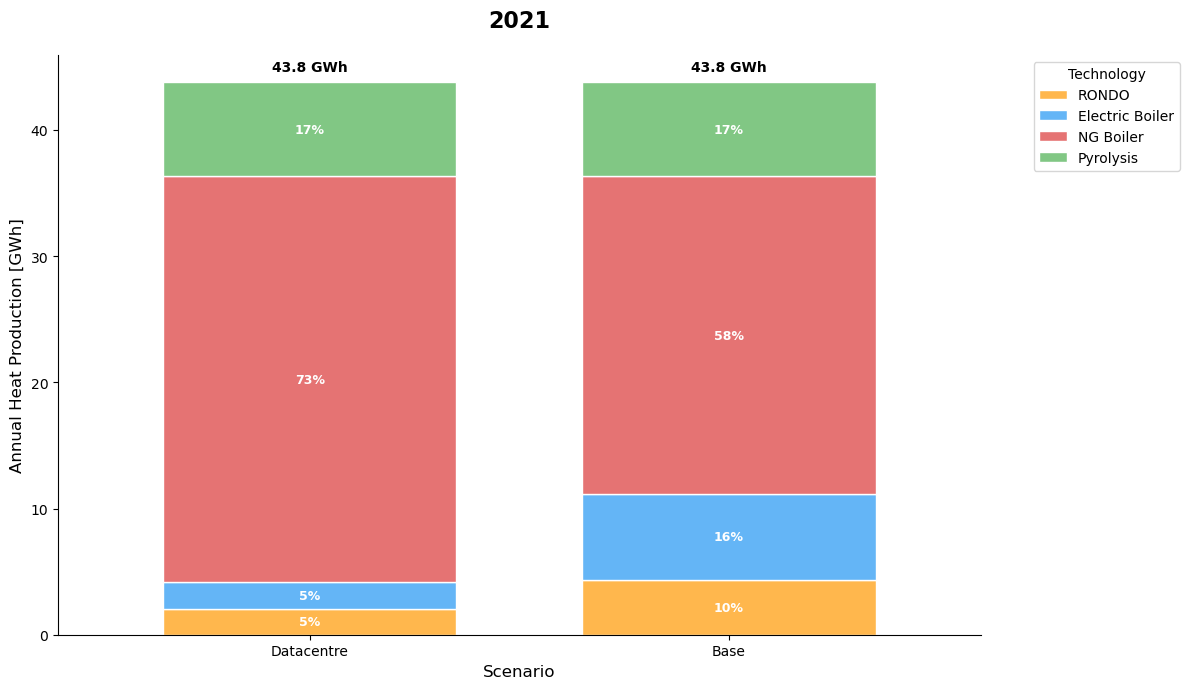

In [595]:
my_networks = {"Datacentre": n21_w_datacentre,"Base": n21_wo_datacentre}
plot_heat_comparison(my_networks,title = "2021")

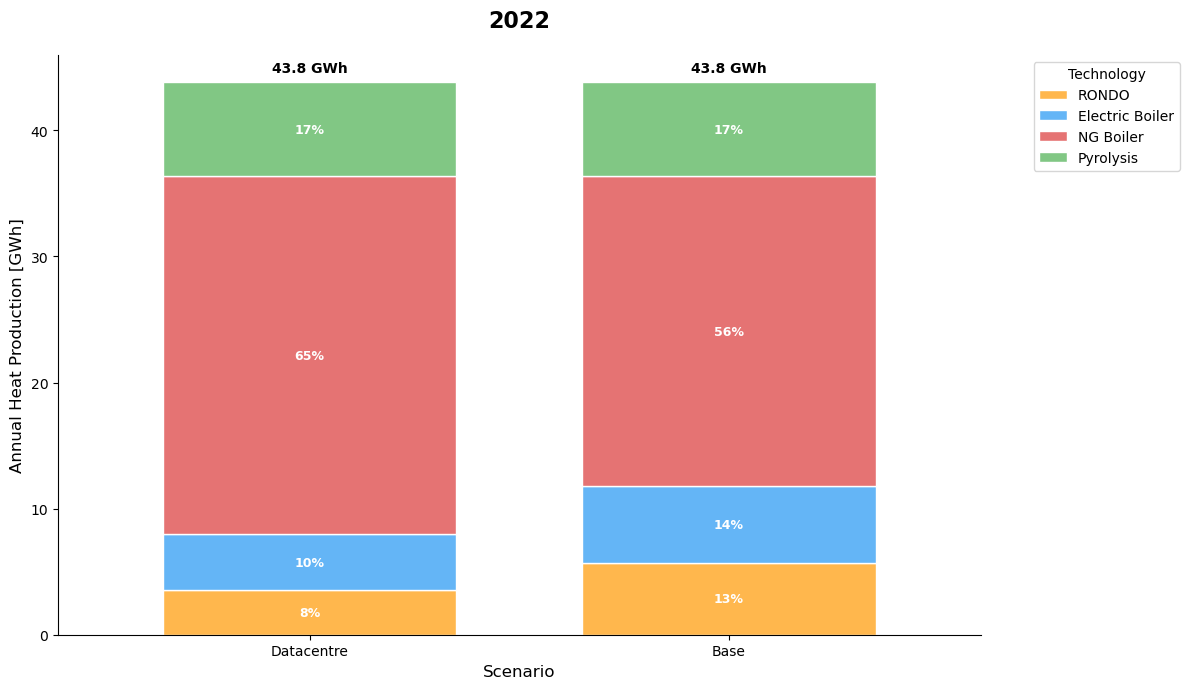

In [596]:
my_networks = {"Datacentre": n22_w_datacentre,"Base": n22_wo_datacentre}
plot_heat_comparison(my_networks,title = "2022")

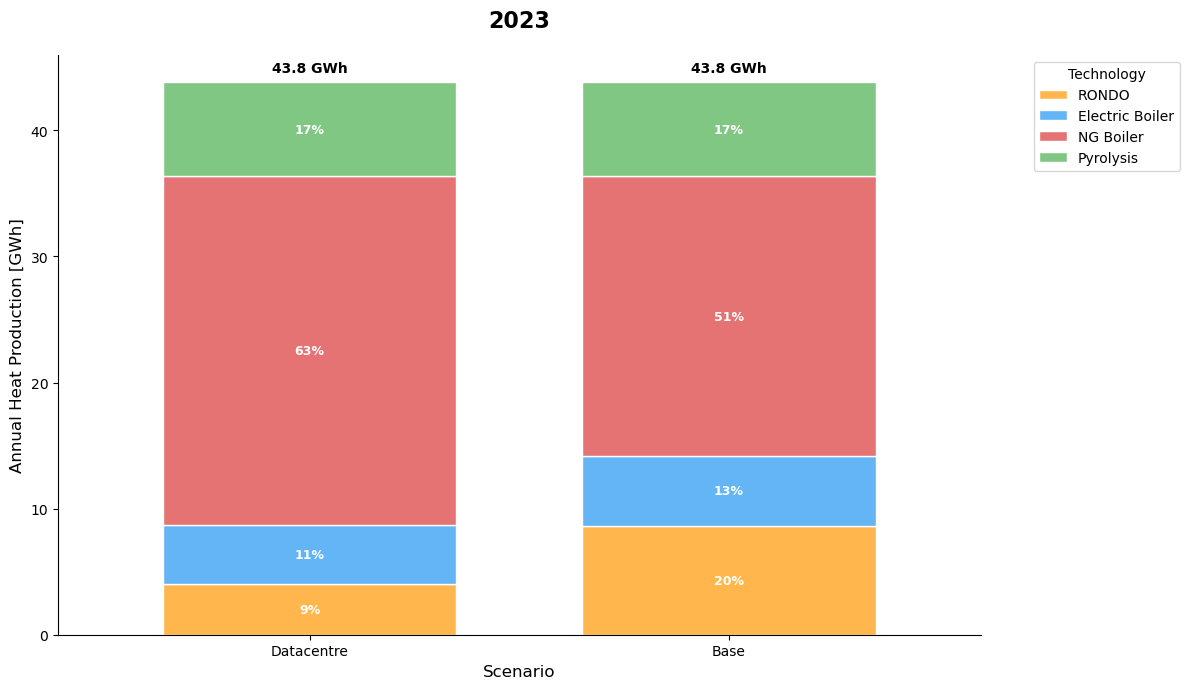

In [597]:
my_networks = {"Datacentre": n23_w_datacentre,"Base": n23_wo_datacentre}
plot_heat_comparison(my_networks,title = "2023")

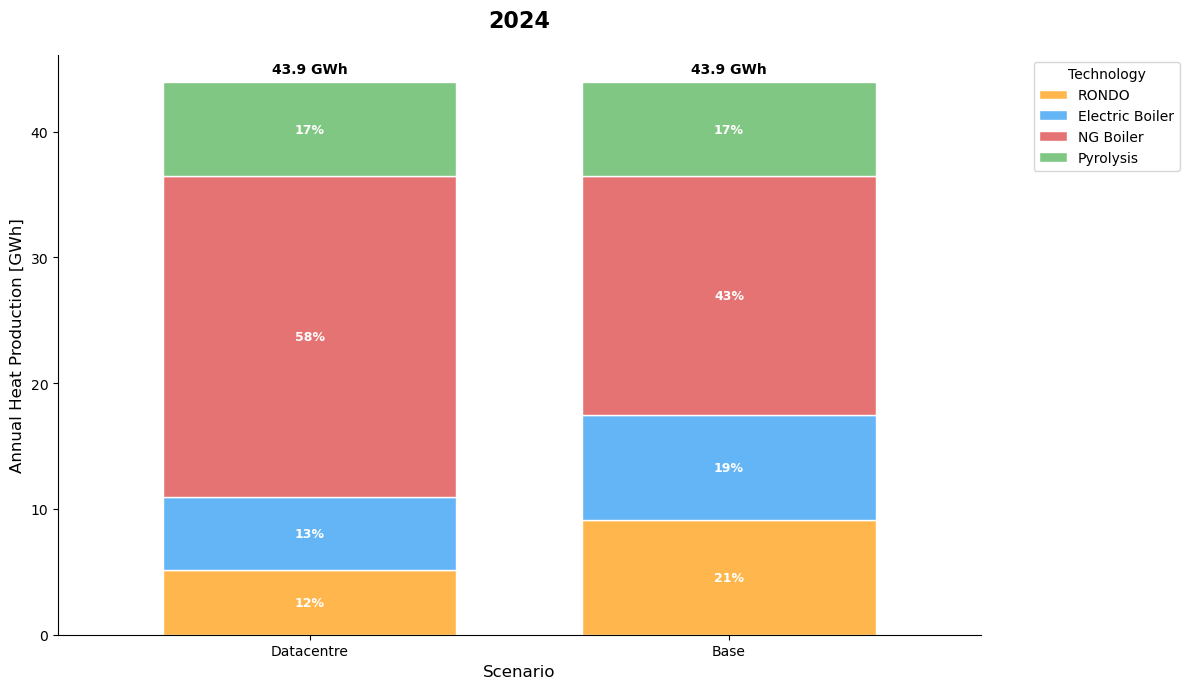

In [598]:
my_networks = {"Datacentre": n24_w_datacentre,"Base": n24_wo_datacentre}
plot_heat_comparison(my_networks,title = "2024")

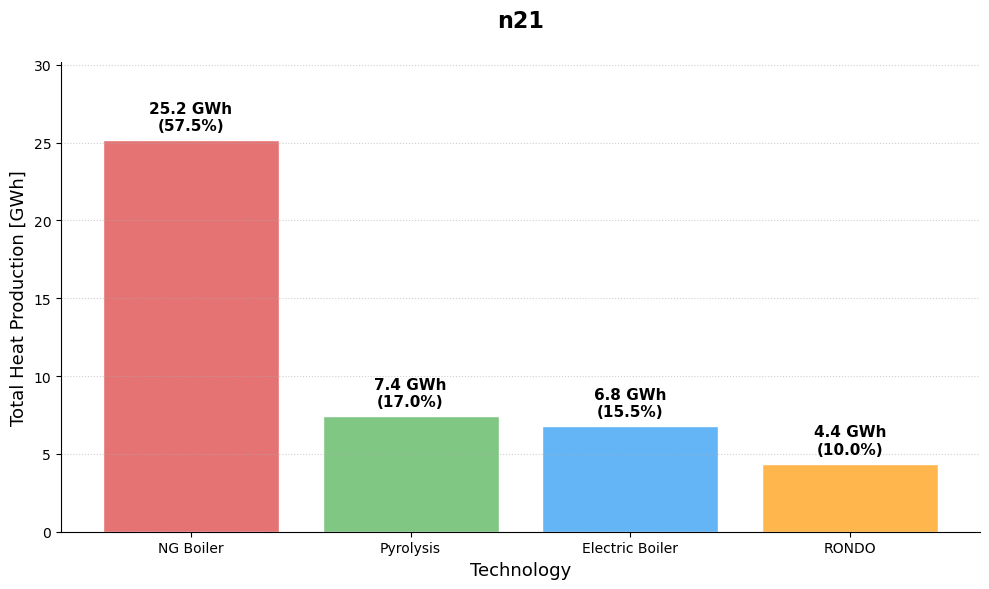

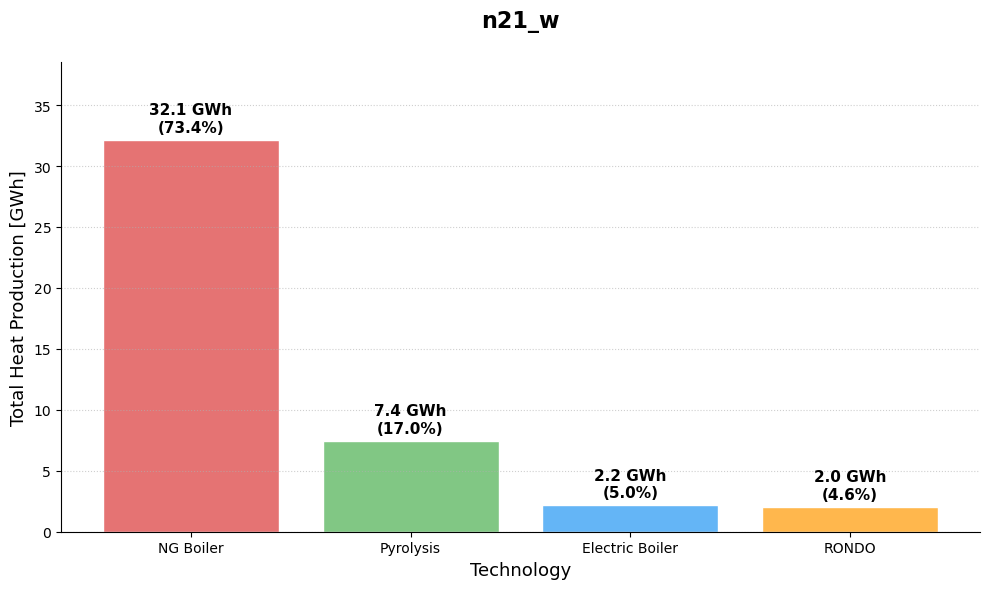

In [574]:
plot_heat_production(n21_wo_datacentre,title = "n21")
plot_heat_production(n21_w_datacentre,title = "n21_w")

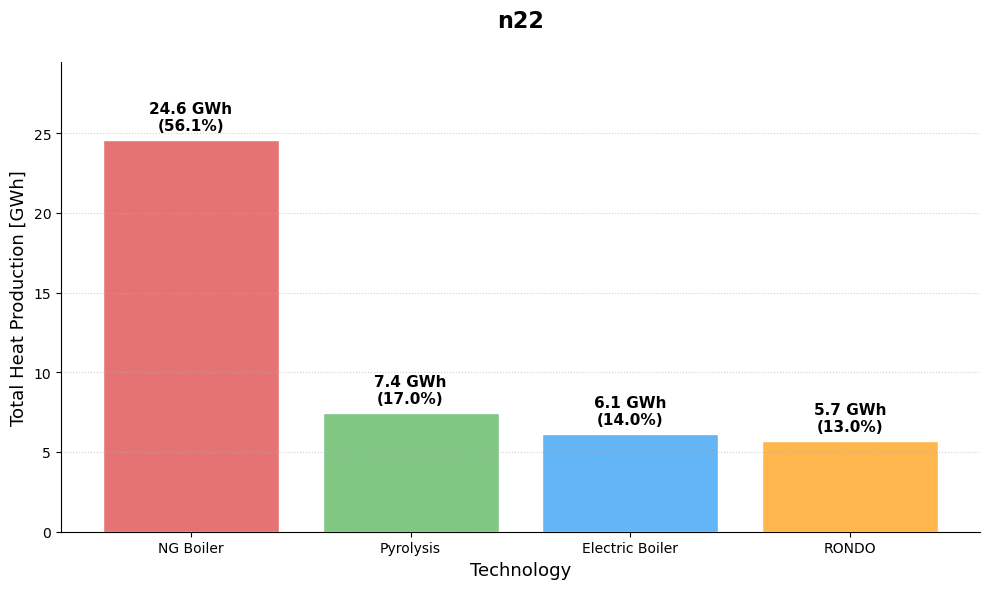

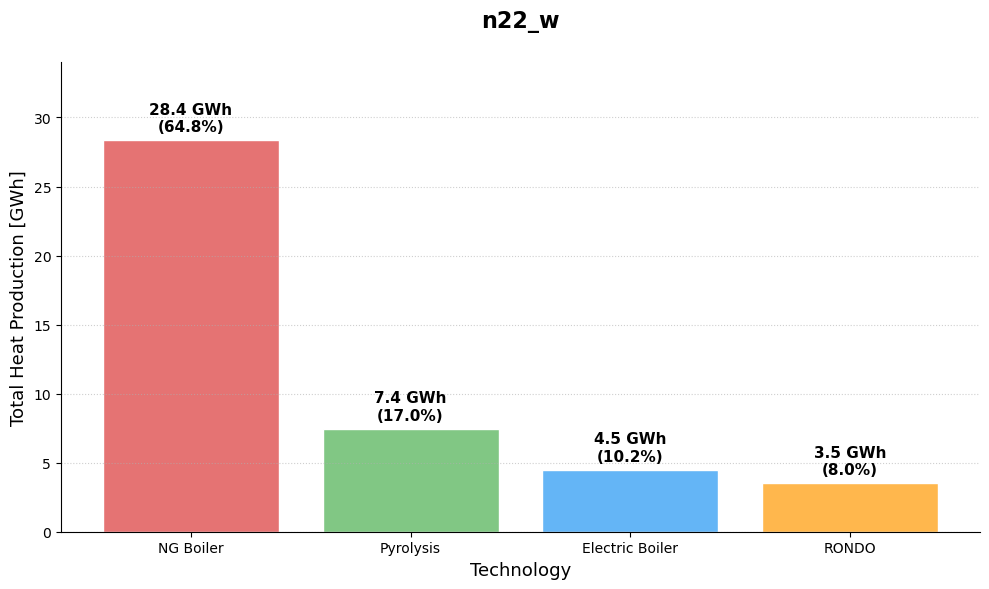

In [575]:
plot_heat_production(n22_wo_datacentre,title = "n22")
plot_heat_production(n22_w_datacentre,title = "n22_w")

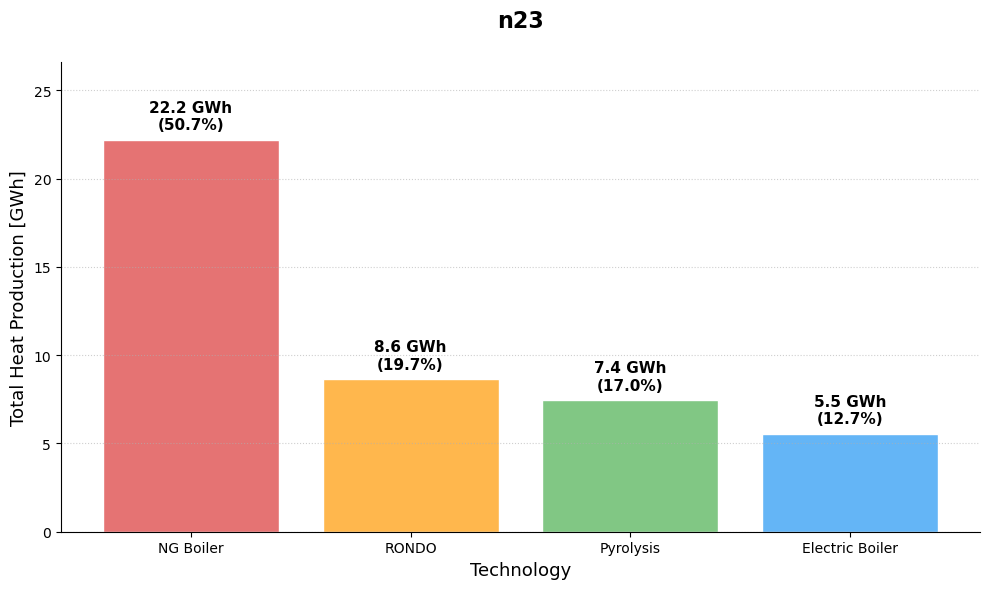

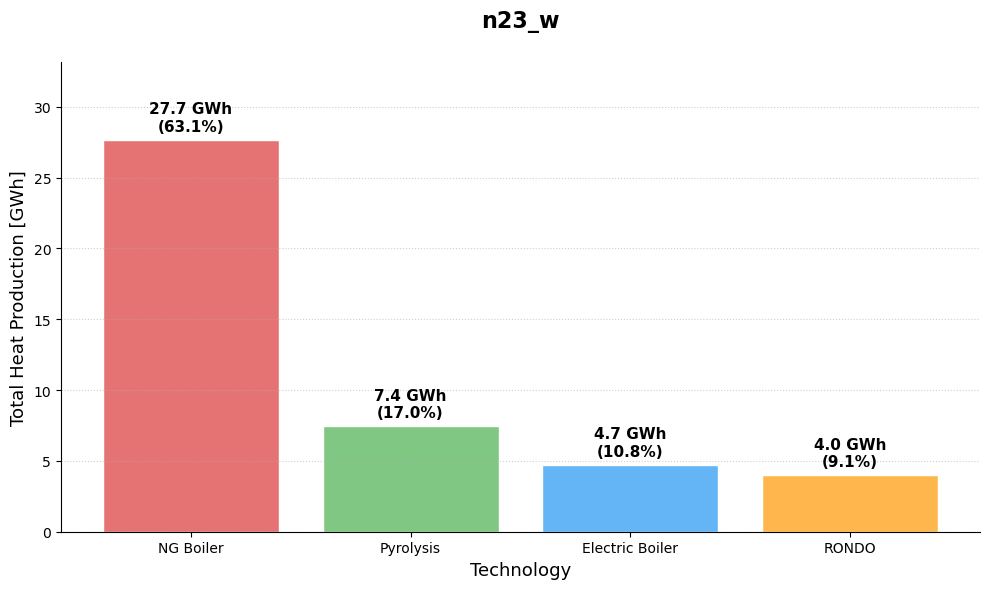

In [576]:
plot_heat_production(n23_wo_datacentre,title = "n23")
plot_heat_production(n23_w_datacentre,title = "n23_w")

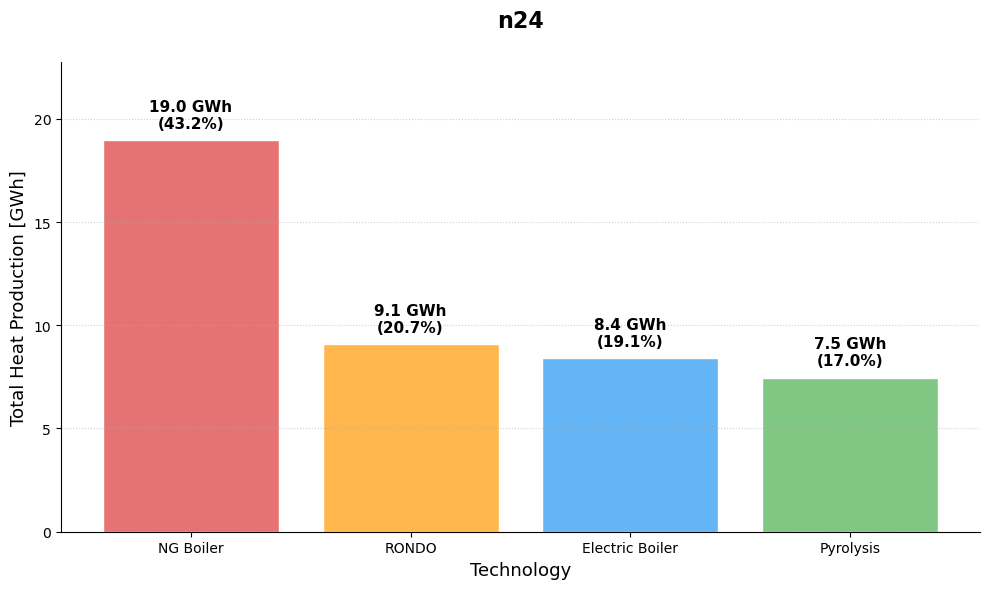

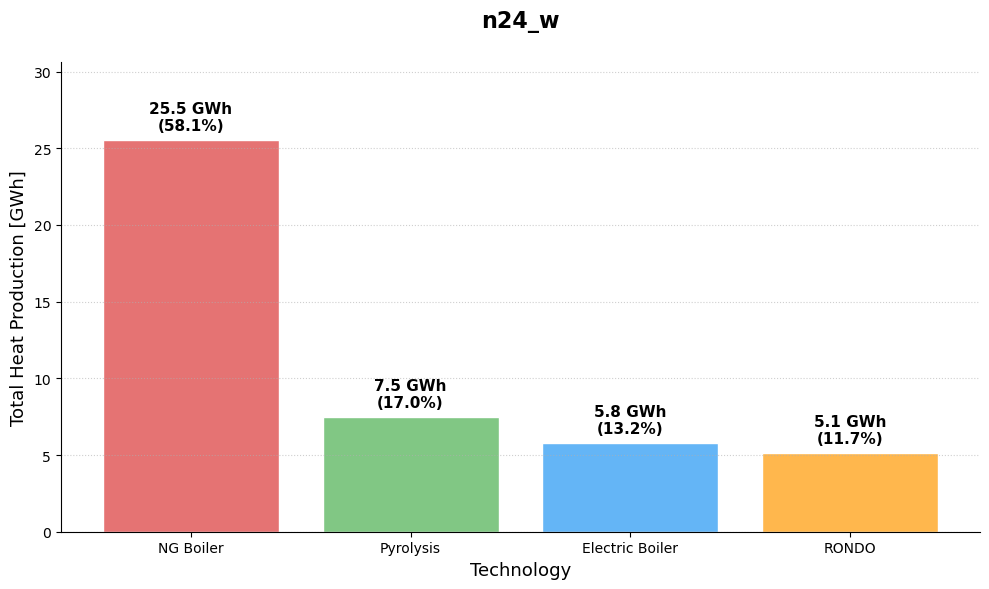

In [577]:
plot_heat_production(n24_wo_datacentre,title = "n24")
plot_heat_production(n24_w_datacentre,title = "n24_w")

# MGA part II

In [163]:
# 5 % Slack
n21_mga_05 = run_mga_multi_dimensions(n21_w_datacentre, slack=0.05, num_directions=20)
n22_mga_05 = run_mga_multi_dimensions(n22_w_datacentre, slack=0.05, num_directions=20)
n23_mga_05 = run_mga_multi_dimensions(n23_w_datacentre, slack=0.05, num_directions=20)
n24_mga_05 = run_mga_multi_dimensions(n24_w_datacentre, slack=0.05, num_directions=20)

Solving MGA in 20 directions | Slack: 5.0%


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\Pulin\AppData\Local\Temp\tmp9t2inc1j.nc contains: stores, generators, loads, sub_networks, buses, links, storage_units, carriers


Solving MGA in 20 directions | Slack: 5.0%


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\Pulin\AppData\Local\Temp\tmpo5jhyn2x.nc contains: stores, generators, loads, sub_networks, buses, links, storage_units, carriers


Solving MGA in 20 directions | Slack: 5.0%


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\Pulin\AppData\Local\Temp\tmpklq5y6er.nc contains: stores, generators, loads, sub_networks, buses, links, storage_units, carriers


Solving MGA in 20 directions | Slack: 5.0%


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\Pulin\AppData\Local\Temp\tmpqqf3yqoq.nc contains: stores, generators, loads, sub_networks, buses, links, storage_units, carriers


(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Wind Capacity [MW]', ylabel='Grid Capacity [MW]'>)

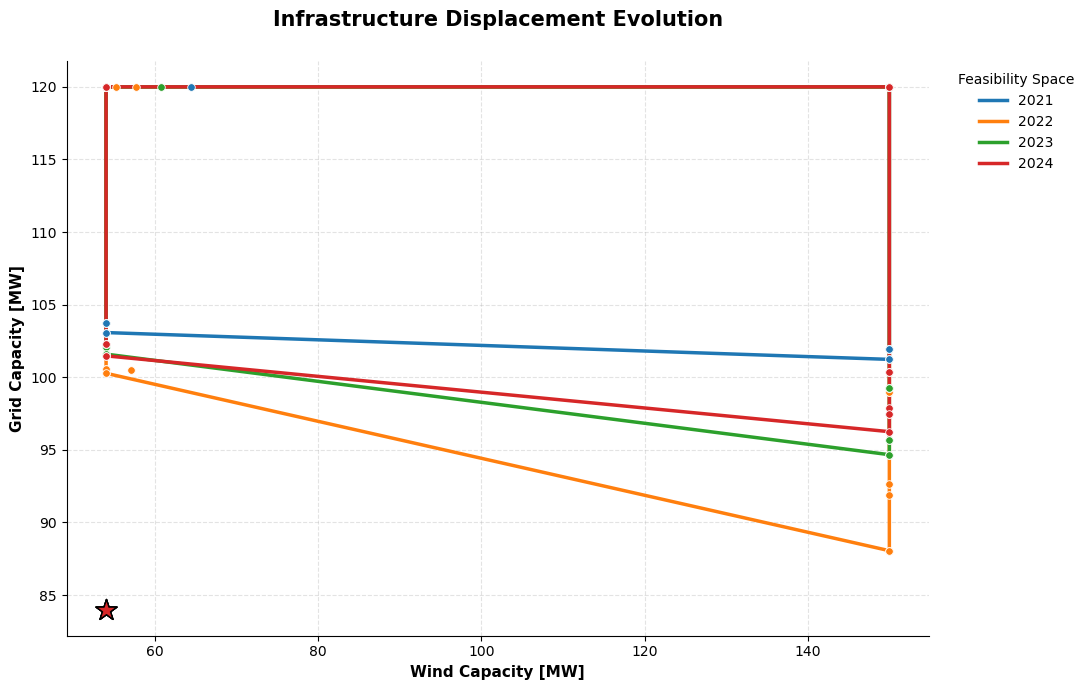

In [223]:

plot_mga_evolution_final([n21_mga_05[1], n22_mga_05[1],n23_mga_05[1],n24_mga_05[1]], 'wind', 'grid', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Wind Capacity [MW]', ylabel='Solar Capacity [MW]'>)

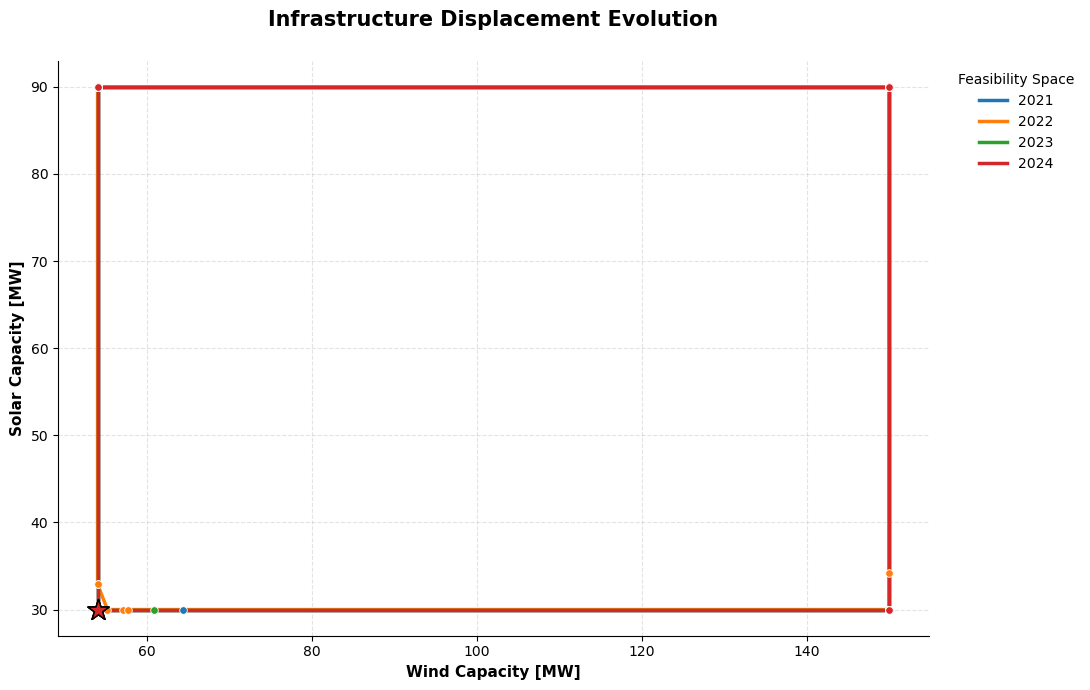

In [224]:

plot_mga_evolution_final([n21_mga_05[1], n22_mga_05[1],n23_mga_05[1],n24_mga_05[1]], 'wind', 'solar', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Wind Capacity [MW]', ylabel='Battery Capacity [MW]'>)

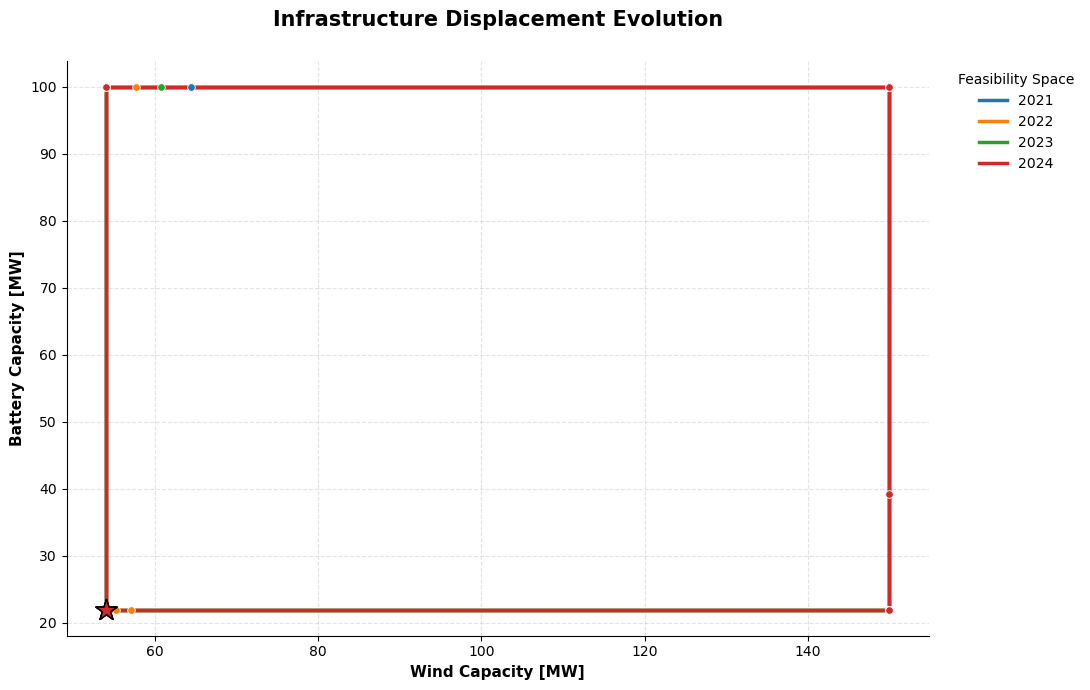

In [225]:

plot_mga_evolution_final([n21_mga_05[1], n22_mga_05[1],n23_mga_05[1],n24_mga_05[1]], 'wind', 'battery', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Grid Capacity [MW]', ylabel='Rondo Capacity [MWh]'>)

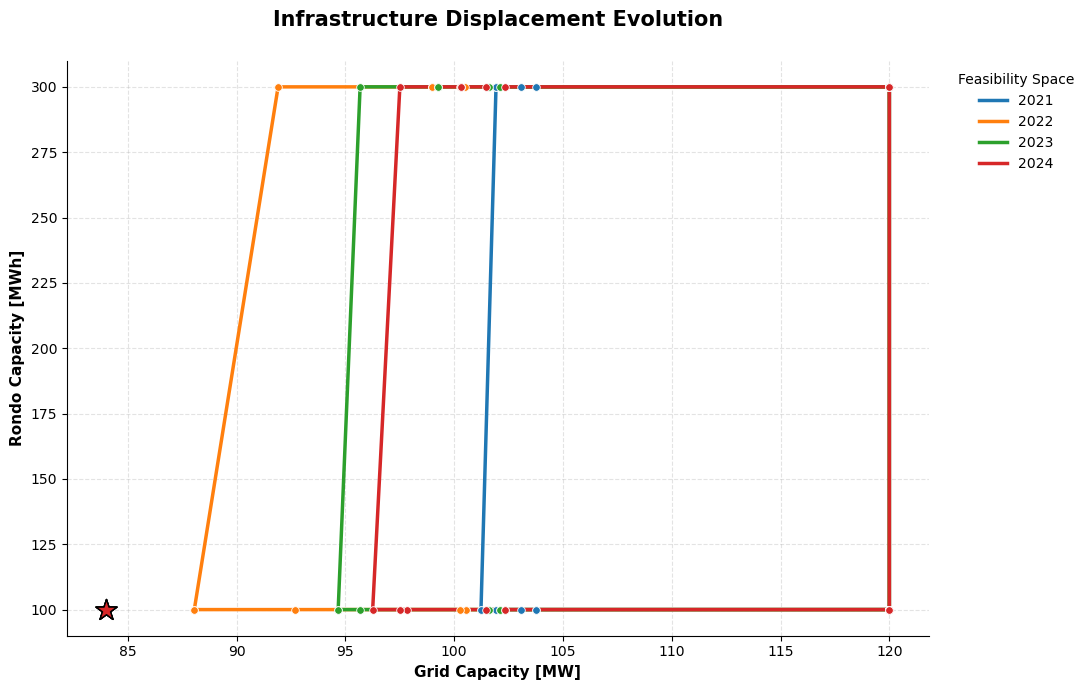

In [226]:

plot_mga_evolution_final([n21_mga_05[1], n22_mga_05[1],n23_mga_05[1],n24_mga_05[1]], 'grid', 'rondo', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Wind Capacity [MW]', ylabel='Rondo Capacity [MWh]'>)

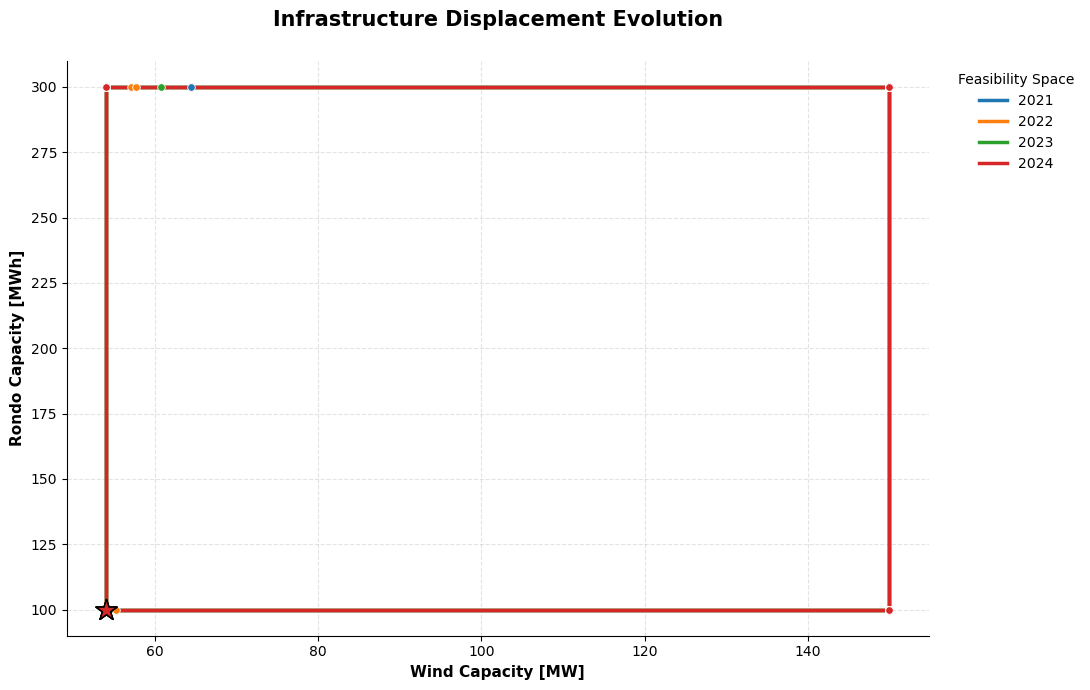

In [227]:

plot_mga_evolution_final([n21_mga_05[1], n22_mga_05[1],n23_mga_05[1],n24_mga_05[1]], 'wind', 'rondo', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Grid Capacity [MW]', ylabel='Rondo Capacity [MWh]'>)

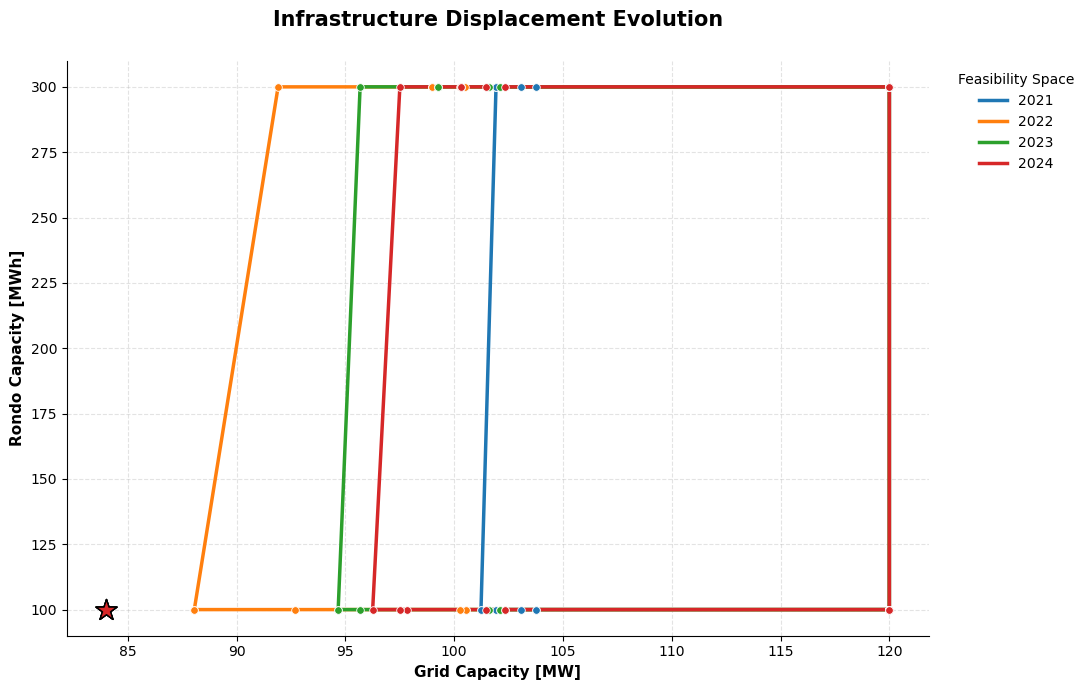

In [335]:
plot_mga_evolution_final([n21_mga_05[1], n22_mga_05[1],n23_mga_05[1],n24_mga_05[1]], 'grid', 'rondo', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Grid Capacity [MW]', ylabel='Battery Capacity [MW]'>)

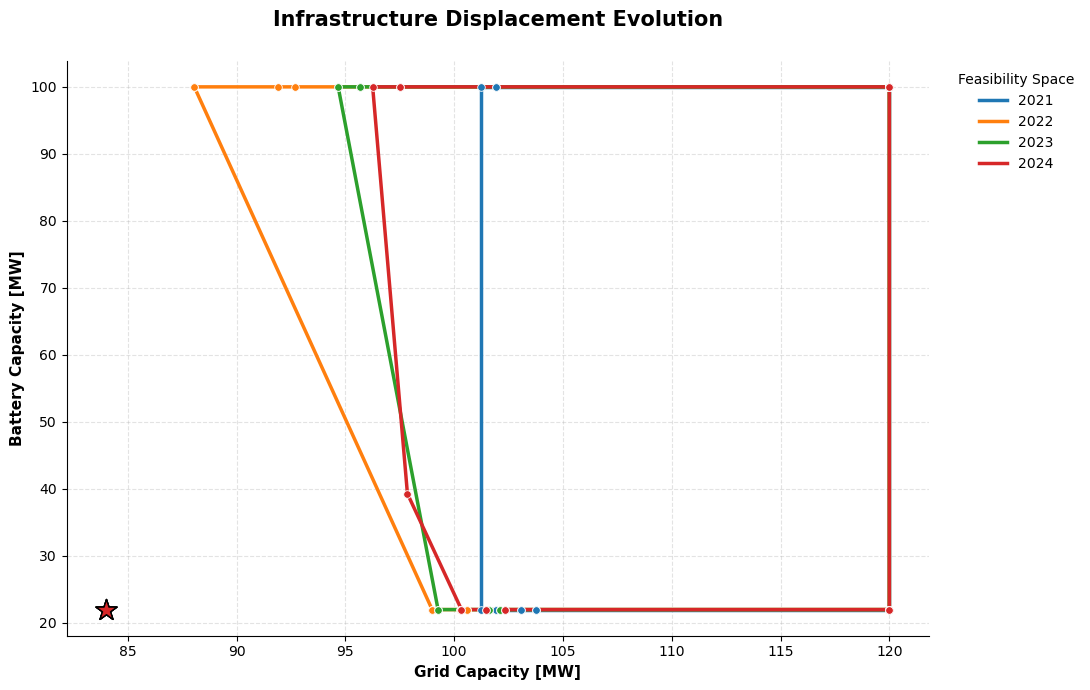

In [338]:
plot_mga_evolution_final([n21_mga_10[1], n22_mga_10[1],n23_mga_10[1],n24_mga_10[1]], 'grid', 'battery', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

In [173]:
n24_mga[1]

,wind,solar,rondo,battery,grid
0,76.045395,30.0,300.0,22.000000,101.690090
1,92.308093,90.0,100.0,86.573920,120.000000
2,150.000000,30.0,300.0,22.000000,100.334455
3,69.335435,30.0,100.0,22.000000,102.451535
4,150.000000,30.0,100.0,100.000000,120.000000
5,66.799300,90.0,300.0,22.000000,101.249710
6,150.000000,30.0,300.0,100.000000,97.502949
7,150.000000,90.0,300.0,100.000000,120.000000
8,119.032127,30.0,300.0,100.000000,120.000000
9,150.000000,90.0,100.0,100.000000,96.252844


In [364]:
n24_mga[0]

,wind,solar,rondo,battery,grid
0,-0.097929,-0.325165,0.848547,-0.374254,-0.156777
1,-0.508412,0.258821,-0.153127,0.314947,0.742893
2,0.236242,-0.604122,0.188711,-0.595259,-0.435065
3,-0.214323,-0.125267,-0.710370,-0.650561,-0.102557
4,0.871843,-0.447189,-0.015514,0.117630,0.160730
5,-0.486774,0.437690,0.476060,-0.250080,-0.531325
6,0.248113,-0.023206,0.874153,0.303341,-0.285907
7,0.133140,0.348525,0.100352,0.910607,0.146729
8,-0.377527,-0.480893,0.629306,0.474280,0.072439
9,0.383315,0.139466,-0.335113,0.146003,-0.836661


In [365]:
n24_mga[1]

,wind,solar,rondo,battery,grid
0,76.045395,30.0,300.0,22.000000,101.690090
1,92.308093,90.0,100.0,86.573920,120.000000
2,150.000000,30.0,300.0,22.000000,100.334455
3,69.335435,30.0,100.0,22.000000,102.451535
4,150.000000,30.0,100.0,100.000000,120.000000
5,66.799300,90.0,300.0,22.000000,101.249710
6,150.000000,30.0,300.0,100.000000,97.502949
7,150.000000,90.0,300.0,100.000000,120.000000
8,119.032127,30.0,300.0,100.000000,120.000000
9,150.000000,90.0,100.0,100.000000,96.252844


In [188]:
[n21_w_datacentre.objective/1e6, n22_w_datacentre.objective/1e6, n23_w_datacentre.objective/1e6, n24_w_datacentre.objective/1e6]

[94.25878945588515, 191.7459251174486, 89.01528287780302, 77.24120124714572]

In [189]:
n21_w_datacentre.statistics.optimal_capacity()

component    carrier            
Generator    Grid Import               120.0
             Natural Gas                 6.0
             Onshore Wind               90.0
             Solar PV                   30.0
Link         Electric Boiler            10.0
             Grid Export               120.0
             Grid Import               120.0
             NG_boiler                   6.0
             Pyrolysis                   2.0
             RONDO_charge               24.0
             RONDO_discharge             7.0
             biochar                     0.9
StorageUnit  battery_storage            22.0
Store        RONDO Storage             100.0
             biochar_sequestered      7878.6
             pellets                105048.0
dtype: float64

In [190]:
n22_w_datacentre.statistics.optimal_capacity()

component    carrier            
Generator    Grid Import               120.00000
             Natural Gas                 6.00000
             Onshore Wind               90.00000
             Solar PV                   30.00000
Link         Electric Boiler            10.00000
             Grid Export               120.00000
             Grid Import               120.00000
             NG_boiler                   6.00000
             Pyrolysis                   2.00000
             RONDO_charge               24.00000
             RONDO_discharge             7.00000
             biochar                     0.90000
StorageUnit  battery_storage            63.10495
Store        Grid Export               177.72533
             RONDO Storage             100.00000
             biochar_sequestered      7884.00000
             pellets                105120.00000
dtype: float64

<Axes: xlabel='snapshot'>

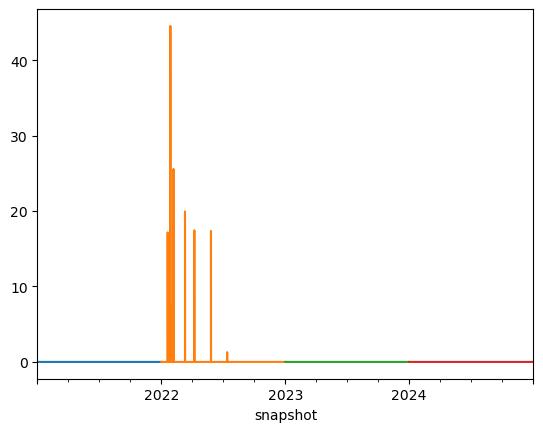

In [200]:
n21_w_datacentre.links_t.p0["Exports"].plot()
n22_w_datacentre.links_t.p0["Exports"].plot()
n23_w_datacentre.links_t.p0["Exports"].plot()
n24_w_datacentre.links_t.p0["Exports"].plot()

In [191]:
n23_w_datacentre.statistics.optimal_capacity()

component    carrier            
Generator    Grid Import               120.0
             Natural Gas                 6.0
             Onshore Wind               90.0
             Solar PV                   30.0
Link         Electric Boiler            10.0
             Grid Export               120.0
             Grid Import               120.0
             NG_boiler                   6.0
             Pyrolysis                   2.0
             RONDO_charge               24.0
             RONDO_discharge             7.0
             biochar                     0.9
StorageUnit  battery_storage            22.0
Store        RONDO Storage             100.0
             biochar_sequestered      7884.0
             pellets                105120.0
dtype: float64

In [195]:
n24_w_datacentre.statistics.optimal_capacity()

component    carrier            
Generator    Grid Import               120.0
             Natural Gas                 6.0
             Onshore Wind               90.0
             Solar PV                   30.0
Link         Electric Boiler            10.0
             Grid Export               120.0
             Grid Import               120.0
             NG_boiler                   6.0
             Pyrolysis                   2.0
             RONDO_charge               24.0
             RONDO_discharge             7.0
             biochar                     0.9
StorageUnit  battery_storage            22.0
Store        RONDO Storage             100.0
             biochar_sequestered      7905.6
             pellets                105408.0
dtype: float64

In [234]:

n21_mga_10 = run_mga_multi_dimensions(n21_w_datacentre, slack=0.1, num_directions=20)
n22_mga_10 = run_mga_multi_dimensions(n22_w_datacentre, slack=0.1, num_directions=20)
n23_mga_10 = run_mga_multi_dimensions(n23_w_datacentre, slack=0.1, num_directions=20)
n24_mga_10 = run_mga_multi_dimensions(n24_w_datacentre, slack=0.1, num_directions=20)

Solving MGA in 20 directions | Slack: 10.0%


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\Pulin\AppData\Local\Temp\tmpvou8a_k1.nc contains: stores, generators, loads, sub_networks, buses, links, storage_units, carriers


Solving MGA in 20 directions | Slack: 10.0%


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\Pulin\AppData\Local\Temp\tmpxbiatprj.nc contains: stores, generators, loads, sub_networks, buses, links, storage_units, carriers


Solving MGA in 20 directions | Slack: 10.0%


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\Pulin\AppData\Local\Temp\tmp0vlfpxgg.nc contains: stores, generators, loads, sub_networks, buses, links, storage_units, carriers


Solving MGA in 20 directions | Slack: 10.0%


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'C:\Users\Pulin\AppData\Local\Temp\tmplxb8pd62.nc contains: stores, generators, loads, sub_networks, buses, links, storage_units, carriers


(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'Infrastructure Displacement Evolution'}, xlabel='Wind Capacity [MW]', ylabel='Grid Capacity [MW]'>)

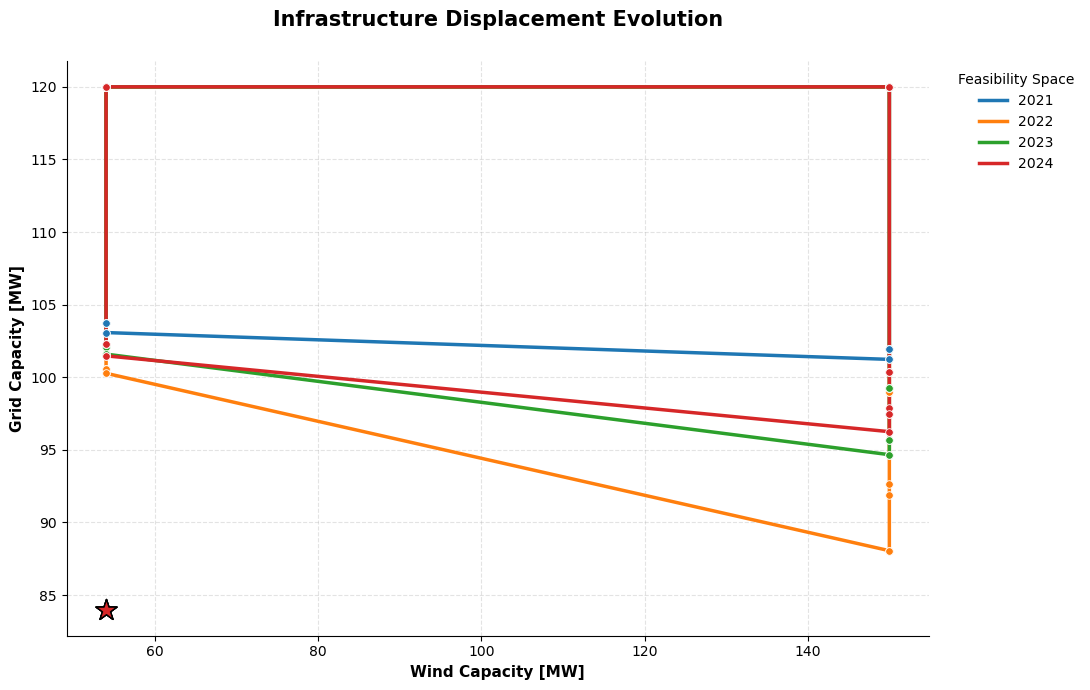

In [267]:
plot_mga_evolution_final([n21_mga_10[1], n22_mga_10[1],n23_mga_10[1],n24_mga_10[1]], 'wind', 'grid', ['2021',"2022","2023",'2024'], title="Infrastructure Displacement Evolution")

(<Figure size 1100x700 with 1 Axes>,
 <Axes: title={'center': 'MGA evolution 2024'}, xlabel='Grid Capacity [MW]', ylabel='Battery Capacity [MW]'>)

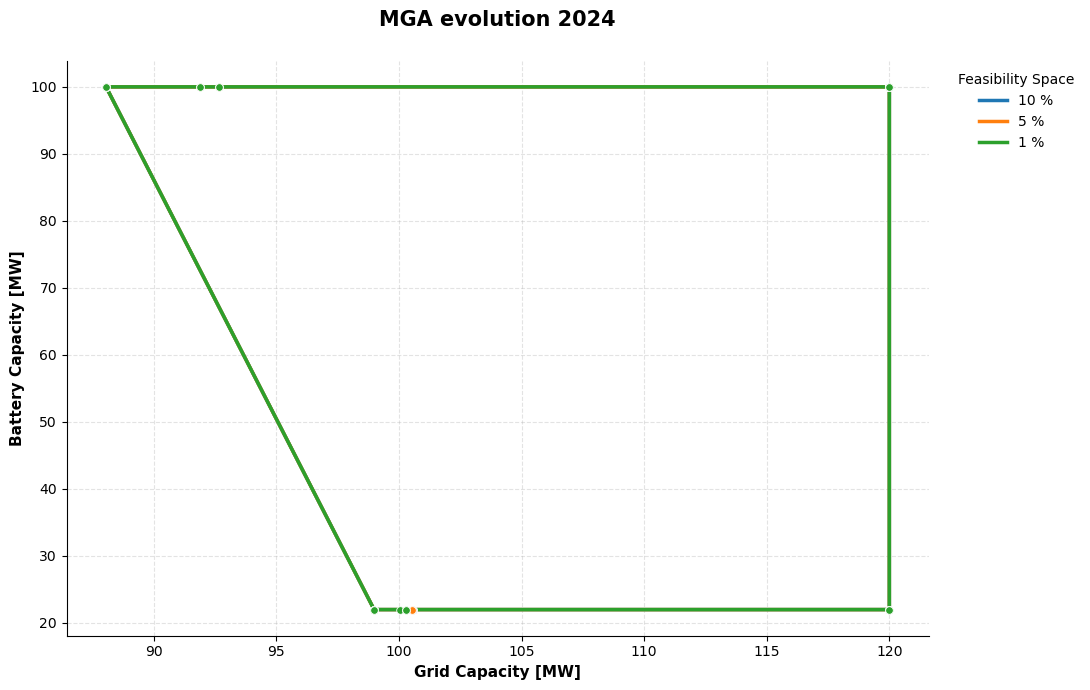

In [334]:
plot_mga_evolution_final([n22_mga_10[1], n22_mga_05[1],n22_mga[1]], 'grid', 'battery', ["10 %", "5 %", "1 %"], title="MGA evolution 2024")

In [390]:
n23_mga[1]

,wind,solar,rondo,battery,grid
0,79.046027,30.0,300.0,22.0,101.352101
1,85.993082,90.0,100.0,100.0,120.000000
2,150.000000,30.0,300.0,22.0,99.258636
3,74.835322,30.0,100.0,22.0,101.518147
4,150.000000,30.0,100.0,100.0,120.000000
5,57.328614,90.0,300.0,22.0,101.491105
6,150.000000,30.0,300.0,100.0,95.676013
7,150.000000,90.0,300.0,100.0,120.000000
8,113.546003,30.0,300.0,100.0,120.000000
9,150.000000,90.0,100.0,100.0,94.667526


In [874]:
n21_mga[1]

,wind,solar,rondo,battery,grid
0,77.660801,30.0,300.0,22.000000,103.314397
1,81.098791,90.0,100.0,86.513539,120.000000
2,150.000000,30.0,300.0,22.000000,101.922030
3,73.181236,30.0,100.0,22.000000,103.400619
4,150.000000,30.0,100.0,100.000000,120.000000
5,54.000000,90.0,300.0,22.000000,103.078922
6,150.000000,30.0,300.0,100.000000,101.922030
7,150.000000,90.0,300.0,100.000000,120.000000
8,122.899145,30.0,300.0,100.000000,120.000000
9,150.000000,90.0,100.0,100.000000,101.231138


In [315]:
n24_w_datacentre.objective/1e6, n23_w_datacentre.objective/1e6, n22_w_datacentre.objective/1e6, n21_w_datacentre.objective/1e6

(77.24120124714572, 89.01528287780302, 191.7459251174486, 94.25878945588515)

In [316]:
n24_w_datacentre.statistics.opex()

component  carrier    
Generator  Natural Gas    1.492720e+06
Link       Grid Import    7.068777e+07
           biochar       -1.979562e+05
dtype: float64

In [317]:
n22_w_datacentre.statistics.opex()

component  carrier    
Generator  Natural Gas    4.412150e+06
Link       Grid Export   -1.922248e+04
           Grid Import    1.783313e+08
           biochar       -1.974154e+05
dtype: float64

In [318]:
n23_w_datacentre.statistics.opex()

component  carrier    
Generator  Natural Gas    1.821116e+06
Link       Grid Import    8.213291e+07
           biochar       -1.974154e+05
dtype: float64

In [319]:
n21_w_datacentre.statistics.opex()

component  carrier    
Generator  Natural Gas    2.182246e+06
Link       Grid Import    8.701515e+07
           biochar       -1.972801e+05
dtype: float64

In [367]:
dimensions = {
        "wind": {"Generator": {"p_nom": {"Skive_Onshore_Wind": 1}}},
        "solar": {"Generator": {"p_nom": {"Skive_Solar": 1}}},
        "rondo": {"Store": {"e_nom": {"Rondo_Concrete_Heat_Storage": 1}}},
        "battery": {"StorageUnit": {"p_nom": {"Skive_Battery": 1}}},
        "grid": {"Link": {"p_nom": {"Imports": 1}}},
        #"NG boiler": {"links": {"p_nom": {"NG boiler": 0}}},
        #"RONDO discharger": {"links": {"p_nom": {"TES_Rondo_to_Heat_Bus_Skive": 0}}},
        #"El boiler": {"links": {"p_nom": {"Boiler_Skive": 0}}},
    }

In [380]:
pypsa.optimization.mga.generate_directions_halton(dimensions.keys(),n_directions = 20, seed=0)

,wind,solar,rondo,battery,grid
0,-0.097929,-0.325165,0.848547,-0.374254,-0.156777
1,-0.508412,0.258821,-0.153127,0.314947,0.742893
2,0.236242,-0.604122,0.188711,-0.595259,-0.435065
3,-0.214323,-0.125267,-0.710370,-0.650561,-0.102557
4,0.871843,-0.447189,-0.015514,0.117630,0.160730
5,-0.486774,0.437690,0.476060,-0.250080,-0.531325
6,0.248113,-0.023206,0.874153,0.303341,-0.285907
7,0.133140,0.348525,0.100352,0.910607,0.146729
8,-0.377527,-0.480893,0.629306,0.474280,0.072439
9,0.383315,0.139466,-0.335113,0.146003,-0.836661


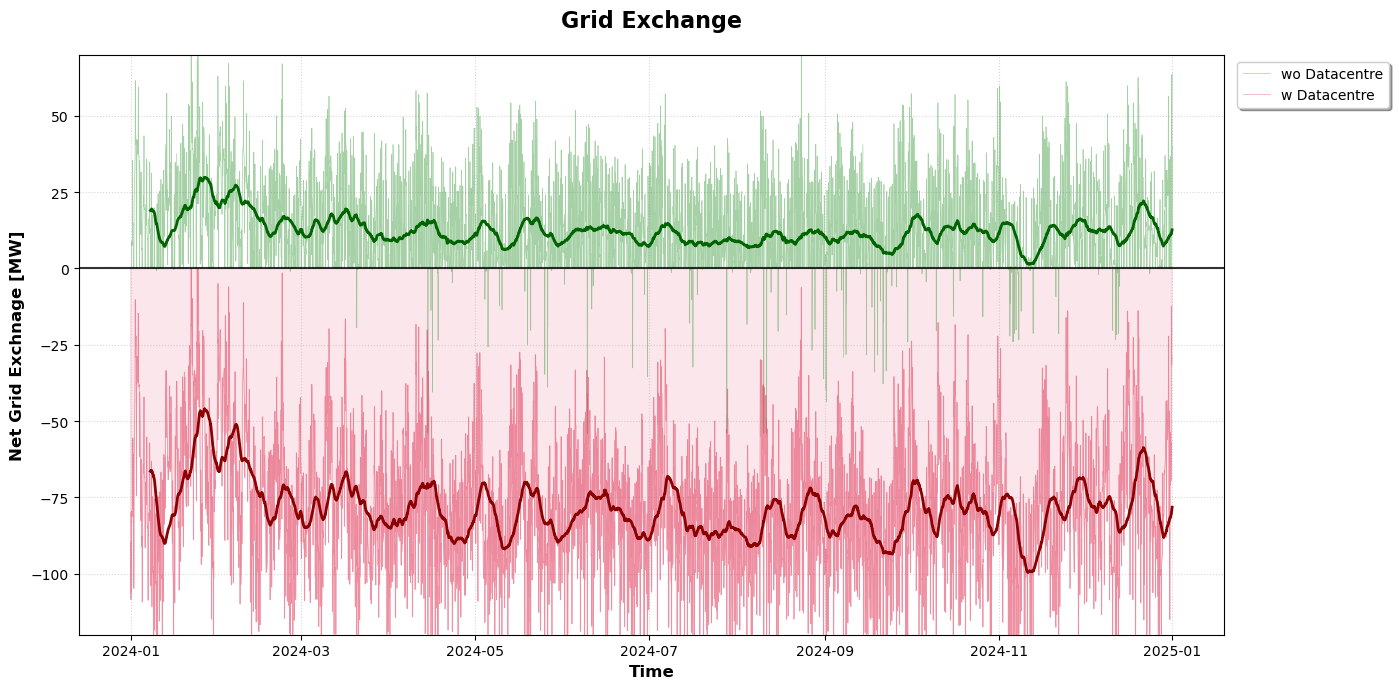

In [727]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_net_grid_comparison(n_with, n_without, title="Net Grid Balance: With vs. Without Data Centre (2024)"):
    """
    Plots the Net Grid Balance (Exports - Imports) for two scenarios.
    Positive = Net Export (Surplus)
    Negative = Net Import (Deficit)
    """
    # 1. Calculate Net Balance
    # Using p0 (input/output at the first bus)
    net_with = n_with.links_t.p0["Exports"] - n_with.links_t.p0["Imports"]
    net_wo = n_without.links_t.p0["Exports"] - n_without.links_t.p0["Imports"]

    # 2. Setup the figure
    fig, ax = plt.subplots(figsize=(14, 7))

    # 3. Plotting the raw data with transparency to handle 8760 points
    ax.plot(net_wo.index, net_wo, color='forestgreen', alpha=0.4, label='wo Datacentre', linewidth=0.5)
    ax.plot(net_with.index, net_with, color='crimson', alpha=0.4, label='w Datacentre', linewidth=0.5)

    # 4. Add a Rolling Average (7-day window) to see the trend through the noise
    # This helps a lot with 8760-hour plots
    ax.plot(net_wo.rolling(window=24*7).mean(), color='darkgreen' , linewidth=2)
    ax.plot(net_with.rolling(window=24*7).mean(), color='darkred', linewidth=2)

    # 5. Infrastructure Reference Lines
    ax.axhline(0, color='black', linewidth=1.5, linestyle='-', alpha=0.8) # Zero line
    #ax.axhline(-120, color='gray', linestyle='--', alpha=0.6, label='Grid Connection (120 MW)')
    #ax.axhline(120, color='gray', linestyle='--', alpha=0.6)

    ax.set_ylim(-120,70)
    # 6. Formatting
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_ylabel('Net Grid Exchnage [MW]', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time', fontsize=12, fontweight='bold')
    
    # Shade the "Net Import" area for the 'With DC' scenario to emphasize energy dependency
    ax.fill_between(net_with.index, net_with, 0, where=(net_with < 0), color='crimson', alpha=0.1)

    ax.grid(True, which='both', linestyle=':', alpha=0.5)
    ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1), frameon=True, shadow=True)

    plt.tight_layout()
    return fig

# Execute
fig = plot_net_grid_comparison(n24_w_datacentre, n24_wo_datacentre, title = "Grid Exchange")
#plt.savefig("Net_Grid_Comparison_2024.png", dpi=300)
plt.show()

In [689]:
n24_w_datacentre.statistics.optimal_capacity()

component    carrier            
Generator    Grid Import               120.0
             Natural Gas                 6.0
             Onshore Wind               90.0
             Solar PV                   30.0
Link         Electric Boiler            10.0
             Grid Export               120.0
             Grid Import               120.0
             NG_boiler                   6.0
             Pyrolysis                   2.0
             RONDO_charge               24.0
             RONDO_discharge             7.0
             biochar                     0.9
StorageUnit  battery_storage            22.0
Store        RONDO Storage             100.0
             biochar_sequestered      7905.6
             pellets                105408.0
dtype: float64

# Pypsa HeatMap

In [640]:
def plot_pypsa_heatmap(data, title="PyPSA Heatmap", unit="Value", cmap="viridis", ax=None, vmin=None, vmax=None):
    """
    Added vmin and vmax for manual scale control.
    """
    if isinstance(data, pd.DataFrame):
        plot_data = data.mean(axis=1)
    else:
        plot_data = data

    df = plot_data.to_frame(name="values")
    df["date"] = df.index.date
    df["hour"] = df.index.hour
    
    pivot = df.pivot_table(index="date", columns="hour", values="values", aggfunc='mean')

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    # Pass vmin and vmax here
    sns.heatmap(pivot, cmap=cmap, cbar_kws={'label': unit}, ax=ax, 
                rasterized=True, vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Date")

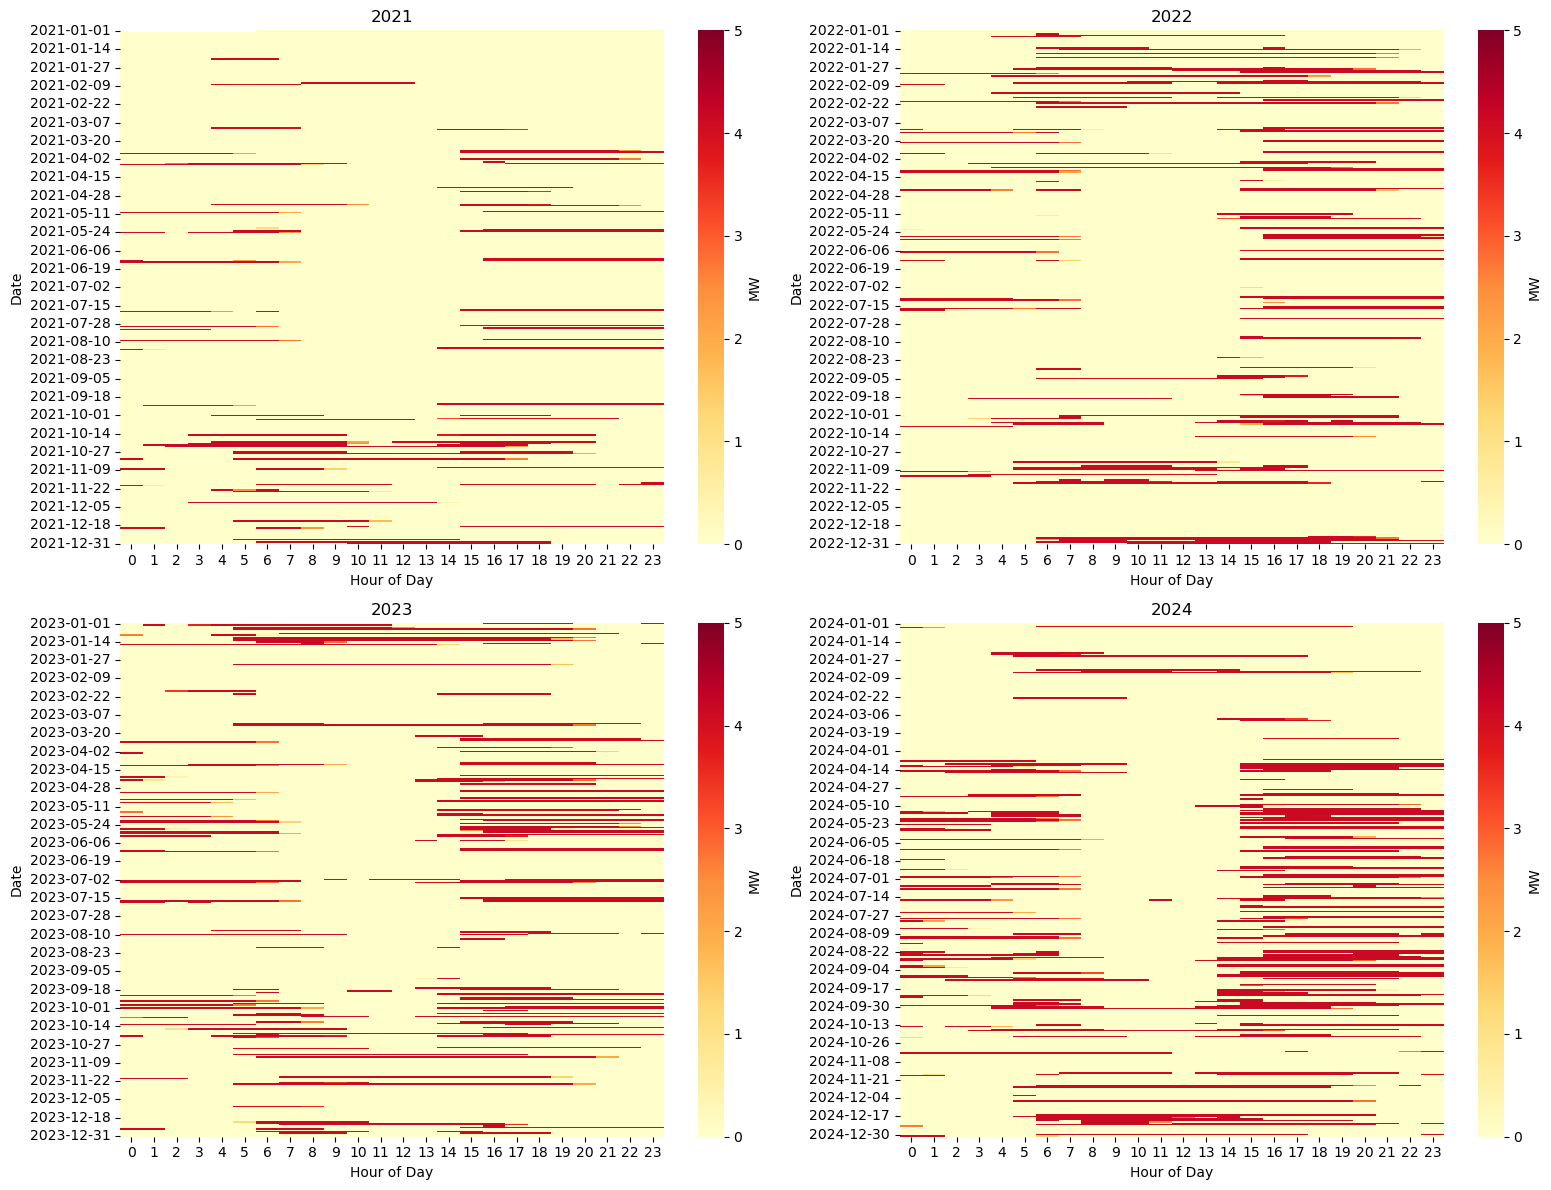

In [693]:
# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
# Plot each network on its respective axis
plot_pypsa_heatmap(-n21_w_datacentre.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="2021", unit="MW", 
                   cmap="YlOrRd", ax=axes[0], vmin=0, vmax=5)
plot_pypsa_heatmap(-n22_w_datacentre.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="2022", unit="MW", 
                   cmap="YlOrRd", ax=axes[1], vmin=0, vmax=5)
plot_pypsa_heatmap(-n23_w_datacentre.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="2023", unit="MW", 
                   cmap="YlOrRd", ax=axes[2], vmin=0, vmax=5)
plot_pypsa_heatmap(-n24_w_datacentre.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="2024", unit="MW", 
                   cmap="YlOrRd", ax=axes[3], vmin=0, vmax=5)
# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout()
plt.show()

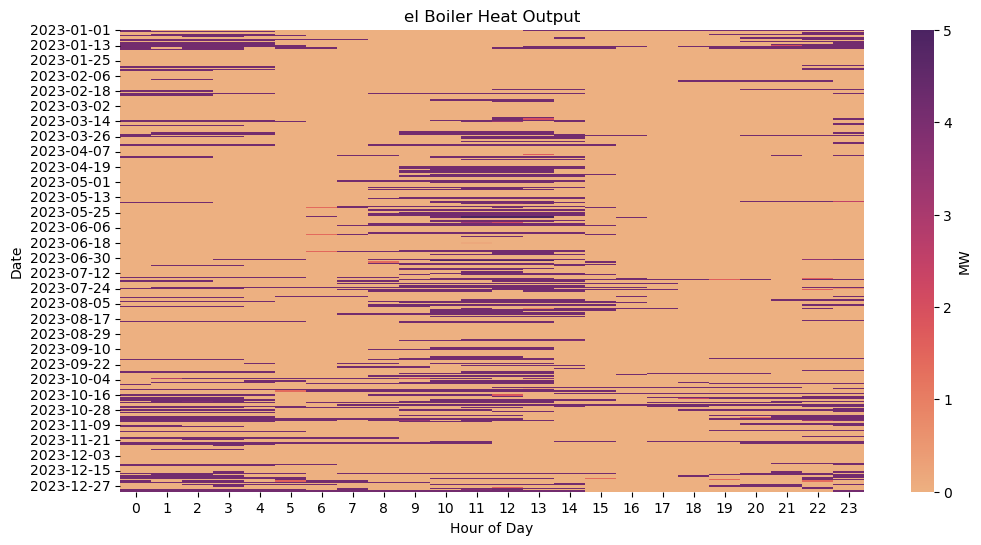

In [653]:
plot_pypsa_heatmap(
-n23_wo_datacentre.links_t.p1["Boiler_Skive"], title="el Boiler Heat Output", unit="MW", cmap="flare", ax=None)

In [654]:

def plot_hourly_average_links(n, title="Average Hourly Link Dispatch (2024)"):
    # 1. Select the relevant links (adjust these names based on n.links.index)
    # We use p0 (input) to see how much power they are taking
    links_to_plot = ["NG boiler", "pyrolysis", "TES_Rondo_to_Heat_Bus_Skive", "Boiler_Skive"]
    
    # Filter only links that exist in the network
    existing_links = [l for l in links_to_plot if l in n.links_t.p1.columns]
    df = -n.links_t.p1[existing_links]
    
    # 2. Group by hour of the day (0-23) and calculate mean
    hourly_avg = df.groupby(df.index.hour).mean()
    
    # 3. Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    hourly_avg.plot(ax=ax, marker='o', markersize=4, linewidth=2)
    
    # 4. Formatting
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Hour of Day [CET]", fontweight='bold')
    ax.set_ylabel("Average Power [MW]", fontweight='bold')
    ax.set_xticks(range(0, 24))
    ax.set_xlim(0,23)
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    return fig, hourly_avg


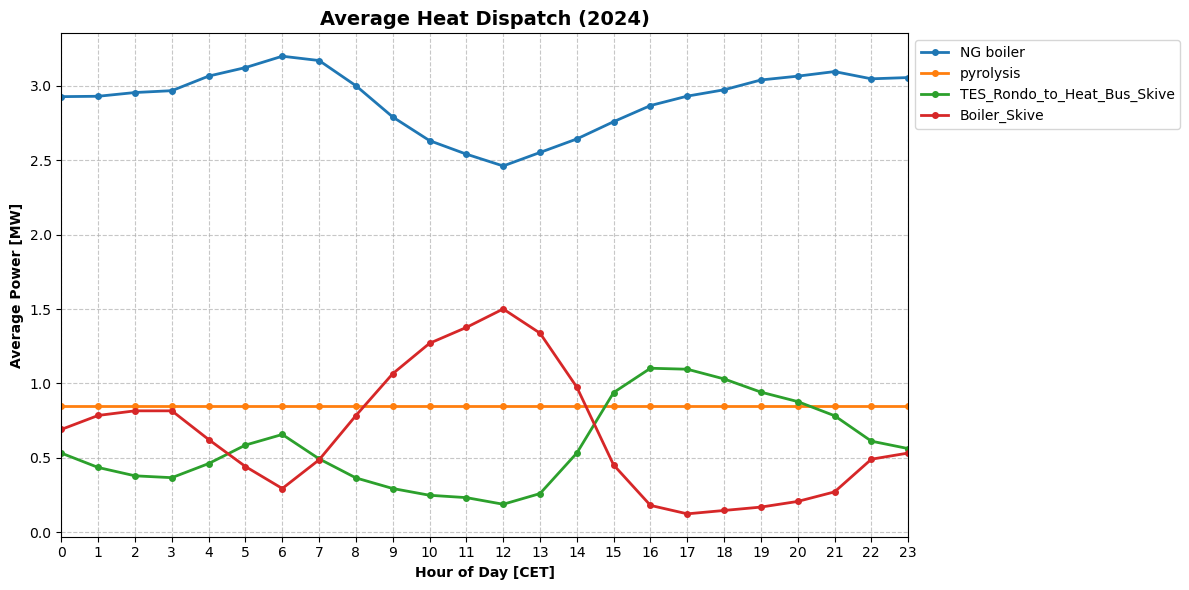

In [690]:

# Execute:
fig, avg_data = plot_hourly_average_links(n24_w_datacentre, title="Average Heat Dispatch (2024)")

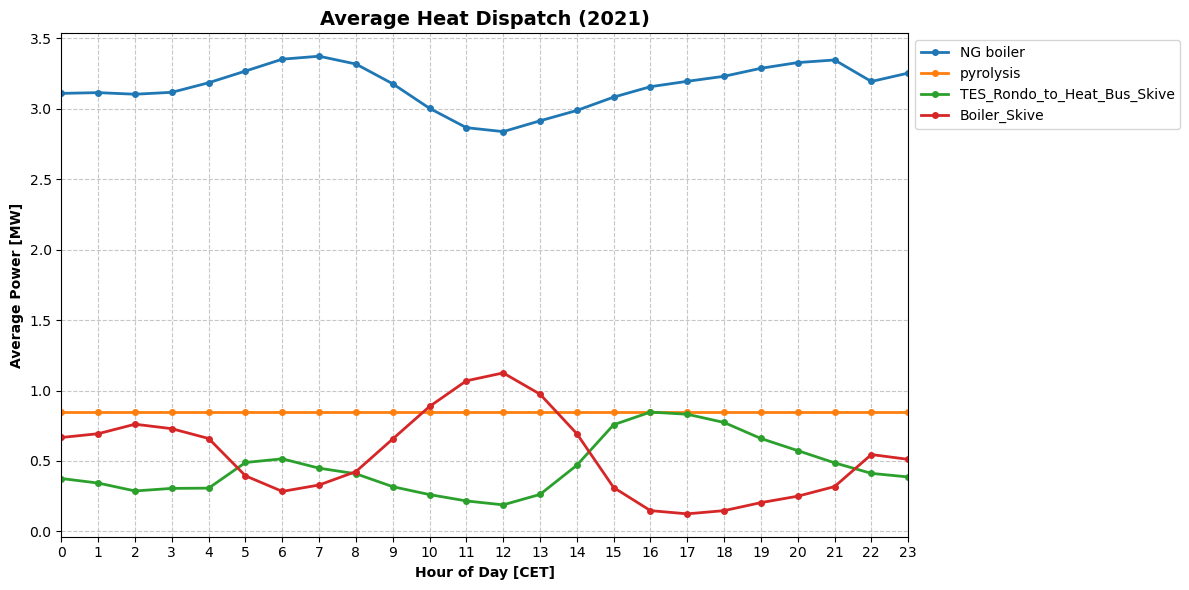

In [670]:

fig, avg_data = plot_hourly_average_links(n23_w_datacentre, title="Average Heat Dispatch (2021)")

In [673]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_hourly_heat_comparison(networks_dict, title="Hourly Average Heat Dispatch Comparison"):
    """
    Compares hourly heat dispatch across multiple PyPSA networks.
    networks_dict: {'2021': n21, '2024': n24, ...}
    """
    # Mapping of technical names to clean labels for the legend/titles
    target_links = {
        "Boiler_Skive": "Electric Boiler",
        "TES_Rondo_to_Heat_Bus_Skive": "RONDO TES",
        "NG boiler": "Natural Gas Boiler",
        "pyrolysis": "Pyrolysis"
    }
    
    # Standard colors for consistent scenario tracking
    colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c', '2024': '#d62728'}
    
    # 1. Collect and process data from each network
    plot_data = []
    for scenario_name, n in networks_dict.items():
        # Identify which target links actually exist in this specific network
        existing = [l for l in target_links.keys() if l in n.links.index]
        
        if not existing:
            print(f"Warning: No heat links found for scenario {scenario_name}")
            continue
            
        # Get output power (p1), flip sign to positive for production, group by hour
        df_hourly = (-n.links_t.p1[existing]).groupby(n.links_t.p1.index.hour).mean()
        
        # Rename columns to nice labels
        df_hourly = df_hourly.rename(columns=target_links)
        
        # Explicitly name the index to avoid KeyError during melt
        df_hourly.index.name = 'Hour' 
        
        # Reset index and melt into a long-format dataframe
        df_reset = df_hourly.reset_index()
        df_melted = df_reset.melt(id_vars='Hour', var_name='Technology', value_name='MW')
        
        # Tag with the scenario name and add to our master list
        df_melted['Scenario'] = scenario_name
        plot_data.append(df_melted)
    
    # Combine all scenarios into one dataframe
    full_df = pd.concat(plot_data)
    
    # 2. Setup Subplots (One subplot per technology found across all networks)
    techs = full_df['Technology'].unique()
    fig, axes = plt.subplots(len(techs), 1, figsize=(11, 3.5 * len(techs)), sharex=True)
    
    # Ensure axes is iterable even if there is only one technology
    if len(techs) == 1:
        axes = [axes]

    # 3. Plot each technology in its own subplot
    for i, tech in enumerate(techs):
        ax = axes[i]
        tech_df = full_df[full_df['Technology'] == tech]
        
        # Plot each scenario as a separate line in the tech subplot
        for scenario in networks_dict.keys():
            data = tech_df[tech_df['Scenario'] == scenario]
            if not data.empty:
                ax.plot(data['Hour'], data['MW'], label=scenario, 
                        color=colors.get(scenario, None), linewidth=2.5, 
                        marker='o', markersize=4, alpha=0.8)
        
        # Aesthetic formatting
        ax.set_ylabel("Avg. Production [MW]", fontweight='bold', fontsize=10)
        ax.set_title(f"Technology: {tech}", loc='left', fontweight='bold', fontsize=13, color='#333333')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_xticks(range(0, 24))
        ax.set_xlim(0, 23)
        
        # Put legend on the first subplot
        if i == 0:
            ax.legend(loc='upper right', title="Scenarios", frameon=True, shadow=True)

    # 4. Final Figure Formatting
    axes[-1].set_xlabel("Hour of Day [0-23]", fontweight='bold', fontsize=11)
    plt.suptitle(title, fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    return fig


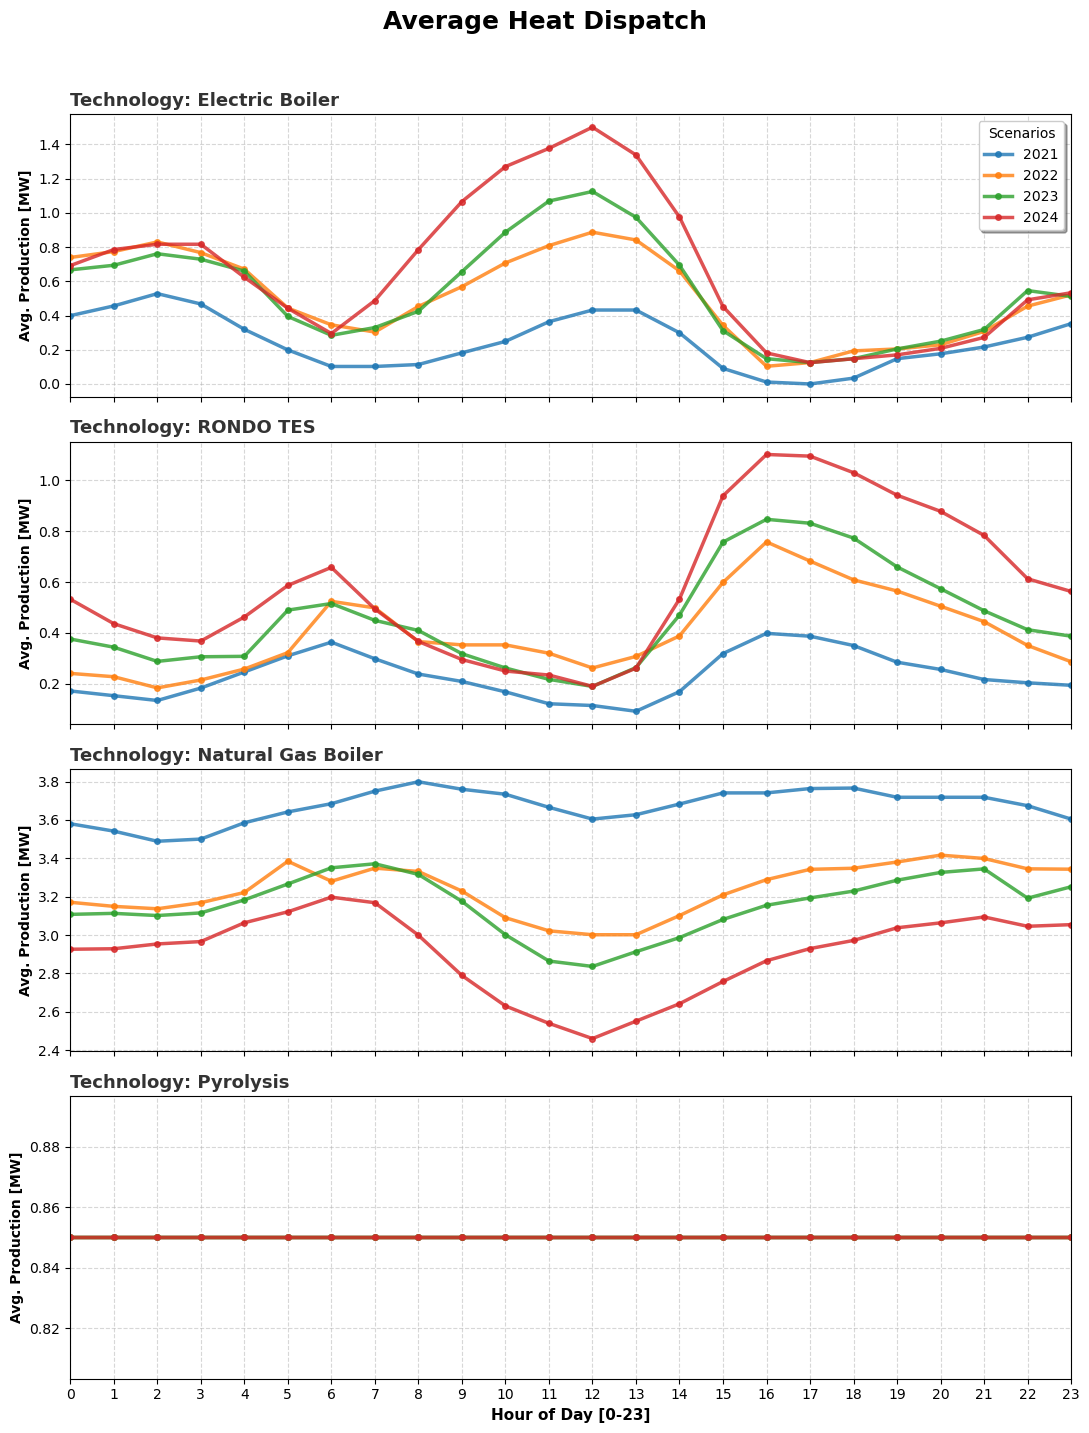

In [676]:

# --- EXECUTION ---
# Ensure your variables match your actual network object names
scenarios_to_compare = {
    "2021": n21_w_datacentre, 
    "2022": n22_w_datacentre, 
    "2023": n23_w_datacentre,
    "2024": n24_w_datacentre, 
}

fig = plot_hourly_heat_comparison(scenarios_to_compare, title="Average Heat Dispatch")
plt.show()

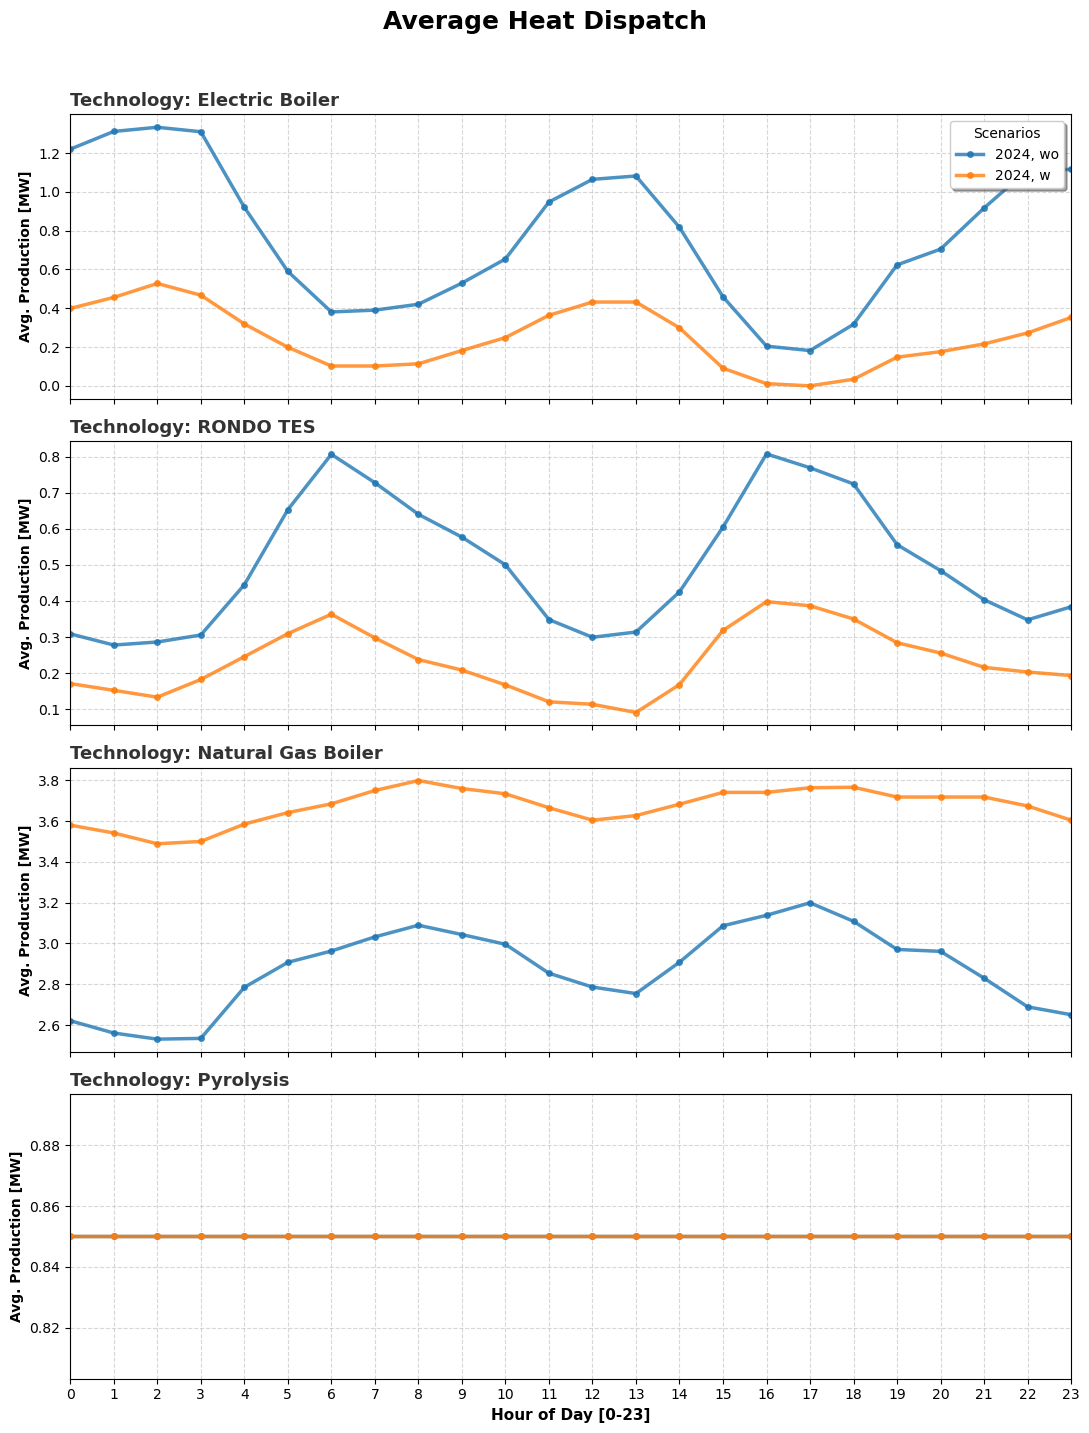

In [680]:
scenarios_to_compare = {
    "2024, wo": n21_wo_datacentre, 
    "2024, w": n21_w_datacentre, 
}

fig = plot_hourly_heat_comparison(scenarios_to_compare, title="Average Heat Dispatch")
plt.show()

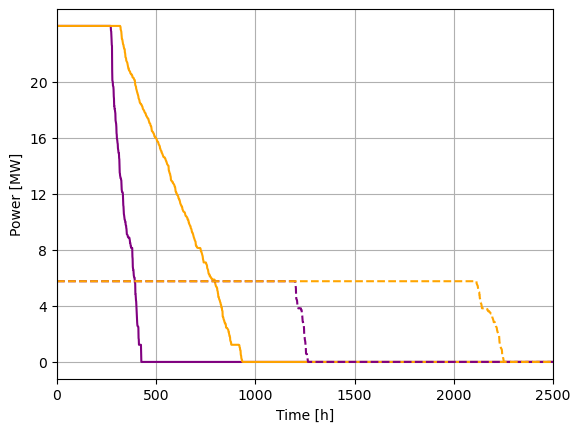

In [728]:
n24_w_datacentre.links_t.p0["El_to_TES_Rondo"].sort_values(ascending=False).reset_index(drop=True).plot(label = "w Datacentre", color = "purple")
n24_wo_datacentre.links_t.p0["El_to_TES_Rondo"].sort_values(ascending=False).reset_index(drop=True).plot(label = "w.o Datacentre", color = "orange")
n24_w_datacentre.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"].sort_values(ascending=False).reset_index(drop=True).plot(label = "w Datacentre", color = "purple", linestyle = "--")
n24_wo_datacentre.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"].sort_values(ascending=False).reset_index(drop=True).plot(label = "w.o Datacentre", color = "orange", linestyle = "--")
plt.xlim(0,2500)
plt.yticks(np.arange(0, 24, 4))
plt.xlabel("Time [h]")
plt.ylabel("Power [MW]")
plt.grid()

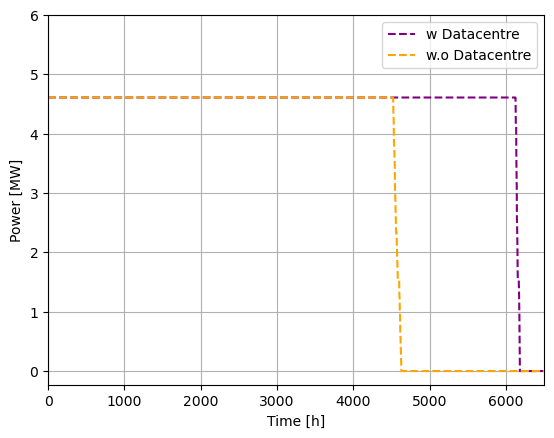

In [729]:
n24_w_datacentre.links_t.p0["NG boiler"].sort_values(ascending=False).reset_index(drop=True).plot(label = "w Datacentre", color = "purple", linestyle = "--")
n24_wo_datacentre.links_t.p0["NG boiler"].sort_values(ascending=False).reset_index(drop=True).plot(label = "w.o Datacentre", color = "orange", linestyle = "--")
plt.xlim(0,6500)
plt.yticks(np.arange(0, 7, 1))
plt.xlabel("Time [h]")
plt.ylabel("Power [MW]")
plt.grid()
plt.legend()

In [823]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_single_storage_kde(networks_dict, storage_type="battery"):
    """
    storage_type: "battery" or "rondo"
    """
    colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c', '2024': '#d62728'}
    plt.figure(figsize=(10, 6))
    
    for scenario, n in networks_dict.items():
        color = colors.get(scenario, None)
        
        if storage_type == "battery":
            if "Skive_Battery" in n.storage_units_t.state_of_charge.columns:
                data = n.storage_units_t.state_of_charge["Skive_Battery"].dropna()
                label, title, x_max = "Battery SoC", "Skive Battery: Comparative Utilization Distribution", 22*2
            else: continue
        else:
            if "Rondo_Concrete_Heat_Storage" in n.stores_t.e.columns:
                data = n.stores_t.e["Rondo_Concrete_Heat_Storage"].dropna()
                label, title, x_max = "RONDO Energy", "RONDO Thermal Storage: Comparative Utilization Distribution", 100
            else: continue
        
        sns.kdeplot(data, label=scenario, color=color, linewidth=2.5, fill=True, alpha=0.08, clip=(0, None))

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Energy Stored [MWh]", fontweight='bold')
    plt.ylabel("Probability Density", fontweight='bold')
    plt.xlim(0, x_max)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(title="Scenarios")
    plt.tight_layout()
    return plt.gcf()


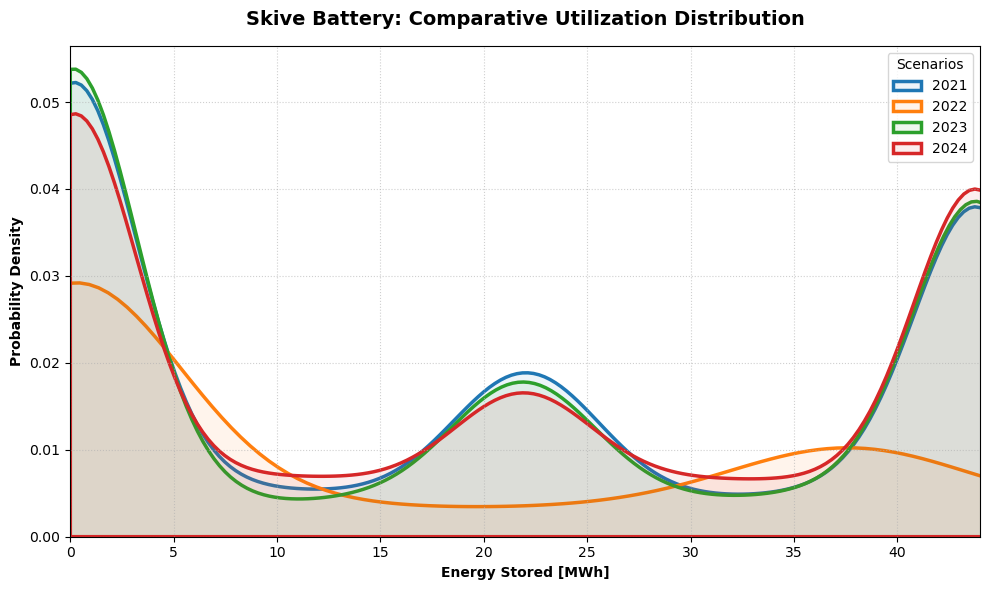

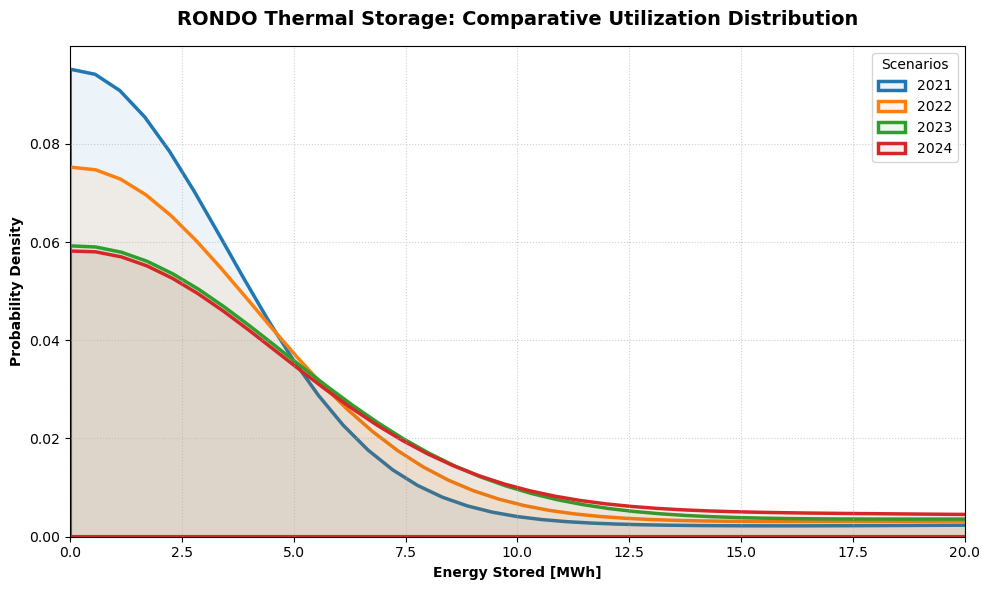

In [802]:

# --- Execution ---
scenarios = {"2021": n21_wo_datacentre,"2022": n22_wo_datacentre,"2023": n23_wo_datacentre ,"2024": n24_wo_datacentre}

# Plot Battery individually
fig1 = plot_single_storage_kde(scenarios, storage_type="battery")
plt.show()

# Plot RONDO individually
fig2 = plot_single_storage_kde(scenarios, storage_type="rondo")
plt.show()


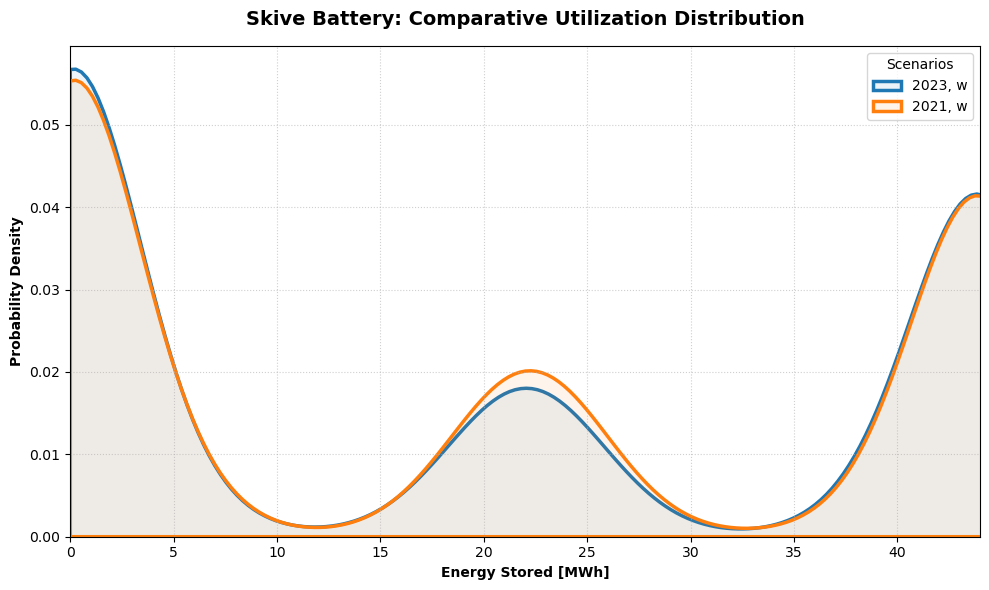

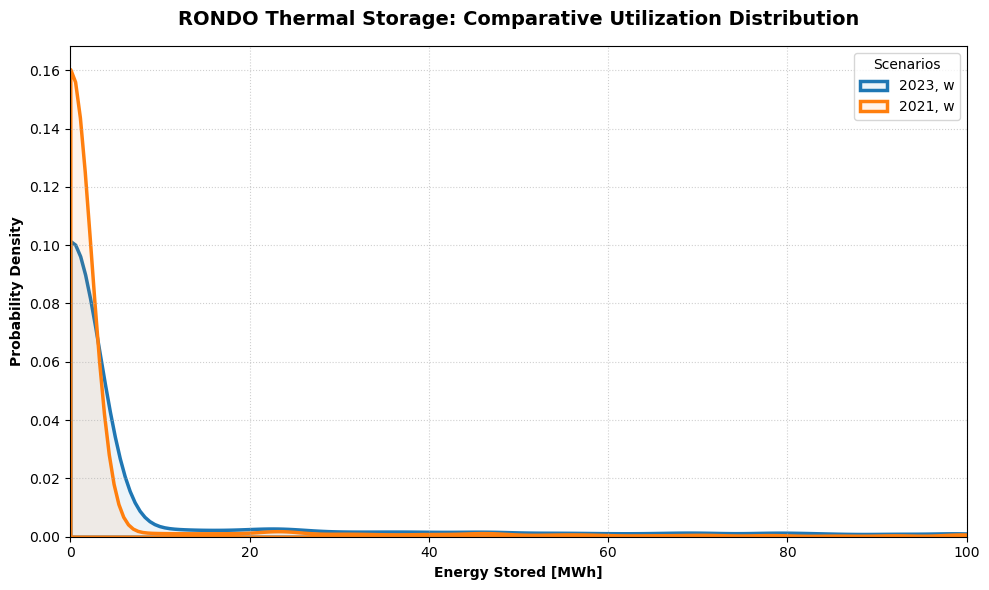

In [877]:

# --- Execution ---
scenarios = {"2023, w": n23_w_datacentre,"2021, w": n21_w_datacentre}

# Plot Battery individually
fig1 = plot_single_storage_kde(scenarios, storage_type="battery")
plt.show()

# Plot RONDO individually
fig2 = plot_single_storage_kde(scenarios, storage_type="rondo")
plt.show()

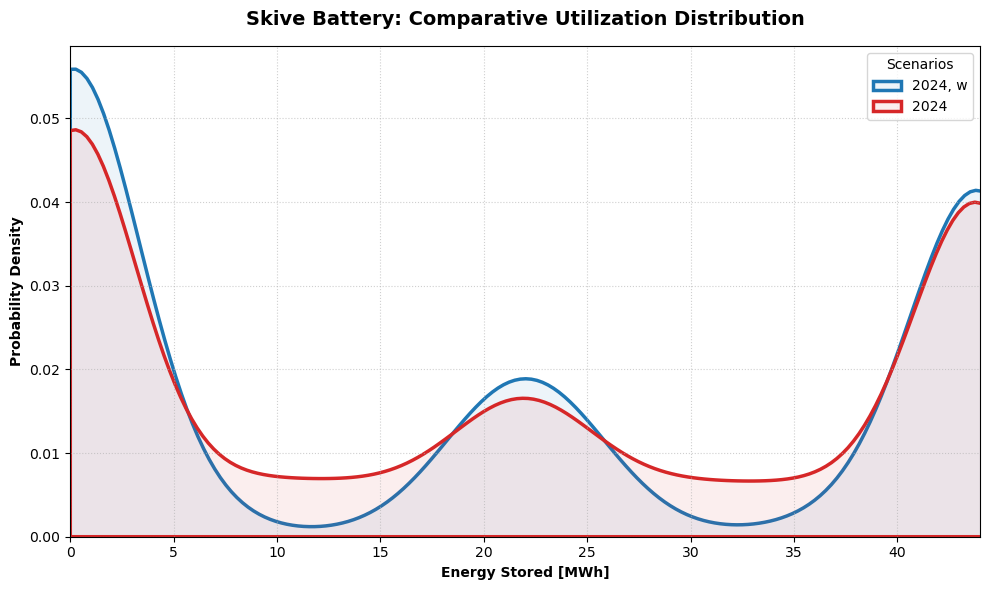

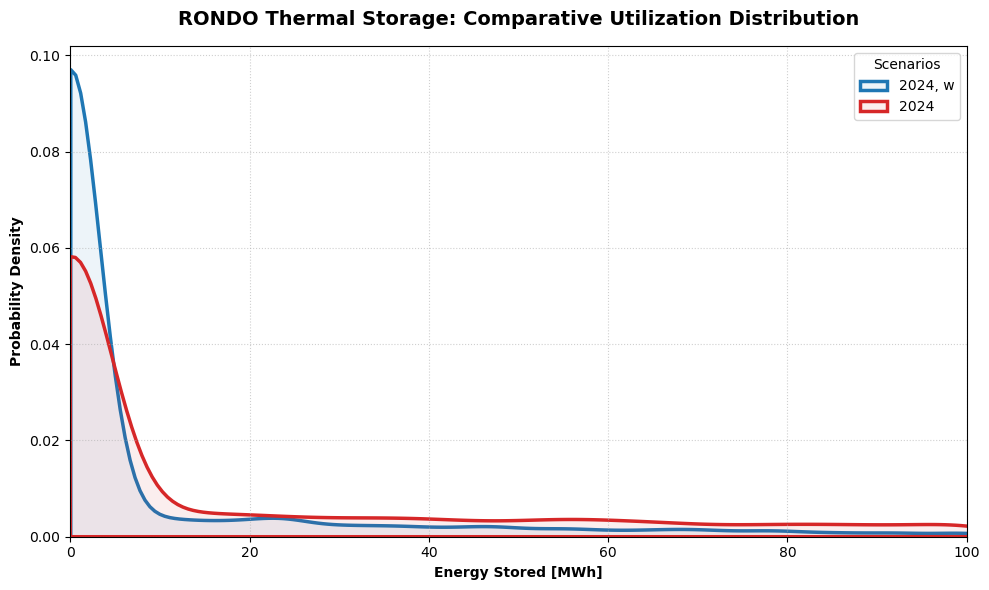

In [824]:

# --- Execution ---
scenarios = {"2024, w": n24_w_datacentre,"2024": n24_wo_datacentre}

# Plot Battery individually
fig1 = plot_single_storage_kde(scenarios, storage_type="battery")
plt.show()

# Plot RONDO individually
fig2 = plot_single_storage_kde(scenarios, storage_type="rondo")
plt.show()

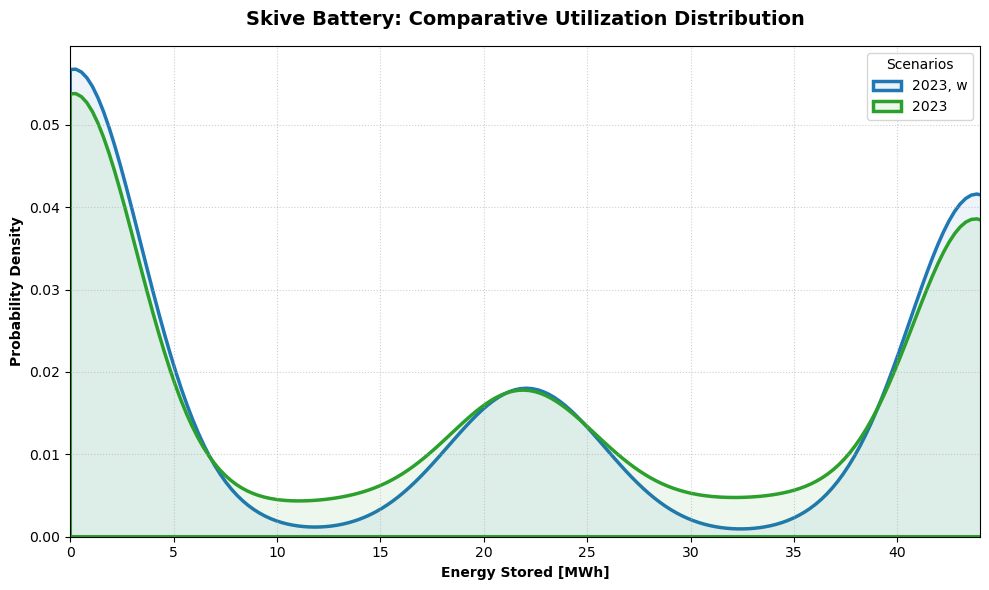

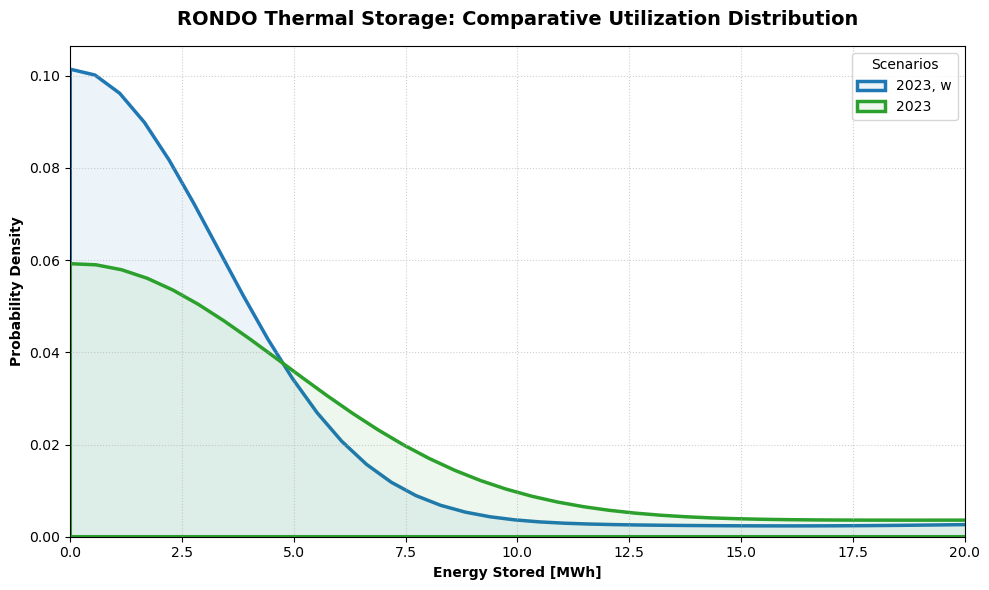

In [814]:
scenarios = {"2023, w": n23_w_datacentre,"2023": n23_wo_datacentre}

# Plot Battery individually
fig1 = plot_single_storage_kde(scenarios, storage_type="battery")
plt.show()

# Plot RONDO individually
fig2 = plot_single_storage_kde(scenarios, storage_type="rondo")
plt.show()

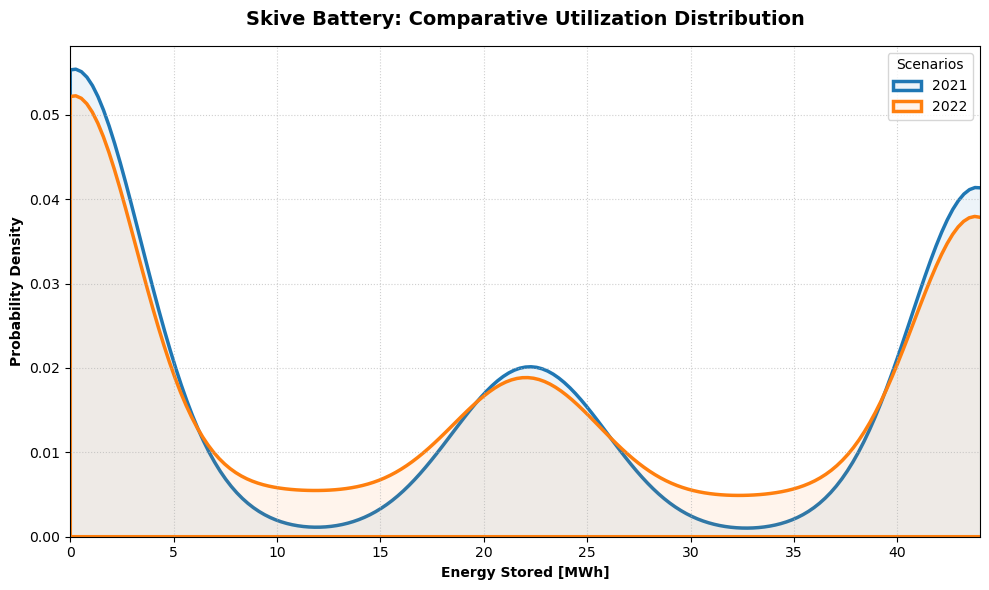

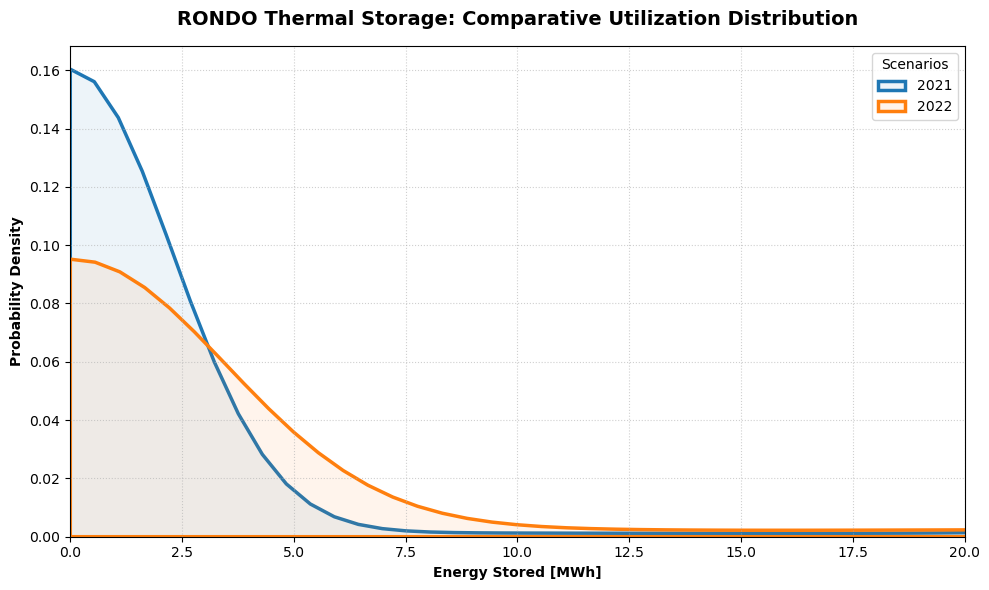

In [822]:
scenarios = {"2021": n21_w_datacentre,"2022": n21_wo_datacentre}

# Plot Battery individually
fig1 = plot_single_storage_kde(scenarios, storage_type="battery")
plt.show()

# Plot RONDO individually
fig2 = plot_single_storage_kde(scenarios, storage_type="rondo")
plt.show()

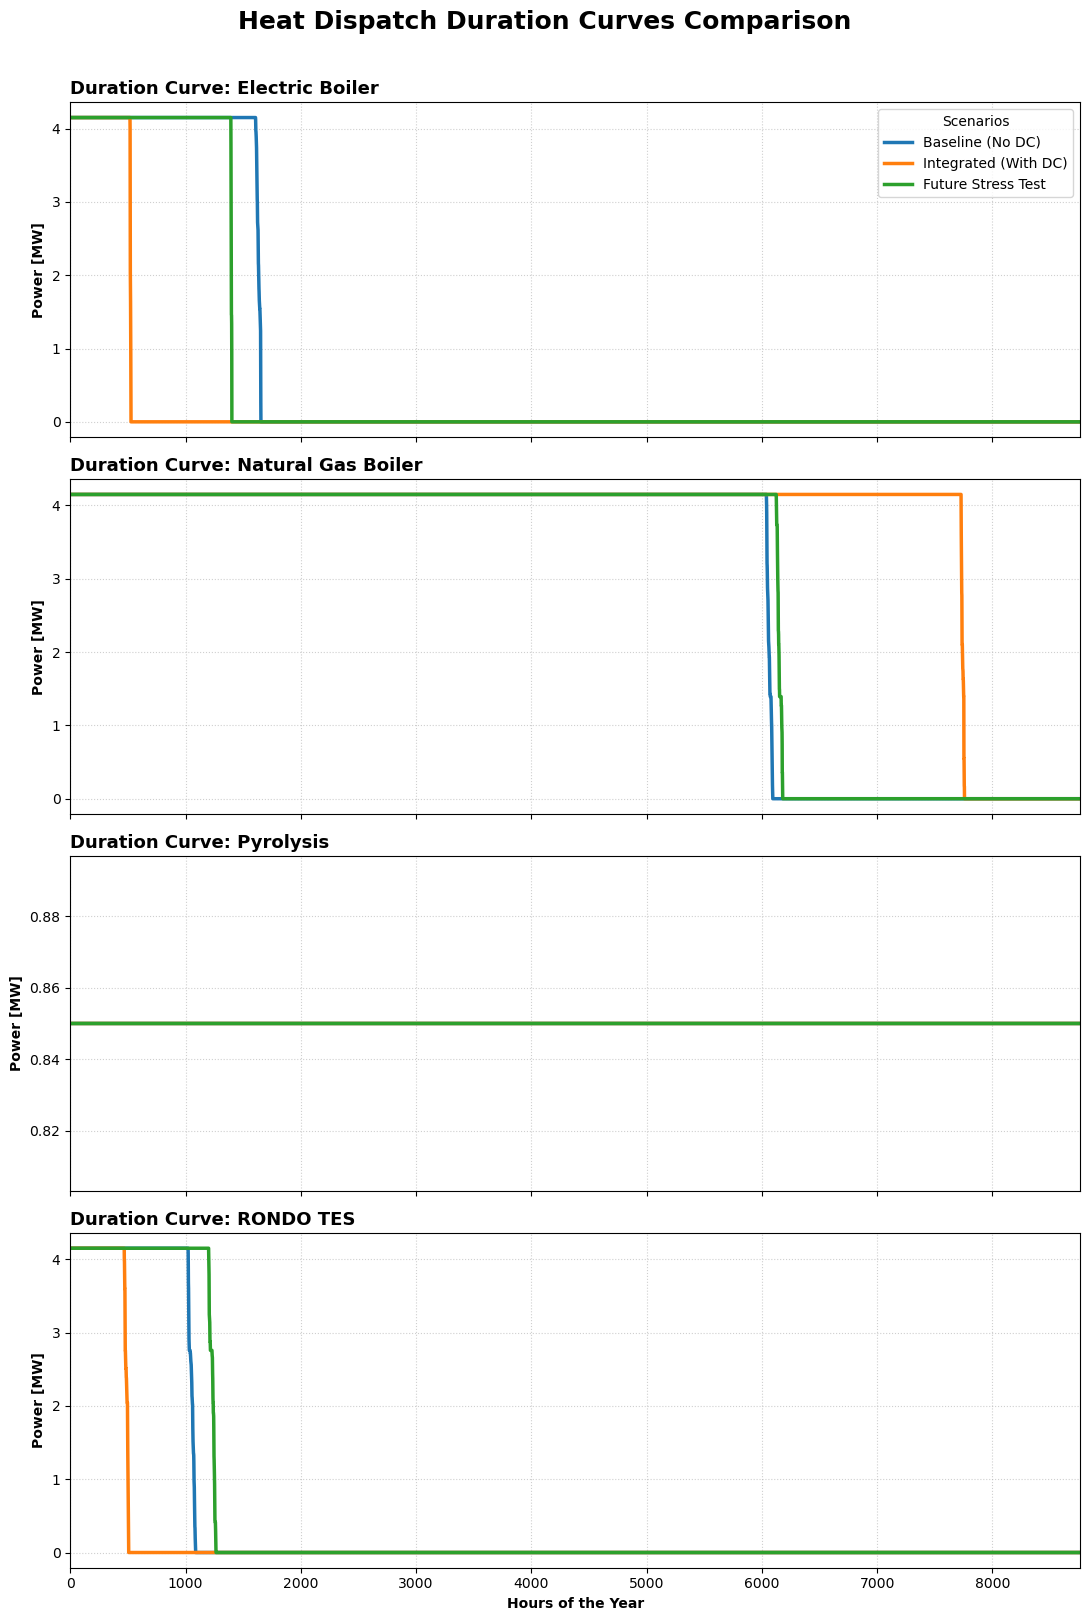

In [835]:
def plot_heat_duration_curves(networks_dict, title="Heat Dispatch Duration Curves Comparison"):
    """
    Automated duration curve comparison. 
    Assigns colors dynamically based on the number of scenarios provided.
    """
    target_links = {
        "Boiler_Skive": "Electric Boiler",
        "TES_Rondo_to_Heat_Bus_Skive": "RONDO TES",
        "NG boiler": "Natural Gas Boiler",
        "pyrolysis": "Pyrolysis"
    }
    
    # 1. Identify technologies and setup colors
    all_techs = set()
    for n in networks_dict.values():
        all_techs.update([target_links[l] for l in target_links.keys() if l in n.links.index])
    
    techs_list = sorted(list(all_techs))
    
    # Generate a list of colors automatically based on the number of scenarios
    # Uses the standard 'tab10' or 'Set1' category map
    cmap = plt.get_cmap("tab10") 
    scenario_colors = {name: cmap(i) for i, name in enumerate(networks_dict.keys())}

    fig, axes = plt.subplots(len(techs_list), 1, figsize=(11, 4 * len(techs_list)), sharex=True)
    if len(techs_list) == 1: axes = [axes]

    # 2. Process and Plot
    for i, tech_label in enumerate(techs_list):
        ax = axes[i]
        link_name = [k for k, v in target_links.items() if v == tech_label][0]
        
        for scenario_name, n in networks_dict.items():
            if link_name in n.links.index:
                # Sort descending
                data = (-n.links_t.p1[link_name]).values
                duration_curve = np.sort(data)[::-1]
                
                # Plot using the automated color
                ax.plot(duration_curve, label=scenario_name, 
                        color=scenario_colors[scenario_name], linewidth=2.5)
        
        ax.set_title(f"Duration Curve: {tech_label}", loc='left', fontweight='bold', fontsize=13)
        ax.set_ylabel("Power [MW]", fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_xlim(0, 8760)
        
        if i == 0:
            ax.legend(title="Scenarios", loc='upper right', frameon=True)

    axes[-1].set_xlabel("Hours of the Year", fontweight='bold')
    plt.suptitle(title, fontsize=18, fontweight='bold', y=1.01)
    plt.tight_layout()
    
    return fig

# Now you can use ANY name you want for the keys
scenarios = {
    "Baseline (No DC)": n21_wo_datacentre, 
    "Integrated (With DC)": n21_w_datacentre,
    "Future Stress Test": n24_w_datacentre 
}

fig = plot_heat_duration_curves(scenarios)
plt.show()


In [950]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_heat_duration_curves_with_stats(networks_dict, title="Heat Dispatch Duration Curves"):
    target_links = {
        "Boiler_Skive": "Electric Boiler",
        "TES_Rondo_to_Heat_Bus_Skive": "RONDO TES",
        "NG boiler": "Natural Gas Boiler",
        "pyrolysis": "Pyrolysis"
    }
    
    all_techs = set()
    for n in networks_dict.values():
        all_techs.update([target_links[l] for l in target_links.keys() if l in n.links.index])
    
    techs_list = sorted(list(all_techs))
    cmap = plt.get_cmap("tab10") 
    scenario_colors = {name: cmap(i) for i, name in enumerate(networks_dict.keys())}

    fig, axes = plt.subplots(len(techs_list), 1, figsize=(11, 4 * len(techs_list)), sharex=True)
    if len(techs_list) == 1: axes = [axes]

    # Storage for results table
    utilization_results = []

    for i, tech_label in enumerate(techs_list):
        ax = axes[i]
        link_name = [k for k, v in target_links.items() if v == tech_label][0]
        
        for scenario_name, n in networks_dict.items():
            if link_name in n.links.index:
                # 1. Get the data (p1 for net output)
                data = (-n.links_t.p1[link_name])
                duration_curve = np.sort(data.values)[::-1]
                
                # 2. Calculate Utilisation Rate
                # Util = Total Energy / (Capacity * Hours)
                p_nom = n.links.at[link_name, "p_nom_opt"] if "p_nom_opt" in n.links.columns else n.links.at[link_name, "p_nom"]
                total_energy = data.sum()
                max_energy = p_nom * len(n.snapshots)
                util_rate = (total_energy / max_energy) * 100 if max_energy > 0 else 0
                
                utilization_results.append({
                    "Scenario": scenario_name,
                    "Technology": tech_label,
                    "Utilisation [%]": round(util_rate, 2)
                })

                # 3. Plot
                ax.plot(duration_curve, label=f"{scenario_name} ({util_rate:.1f}%)", 
                        color=scenario_colors[scenario_name], linewidth=2.5)
        
        ax.set_title(f"Duration Curve: {tech_label}", loc='left', fontweight='bold', fontsize=13)
        ax.set_ylabel("Power [MW]", fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_xlim(0, 8760)
        ax.legend(title="Scenarios (Util %)", loc='upper right')

    axes[-1].set_xlabel("Hours of the Year", fontweight='bold')
    plt.suptitle(title, fontsize=18, fontweight='bold', y=1.01)
    plt.tight_layout()
    
    # Return both the figure and a DataFrame of the results
    return fig, pd.DataFrame(utilization_results)


   Scenario          Technology  Utilisation [%]
0      2021     Electric Boiler             7.75
1      2022     Electric Boiler             6.98
2      2023     Electric Boiler             6.33
3      2024     Electric Boiler             9.56
4      2021  Natural Gas Boiler            47.92
5      2022  Natural Gas Boiler            46.73
6      2023  Natural Gas Boiler            42.22
7      2024  Natural Gas Boiler            35.99
8      2021           Pyrolysis            42.50
9      2022           Pyrolysis            42.50
10     2023           Pyrolysis            42.44
11     2024           Pyrolysis            42.50
12     2021           RONDO TES             7.14
13     2022           RONDO TES             9.26
14     2023           RONDO TES            14.08
15     2024           RONDO TES            14.78


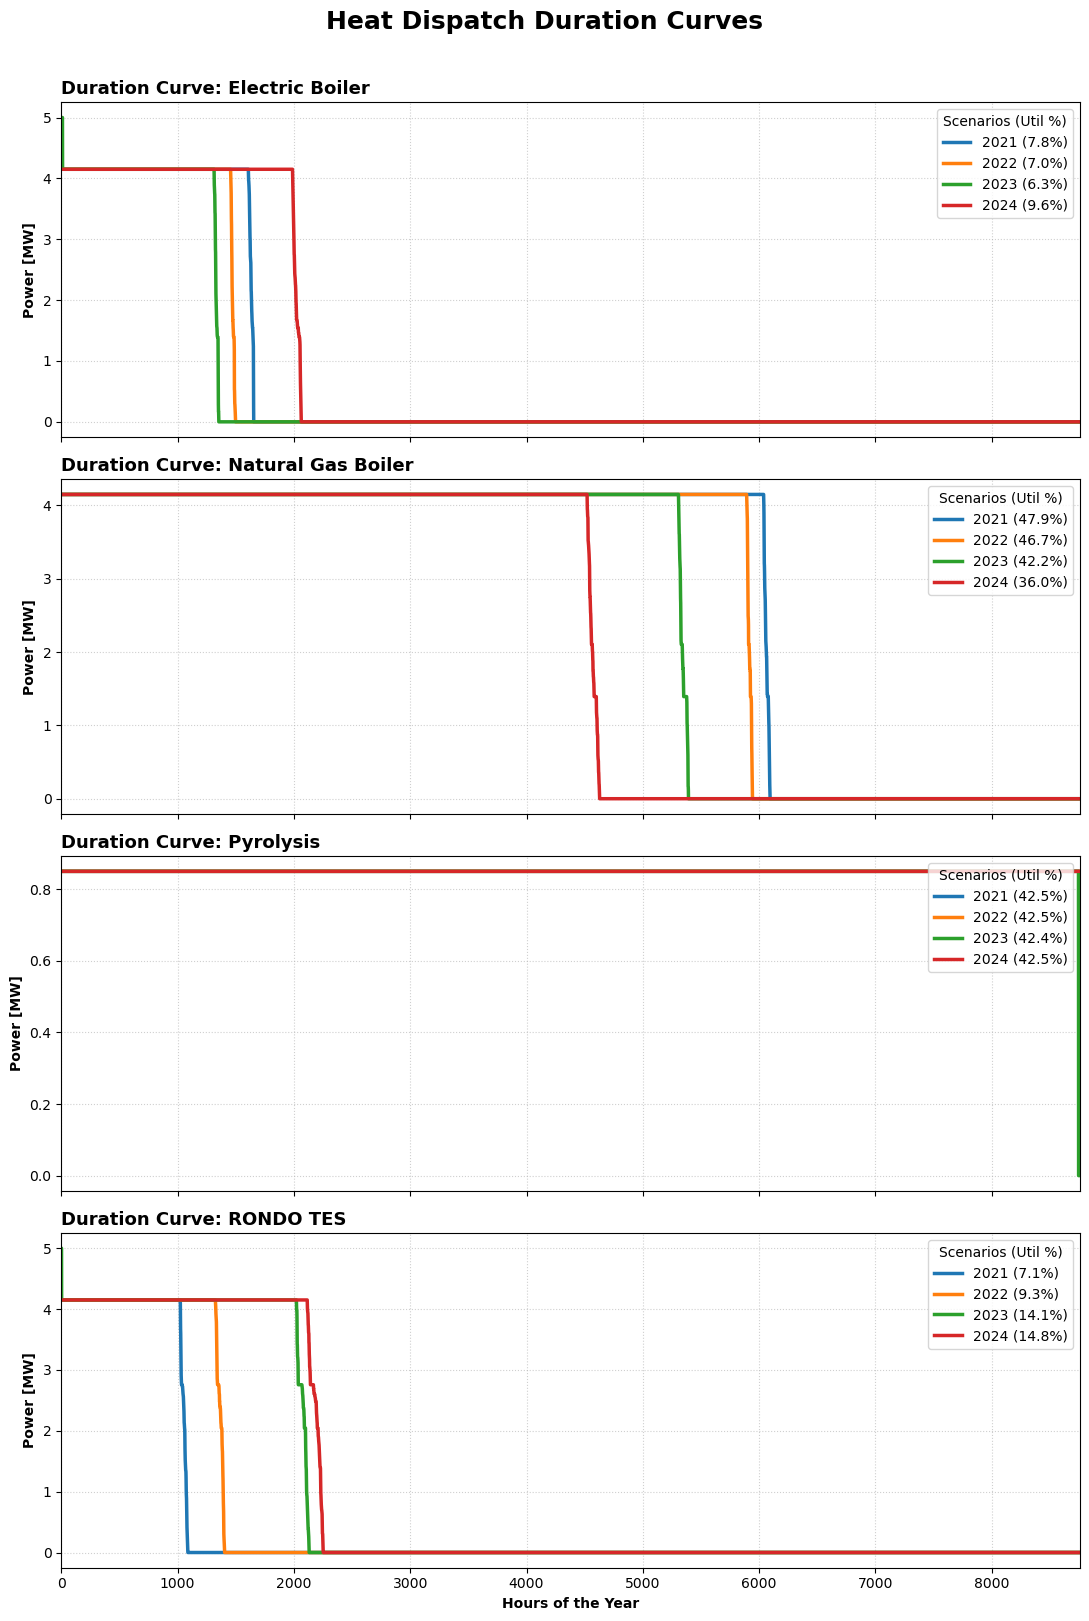

In [952]:
# --- Execution ---
scenarios = {"2021": n21_wo_datacentre, "2022": n22_wo_datacentre,"2023": n23_wo_datacentre ,"2024": n24_wo_datacentre}
# Run it
fig, stats_df = plot_heat_duration_curves_with_stats(scenarios)
print(stats_df)

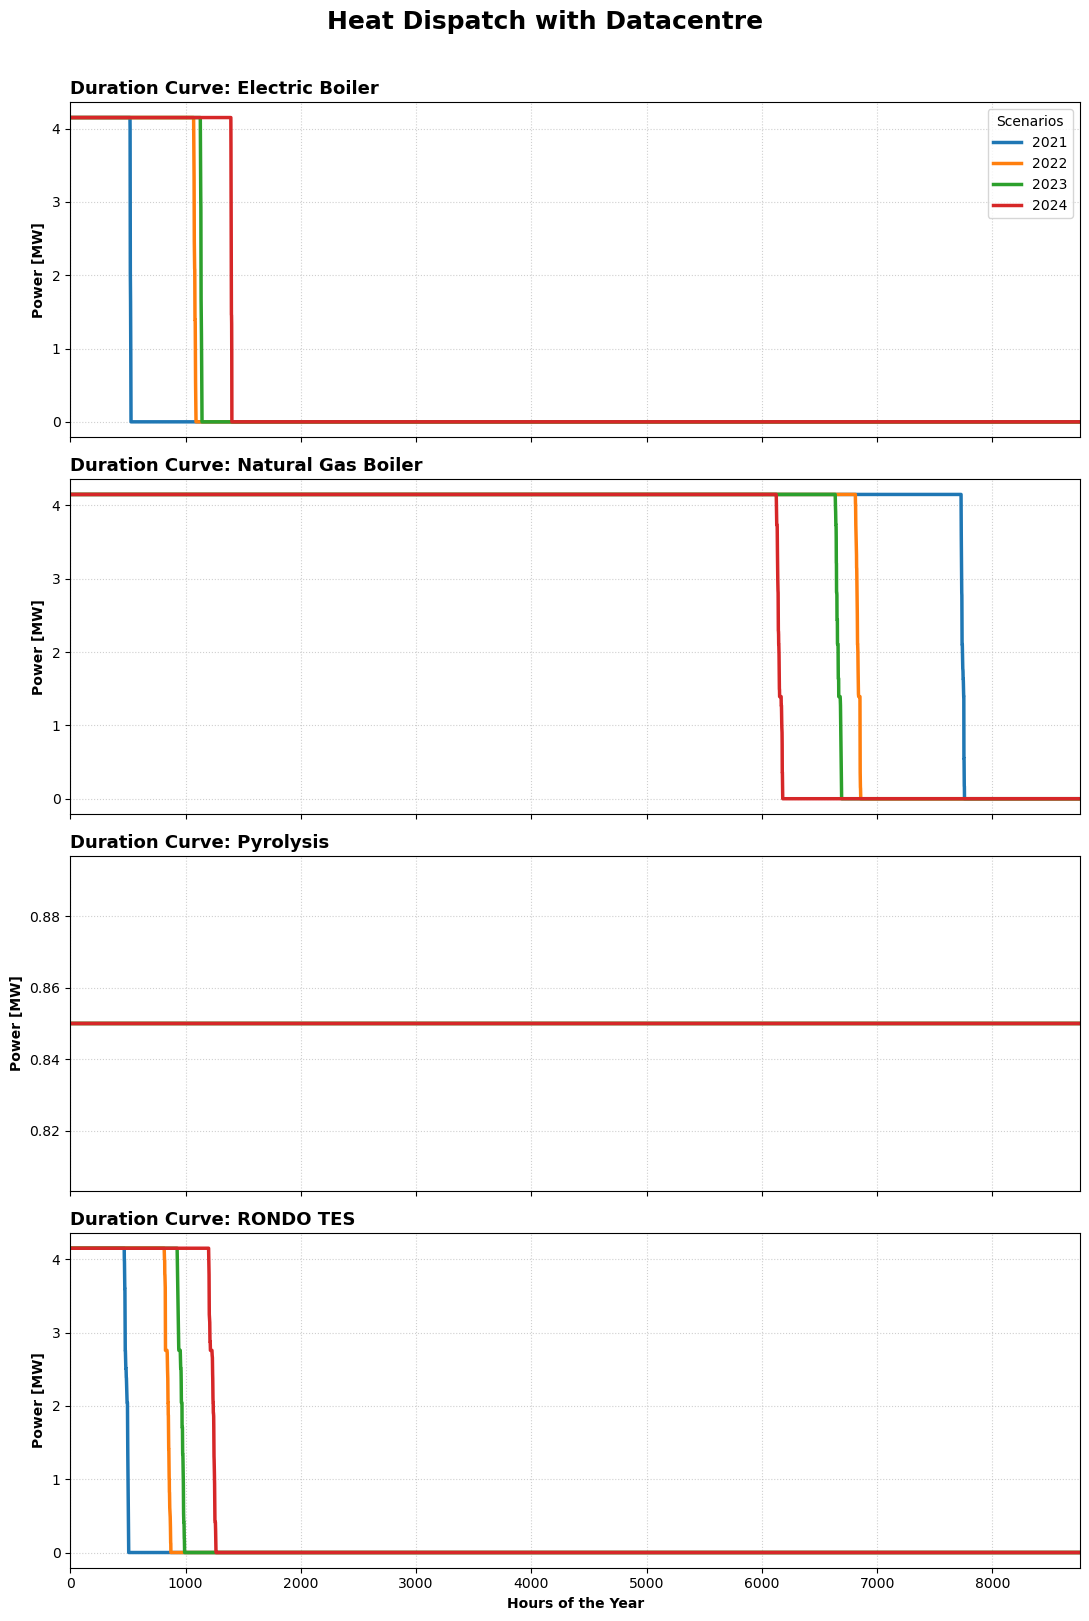

In [883]:

# --- Execution ---
scenarios = {"2021": n21_w_datacentre, "2022": n22_w_datacentre,"2023": n23_w_datacentre ,"2024": n24_w_datacentre}
fig = plot_heat_duration_curves(scenarios, title = "Heat Dispatch with Datacentre")
plt.show()

In [882]:
n24_w_datacentre.statistics.optimal_capacity()

component    carrier            
Generator    Grid Import               120.0
             Natural Gas                 6.0
             Onshore Wind               90.0
             Solar PV                   30.0
Link         Electric Boiler            10.0
             Grid Export               120.0
             Grid Import               120.0
             NG_boiler                   6.0
             Pyrolysis                   2.0
             RONDO_charge               24.0
             RONDO_discharge             7.0
             biochar                     0.9
StorageUnit  battery_storage            22.0
Store        RONDO Storage             100.0
             biochar_sequestered      7905.6
             pellets                105408.0
dtype: float64

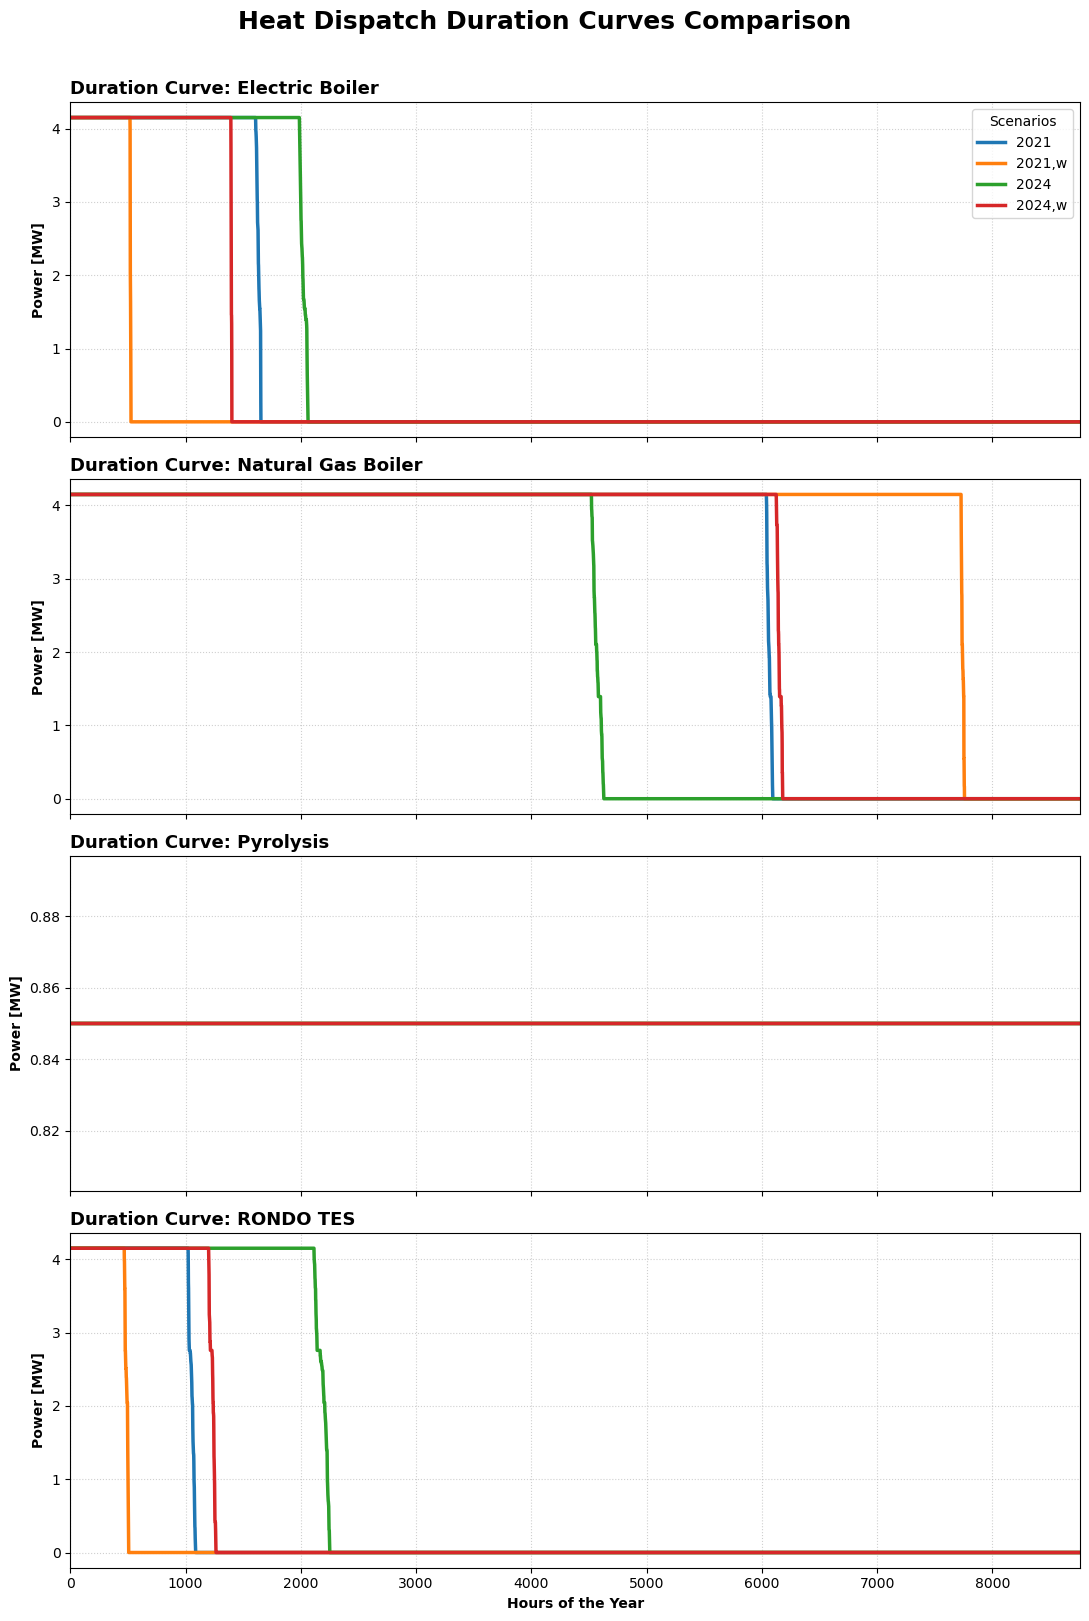

In [838]:
scenarios = {"2021": n21_wo_datacentre, "2021,w": n21_w_datacentre, "2024": n24_wo_datacentre, "2024,w": n24_w_datacentre}
fig = plot_heat_duration_curves(scenarios)
plt.show()

In [893]:
n21_w_datacentre.links

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,p_nom_opt,bus3,efficiency3,bus2,efficiency2
name,,,,,,,,,,,,,,,,,,,,,
Imports,Grid_Import,Greenlab,,imports,0.970,True,0,inf,84.0,0.0,...,0,NaN,NaN,1.0,1.0,120.0,,NaN,,NaN
Exports,Greenlab,Grid_Export,,exports,0.970,True,0,inf,84.0,0.0,...,0,NaN,NaN,1.0,1.0,120.0,,NaN,,NaN
Boiler_Skive,Greenlab,Heat_MT,,El_Boiler,0.950,True,0,inf,10.0,0.0,...,0,NaN,NaN,1.0,1.0,10.0,,NaN,,NaN
El_to_TES_Rondo,Greenlab,TES_Rondo,,RONDO_charge,0.980,True,0,inf,24.0,0.0,...,0,NaN,NaN,1.0,1.0,24.0,,NaN,,NaN
TES_Rondo_to_Heat_Bus_Skive,TES_Rondo,Heat_MT,,RONDO_discharge,0.720,True,0,inf,7.0,0.0,...,0,NaN,NaN,1.0,1.0,7.0,,NaN,,NaN
pyrolysis,pellets,Heat_MT,,Pyrolysis,0.425,True,0,inf,2.0,0.0,...,0,NaN,NaN,1.0,1.0,2.0,Greenlab,-0.02,biochar,0.45
biochar sequestration,biochar,biochar sequestration,,biochar,1.000,True,0,inf,0.0,0.0,...,0,NaN,NaN,1.0,1.0,0.9,,1.00,,1.00
NG boiler,NG,Heat_MT,,NG_boiler,0.900,True,0,inf,6.0,0.0,...,0,NaN,NaN,1.0,1.0,6.0,,1.00,,1.00


- Heat technolgies utilisation rates

In [907]:
n24_w_datacentre.links_t.p0["TES_Rondo_to_Heat_Bus_Skive"].describe()

count    8784.000000
mean        0.809646
std         1.991833
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         5.763889
Name: TES_Rondo_to_Heat_Bus_Skive, dtype: float64

In [903]:
n21_w_datacentre.links_t.p0["Boiler_Skive"].describe()

count    8754.000000
mean        0.260710
std         1.033340
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         4.368421
Name: Boiler_Skive, dtype: float64

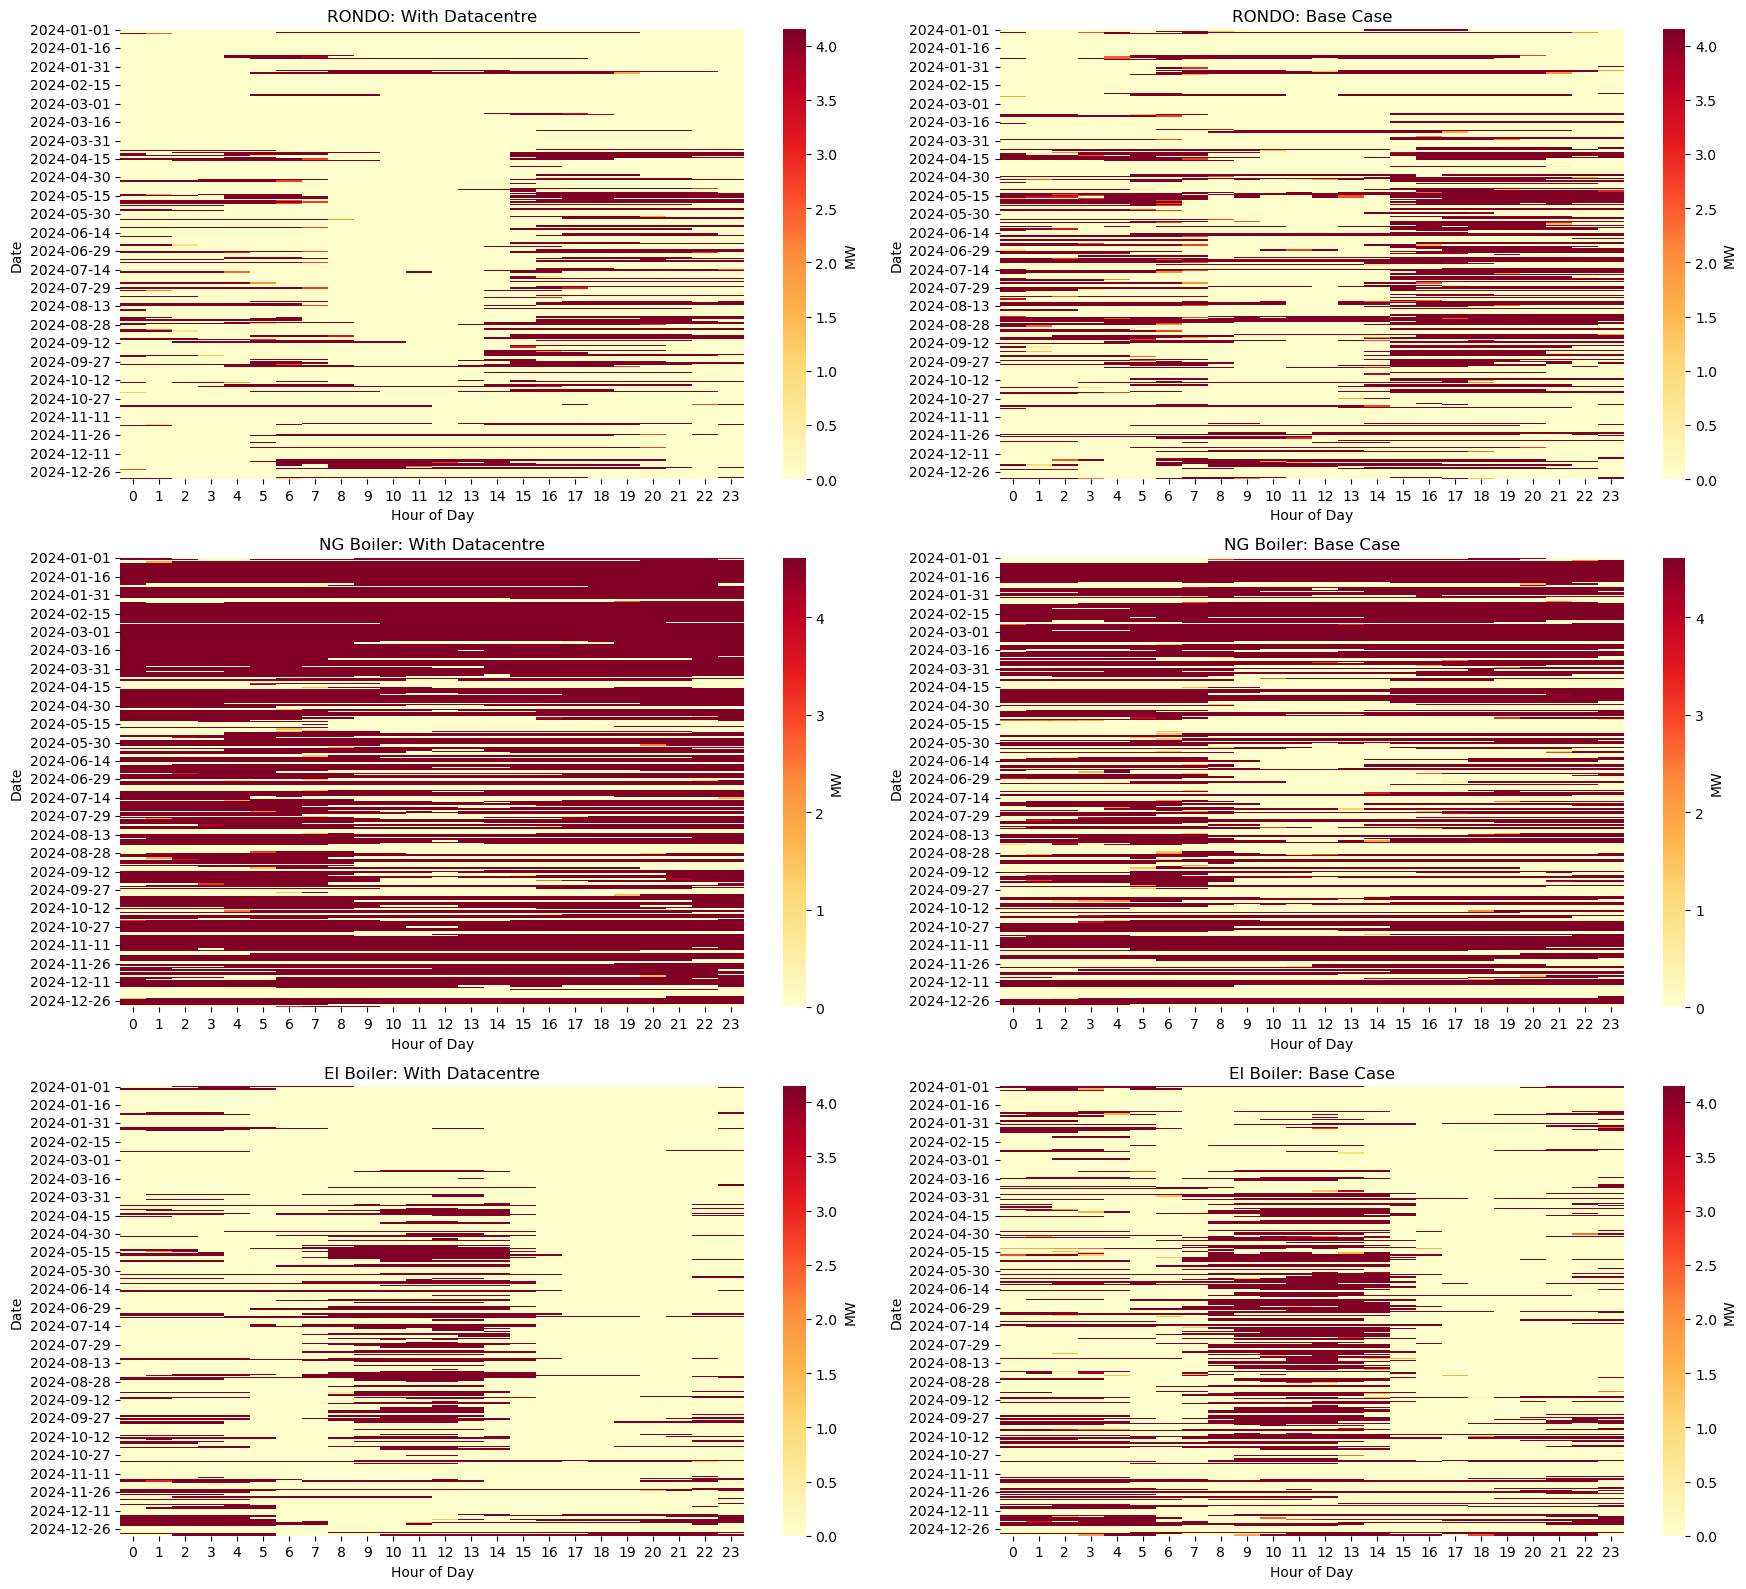

In [880]:

# Using a 3x2 layout to compare 'With' vs 'Without' side-by-side for each tech
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

# --- ROW 1: RONDO (Thermal Storage) ---
# 'YlOrRd' is the industry standard for thermal energy visualization
plot_pypsa_heatmap(-n24_w_datacentre.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO: With Datacentre", unit="MW", 
                   cmap="YlOrRd", ax=axes[0])

plot_pypsa_heatmap(-n24_wo_datacentre.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO: Base Case", unit="MW", 
                   cmap="YlOrRd", ax=axes[1])

# --- ROW 2: NG BOILER (Fossil Backup) ---
# 'magma' provides excellent contrast for "spiky" fossil fuel usage
plot_pypsa_heatmap(n24_w_datacentre.links_t.p0["NG boiler"], 
                   title="NG Boiler: With Datacentre", unit="MW", 
                   cmap="YlOrRd", ax=axes[2])

plot_pypsa_heatmap(n24_wo_datacentre.links_t.p0["NG boiler"], 
                   title="NG Boiler: Base Case", unit="MW", 
                   cmap="YlOrRd", ax=axes[3])

# --- ROW 3: SKIVE BOILER (Auxiliary) ---
# 'rocket' or 'flare' differentiates this from the main NG boiler
plot_pypsa_heatmap(-n24_w_datacentre.links_t.p1["Boiler_Skive"], 
                   title="El Boiler: With Datacentre", unit="MW", 
                   cmap="YlOrRd", ax=axes[4])

plot_pypsa_heatmap(-n24_wo_datacentre.links_t.p1["Boiler_Skive"], 
                   title="El Boiler: Base Case", unit="MW", 
                   cmap="YlOrRd", ax=axes[5])

plt.tight_layout()
plt.show()

# Increasing Carbon Tax, Import Price, Export Price, NG Price

In [840]:
def plot_heat_comparison_stacked(networks_dict, title="Annual Heat Production Comparison"):
    """
    Plots a stacked bar chart for multiple PyPSA networks.
    Technologies are sorted by total contribution across all scenarios.
    """
    target_links = {
        "RONDO": "TES_Rondo_to_Heat_Bus_Skive",
        "Electric Boiler": "Boiler_Skive",
        "NG Boiler": "NG boiler",
        "Pyrolysis": "pyrolysis"
    }
    
    # 1. Extract Data
    all_data = []
    for scenario, n in networks_dict.items():
        res = {label: max(0, (-n.links_t.p1[link].sum() / 1e3)) 
               for label, link in target_links.items() if link in n.links.index}
        all_data.append(pd.Series(res, name=scenario))
    
    df = pd.concat(all_data, axis=1).T
    
    # 2. Sort columns by their total sum (highest at bottom of stack)
    cols_sorted = df.sum().sort_values(ascending=False).index
    df = df[cols_sorted]

    # 3. Plotting
    # Define colors to match your existing style
    color_map = {'RONDO': '#FFB74D', 'Electric Boiler': '#64B5F6', 
                 'NG Boiler': '#E57373', 'Pyrolysis': '#81C784'}
    plot_colors = [color_map[c] for c in df.columns]

    ax = df.plot(kind='bar', stacked=True, figsize=(11, 7), 
                 color=plot_colors, edgecolor='white', width=0.7)

    # 4. Add Labels (Centered in stacks)
    for n, x in enumerate([p.get_x() for p in ax.patches[:len(df)]]):
        cumulative_height = 0
        for i, row in enumerate(df.iloc[n]):
            if row > 1.0: # Only label if > 1 GWh to avoid clutter
                ax.text(x + 0.35, cumulative_height + row/2, f'{row:.1f}', 
                        ha='center', va='center', color='white', fontweight='bold')
            cumulative_height += row
        
        # Total label on top
        ax.text(x + 0.35, cumulative_height + 0.5, f'{cumulative_height:.1f}', 
                ha='center', va='bottom', fontweight='black', fontsize=11)

    # 5. Formatting
    ax.set_title(title, fontsize=18, fontweight='bold', pad=30)
    ax.set_ylabel("Heat Production [GWh]", fontsize=14)
    ax.set_xlabel("Year / Scenario", fontsize=14)
    plt.xticks(rotation=0)
    
    # Legend - reverse to match stack order
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(reversed(handles), reversed(labels), title="Technology", 
              bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()

In [842]:
n24_w_datacentre_tax120 = build_network_simple_w_datacentre(P_el_extra = 100,P_heat = 5, P_el = 2,CO2_tax = 120, grid_emissions = grid_emissions["2024"],p_import = import_price24, p_export = export_price24, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2024"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 19.34it/s]
INFO:linopy.io: Writing time: 4.89s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 13412 iterations and 6.60 seconds (3.30 work units)


INFO:gurobipy:Solved in 13412 iterations and 6.60 seconds (3.30 work units)


Optimal objective  8.037881777e+07


INFO:gurobipy:Optimal objective  8.037881777e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210830 primals, 474358 duals
Objective: 8.04e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Grid Symmetry were not assigned to the network.


In [844]:
n24_w_datacentre_tax160 = build_network_simple_w_datacentre(P_el_extra = 100,P_heat = 5, P_el = 2,CO2_tax = 160, grid_emissions = grid_emissions["2024"],p_import = import_price24, p_export = export_price24, NG_price = NG_price["MarginalPurchasePriceEUR_MWh"]["2024"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 12/12 [00:00<00:00, 16.93it/s]
INFO:linopy.io: Writing time: 4.6s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 13256 iterations and 6.72 seconds (3.47 work units)


INFO:gurobipy:Solved in 13256 iterations and 6.72 seconds (3.47 work units)


Optimal objective  8.349907094e+07


INFO:gurobipy:Optimal objective  8.349907094e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 210830 primals, 474358 duals
Objective: 8.35e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Grid Symmetry were not assigned to the network.


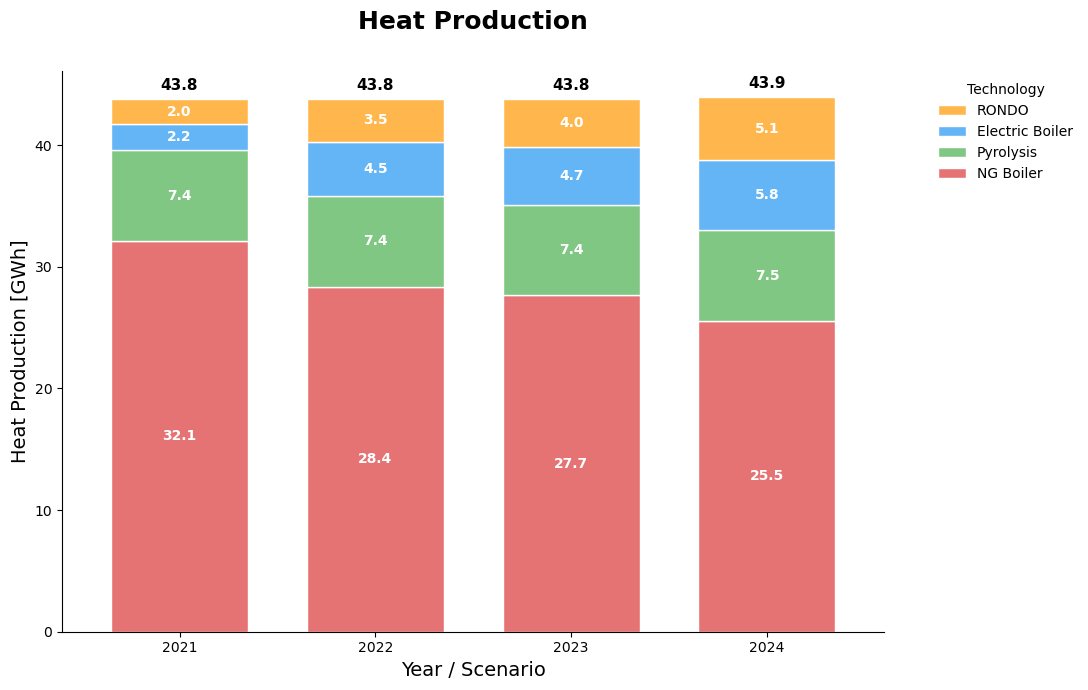

In [841]:
plot_heat_comparison_stacked({'2021': n21_w_datacentre, '2022': n22_w_datacentre, '2023': n23_w_datacentre,'2024': n24_w_datacentre}, title = "Heat Production")

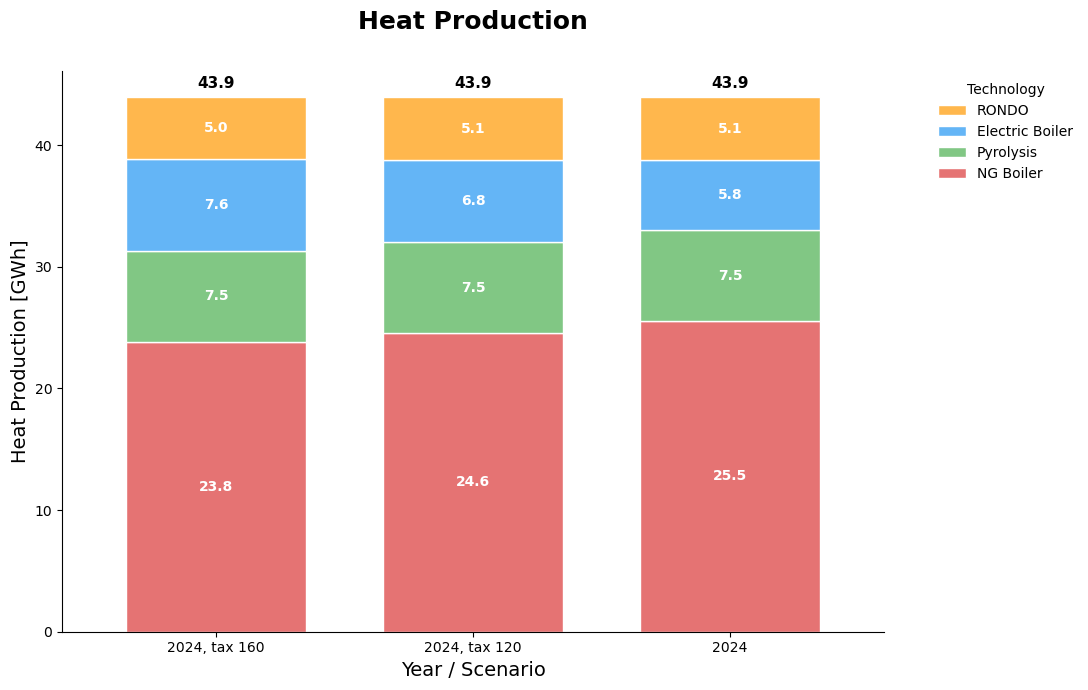

In [845]:
plot_heat_comparison_stacked({'2024, tax 160': n24_w_datacentre_tax160,'2024, tax 120': n24_w_datacentre_tax120 ,'2024': n24_w_datacentre}, title = "Heat Production")

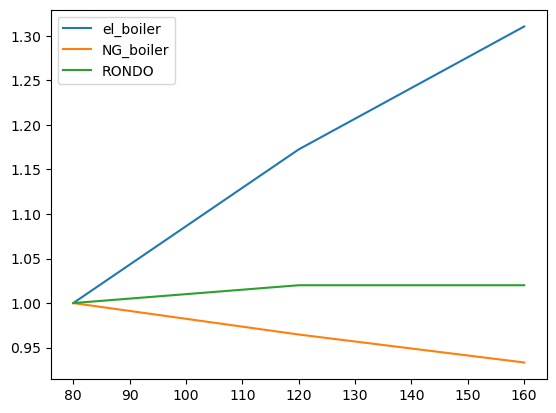

In [862]:
plt.plot([80,120,160],[5.8/5.8,6.8/5.8,7.6/5.8], label = "el_boiler")
plt.plot([80,120,160],[25.5/25.5,24.6/25.5,23.8/25.5], label = "NG_boiler")
plt.plot([80,120,160],[1,5.1/5,5.1/5], label = "RONDO")
plt.legend()

In [848]:
n24_w_datacentre_tax160.statistics.optimal_capacity() - n24_w_datacentre.statistics.optimal_capacity()

component    carrier            
Generator    Grid Import            0.0
             Natural Gas            0.0
             Onshore Wind           0.0
             Solar PV               0.0
Link         Electric Boiler        0.0
             Grid Export            0.0
             Grid Import            0.0
             NG_boiler              0.0
             Pyrolysis              0.0
             RONDO_charge           0.0
             RONDO_discharge        0.0
             biochar                0.0
StorageUnit  battery_storage        0.0
Store        RONDO Storage          0.0
             biochar_sequestered    0.0
             pellets                0.0
dtype: float64

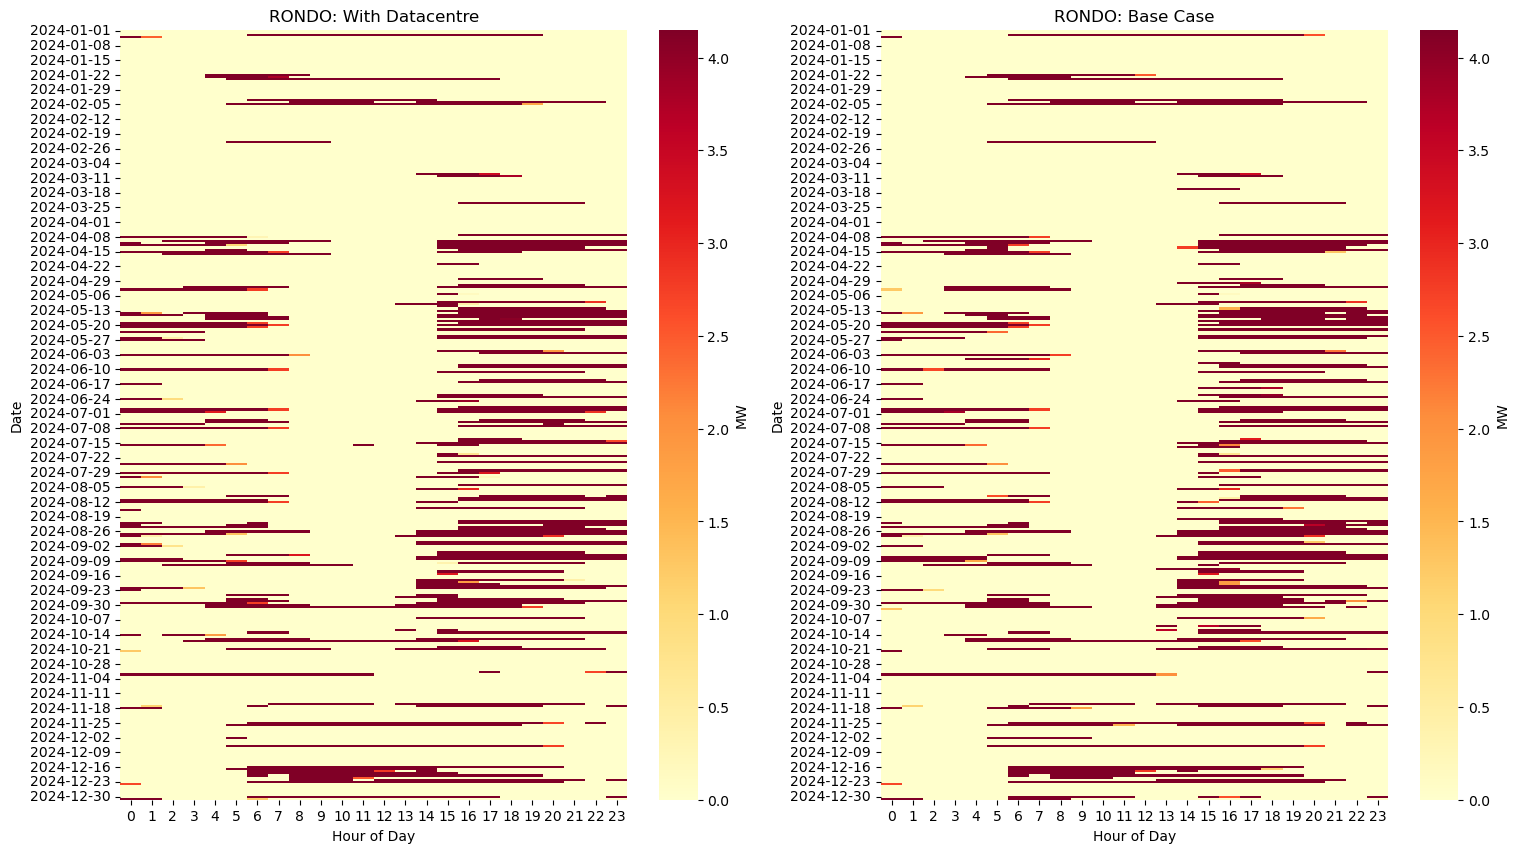

In [851]:
# Using a 3x2 layout to compare 'With' vs 'Without' side-by-side for each tech
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
axes = axes.flatten()

# --- ROW 1: RONDO (Thermal Storage) ---
# 'YlOrRd' is the industry standard for thermal energy visualization
plot_pypsa_heatmap(-n24_w_datacentre.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO: With Datacentre", unit="MW", 
                   cmap="YlOrRd", ax=axes[0])

plot_pypsa_heatmap(-n24_w_datacentre_tax120.links_t.p1["TES_Rondo_to_Heat_Bus_Skive"], 
                   title="RONDO: Base Case", unit="MW", 
                   cmap="YlOrRd", ax=axes[1])

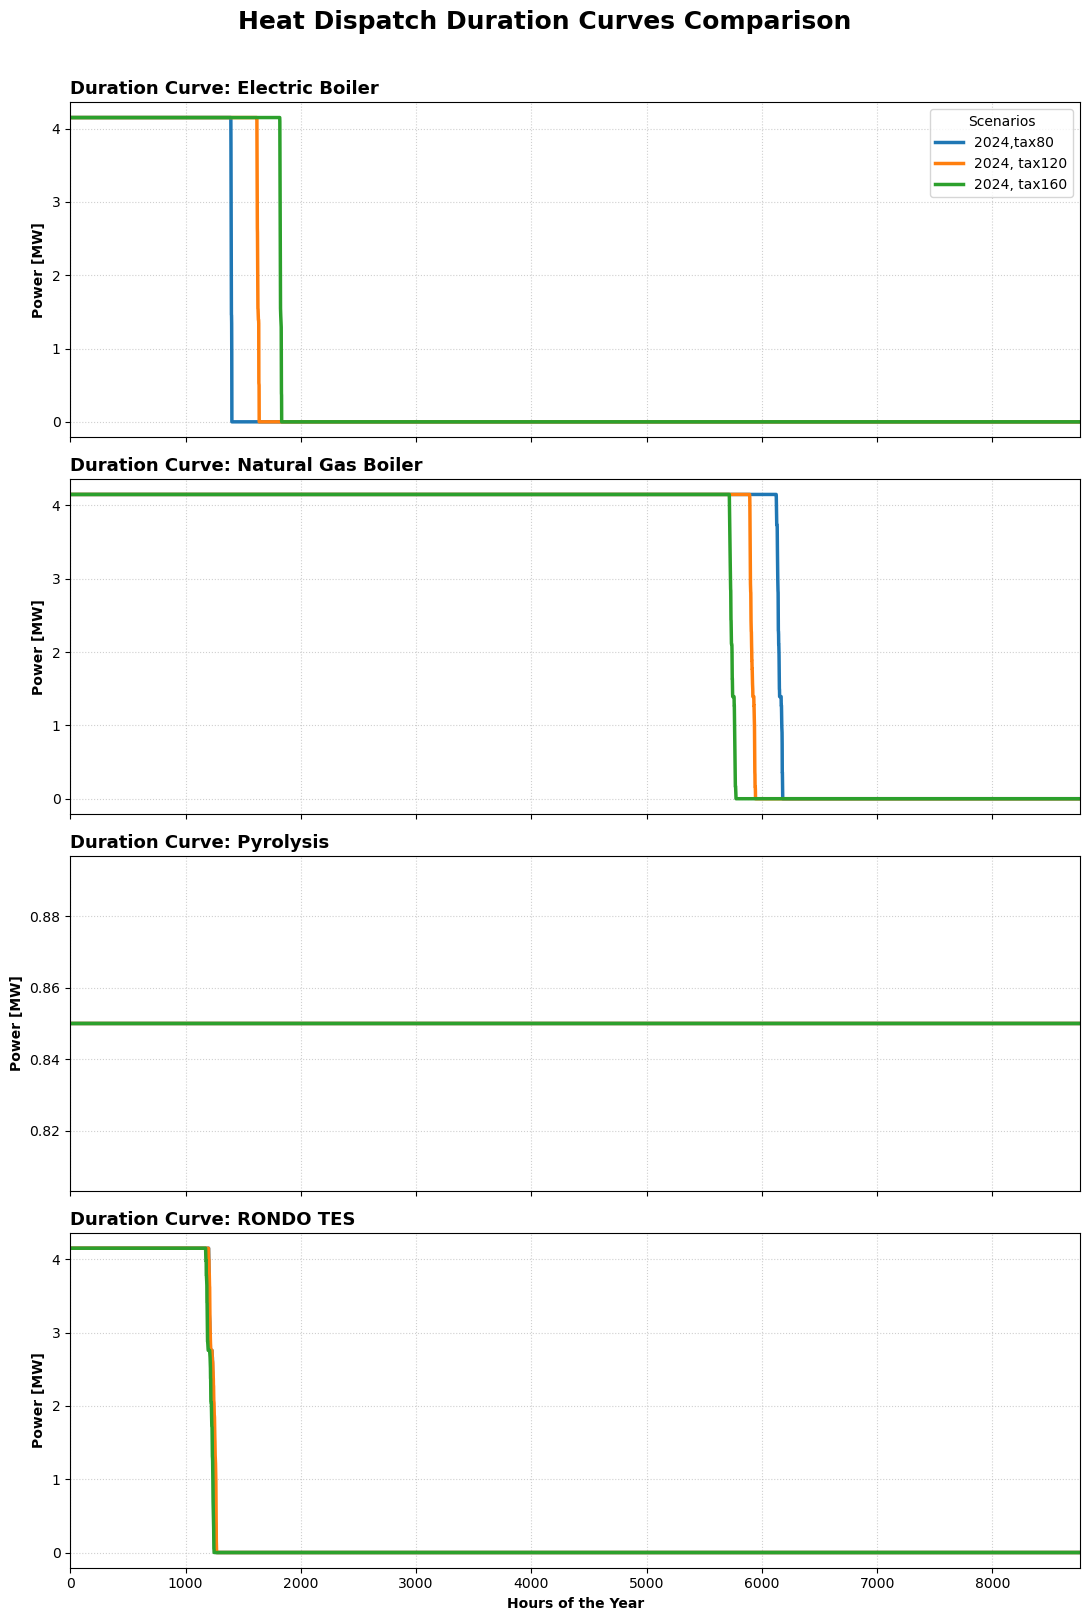

In [855]:
scenarios = {"2024,tax80": n24_w_datacentre, "2024, tax120": n24_w_datacentre_tax120, "2024, tax160": n24_w_datacentre_tax160}
fig = plot_heat_duration_curves(scenarios)
plt.show()

In [864]:
def plot_heat_summary(n, load_name="Heat_Load_MT", title="Heat Production Mix", 
                      show_stats=True):
    """
    Plots a stacked area chart for your standard Skive/GreenLab heat links.
    """
    # Define your standard links and colors as the 'source of truth'
    standard_links = {
        "Boiler Skive": "Boiler_Skive",
        "NG Boiler": "NG boiler",
        "Pyrolysis": "pyrolysis",
        "RONDO": "TES_Rondo_to_Heat_Bus_Skive"
    }
    colors = ["orange", "blue", "green", "red"]
    
    # 1. Extract and invert the p1 data (converts consumption to production)
    data = {}
    for label, py_name in standard_links.items():
        if py_name in n.links_t.p1.columns:
            data[label] = -n.links_t.p1[py_name]
    
    df = pd.DataFrame(data)

    # 2. Plotting
    fig, ax = plt.subplots(figsize=(12, 6))
    df.plot.area(ax=ax, color=colors, alpha=0.8, lw=0)

    # 3. Add the Demand Line
    if load_name in n.loads_t.p_set.columns:
        n.loads_t.p_set[load_name].plot(ax=ax, color="black", lw=1.5, 
                                        ls="--", label="Heat Demand")

    # 4. Formatting
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel("Heat [MW]")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
    plt.tight_layout()
    
    # 5. Print Energy Stats (MWh to GWh)
    if show_stats:
        print(f"\n--- Annual Energy Production (GWh) ---")
        # Sum MW over time and divide by 1000 to get GWh
        stats = df.sum() / 1000 
        print(stats)
        
    return ax


--- Annual Energy Production (GWh) ---
Boiler Skive     5.800992
NG Boiler       25.532021
Pyrolysis        7.466400
RONDO            5.120588
dtype: float64


<Axes: title={'center': 'Heat Production Mix'}, xlabel='snapshot', ylabel='Heat [MW]'>

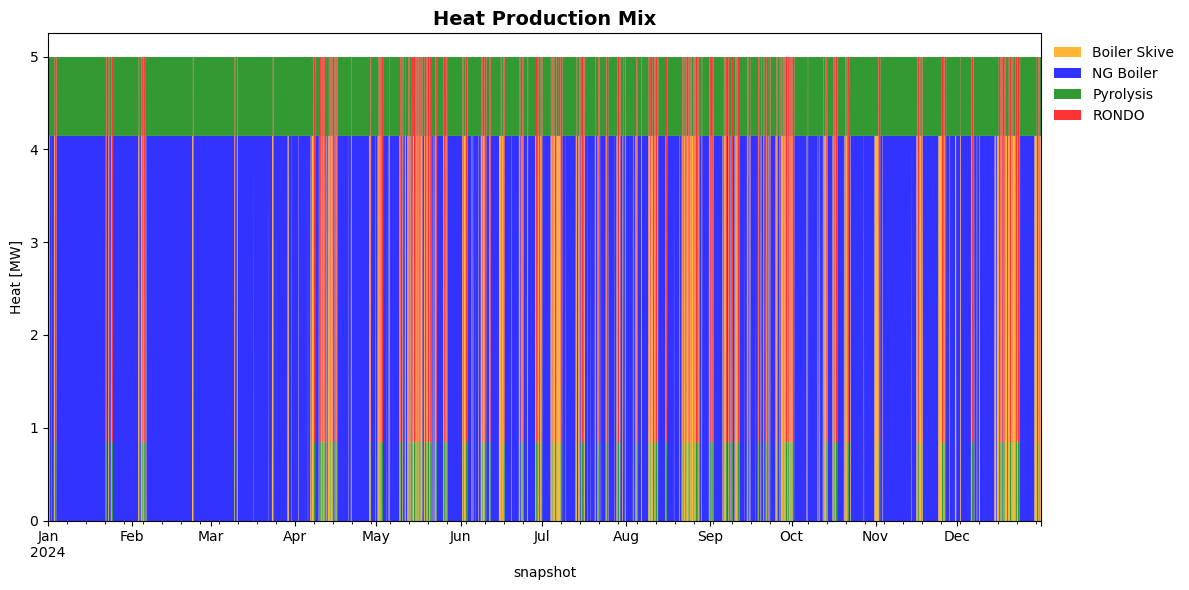

In [867]:
plot_heat_summary(n24_w_datacentre, load_name="Heat_Load_MT", title="Heat Production Mix", show_stats=True)

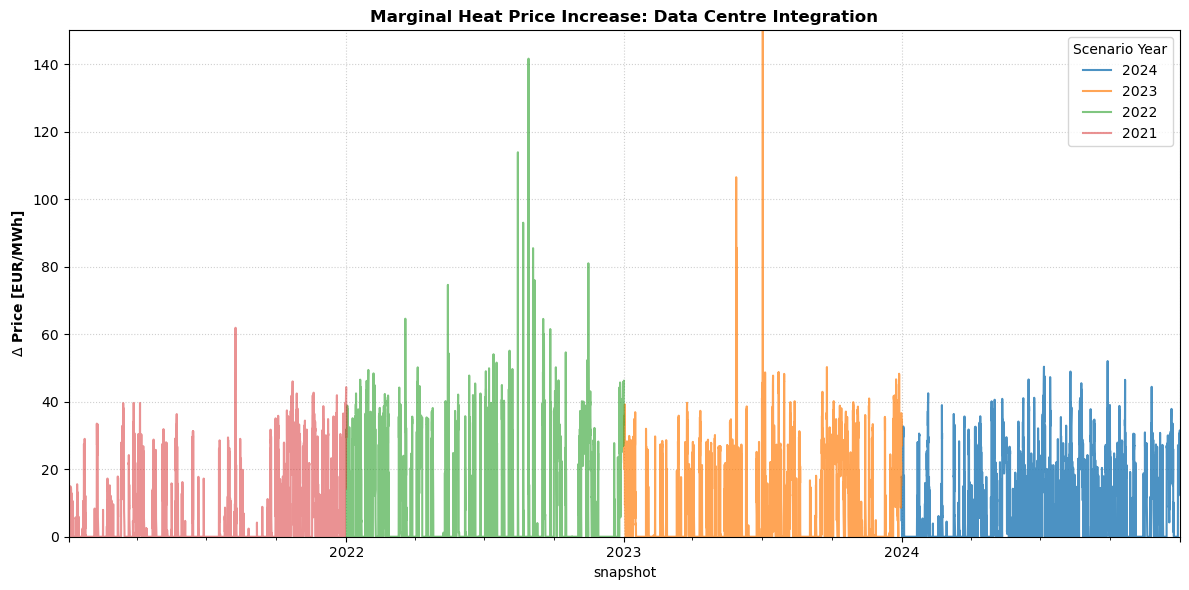

In [981]:
import matplotlib.pyplot as plt

# 1. Create the figure
plt.figure(figsize=(12, 6))

# 2. Plot each delta (With DC - Without DC)
(n24_w_datacentre.buses_t.marginal_price["Heat_MT"] - n24_wo_datacentre.buses_t.marginal_price["Heat_MT"]).plot(label="2024", alpha=0.8)
(n23_w_datacentre.buses_t.marginal_price["Heat_MT"] - n23_wo_datacentre.buses_t.marginal_price["Heat_MT"]).plot(label="2023", alpha=0.7)
(n22_w_datacentre.buses_t.marginal_price["Heat_MT"] - n22_wo_datacentre.buses_t.marginal_price["Heat_MT"]).plot(label="2022", alpha=0.6)
(n21_w_datacentre.buses_t.marginal_price["Heat_MT"] - n21_wo_datacentre.buses_t.marginal_price["Heat_MT"]).plot(label="2021", alpha=0.5)

# 3. Fix the Y-Label with proper LaTeX delta symbol
plt.ylabel(r"$\Delta$ Price [EUR/MWh]", fontweight='bold')
plt.title("Marginal Heat Price Increase: Data Centre Integration", fontweight='bold')

# 4. Aesthetics
plt.ylim(0, 150)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Scenario Year")
plt.tight_layout()

plt.show()

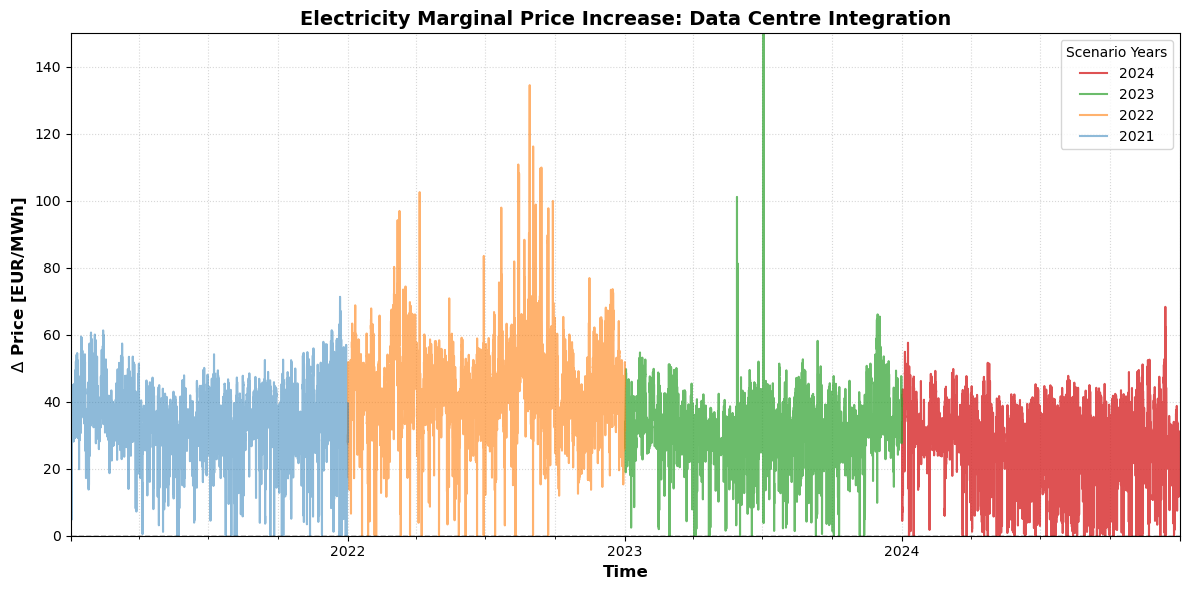

(0.0, 150.0)

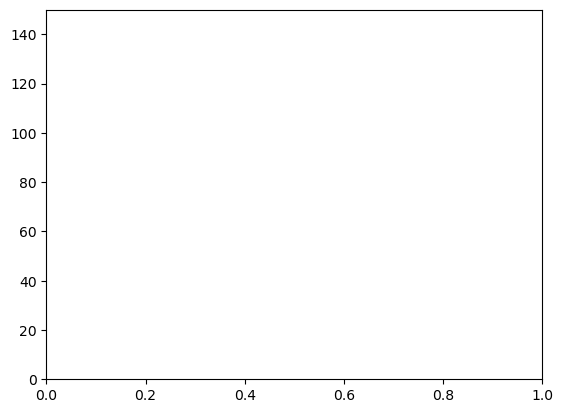

In [980]:
import matplotlib.pyplot as plt

# 1. Create the figure for Electricity Price Delta
plt.figure(figsize=(12, 6), dpi=100)

# 2. Plot each delta (With DC - Without DC) for the Greenlab Bus
(n24_w_datacentre.buses_t.marginal_price["Greenlab"] - n24_wo_datacentre.buses_t.marginal_price["Greenlab"]).plot(label="2024", alpha=0.8, color='#d62728')
(n23_w_datacentre.buses_t.marginal_price["Greenlab"] - n23_wo_datacentre.buses_t.marginal_price["Greenlab"]).plot(label="2023", alpha=0.7, color='#2ca02c')
(n22_w_datacentre.buses_t.marginal_price["Greenlab"] - n22_wo_datacentre.buses_t.marginal_price["Greenlab"]).plot(label="2022", alpha=0.6, color='#ff7f0e')
(n21_w_datacentre.buses_t.marginal_price["Greenlab"] - n21_wo_datacentre.buses_t.marginal_price["Greenlab"]).plot(label="2021", alpha=0.5, color='#1f77b4')

# 3. Proper LaTeX and styling
plt.title("Electricity Marginal Price Increase: Data Centre Integration", fontweight='bold', fontsize=14)
plt.ylabel(r"$\Delta$ Price [EUR/MWh]", fontweight='bold', fontsize=12)
plt.xlabel("Time", fontweight='bold', fontsize=12)

# 4. Limits and Aesthetics
plt.ylim(0, 150)
plt.axhline(0, color='black', lw=1, ls='--') # Zero line for reference
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend(title="Scenario Years", loc='upper right', frameon=True)

plt.tight_layout()
plt.show()
plt.ylim(0,150)

# Rolling Horizon (2024)

In [990]:
n24_w_datacentre.snapshots

DatetimeIndex(['2024-01-01 00:00:00', '2024-01-01 01:00:00',
               '2024-01-01 02:00:00', '2024-01-01 03:00:00',
               '2024-01-01 04:00:00', '2024-01-01 05:00:00',
               '2024-01-01 06:00:00', '2024-01-01 07:00:00',
               '2024-01-01 08:00:00', '2024-01-01 09:00:00',
               ...
               '2024-12-31 14:00:00', '2024-12-31 15:00:00',
               '2024-12-31 16:00:00', '2024-12-31 17:00:00',
               '2024-12-31 18:00:00', '2024-12-31 19:00:00',
               '2024-12-31 20:00:00', '2024-12-31 21:00:00',
               '2024-12-31 22:00:00', '2024-12-31 23:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=8784, freq='h')

In [992]:
def prepare_rolling_horizon(n_input):
    """
    Takes a solved Perfect Foresight network, copies it, freezes 
    optimized capacities, and prepares it for Rolling Horizon.
    """
    # 1. Clean up and Copy
    if hasattr(n_input, 'model'):
        del n_input.model
    
    n_rh = n_input.copy()
    
    # 2. Fix Links (Biogas, Boilers, Grid Links)
    if not n_rh.links.empty:
        n_rh.links.p_nom = n_rh.links.p_nom_opt
        n_rh.links.p_nom_extendable = False
        
    # 3. Fix Generators (Wind, Solar)
    if not n_rh.generators.empty:
        n_rh.generators.p_nom = n_rh.generators.p_nom_opt
        n_rh.generators.p_nom_extendable = False
        
    # 4. Fix Storage Units (Batteries)
    if not n_rh.storage_units.empty:
        n_rh.storage_units.p_nom = n_rh.storage_units.p_nom_opt
        n_rh.storage_units.p_nom_extendable = False
        
    # 5. Fix Stores (Biomass, H2, Methane, TES Rondo)
    if not n_rh.stores.empty:
        n_rh.stores.e_nom = n_rh.stores.e_nom_opt
        n_rh.stores.e_nom_extendable = False
        
    print("✅ Capacities fixed. Network ready for Rolling Horizon.")
    return n_rh

In [993]:
n24_w_datacentre_rh_DA = prepare_rolling_horizon(n24_w_datacentre)

✅ Capacities fixed. Network ready for Rolling Horizon.


In [995]:
n24_w_datacentre_rh_DA.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Grid Import                     120.0               120.0   
            Natural Gas                       6.0                 6.0   
            Onshore Wind                     90.0                90.0   
            Solar PV                         30.0                30.0   
Link        Electric Boiler                  10.0                10.0   
            Grid Export                     120.0               120.0   
            Grid Import                     120.0               120.0   
            NG_boiler                         6.0                 6.0   
            Pyrolysis                         2.0                 2.0   
            RONDO_charge                     24.0                24.0   
            RONDO_discharge                   7.0                 7.0   
            biochar                           0.9                 0.9   
Load        electricity                       0.0                 0.0   
            heat                              0.0                 0.0   
StorageUnit battery_storage                  22.0                22.0   
Store       RONDO Storage                   100.0               100.0   
            biochar_sequestered            7905.6              7905.6   
            pellets                      105408.0            105408.0   

                                       Supply    Withdrawal  Energy Balance  \
Generator   Grid Import          690837.53918       0.00000    690837.53918   
            Natural Gas           28368.91172       0.00000     28368.91172   
            Onshore Wind         215059.37774       0.00000    215059.37774   
            Solar PV              29221.93200       0.00000     29221.93200   
Link        Electric Boiler           0.00000    6106.30709     -6106.30709   
            Grid Export               0.00000       0.00000         0.00000   
            Grid Import               0.00000  690837.53918   -690837.53918   
            NG_boiler                 0.00000   28368.91172    -28368.91172   
            Pyrolysis                 0.00000   17568.00000    -17568.00000   
            RONDO_charge              0.00000    8139.90236     -8139.90236   
            RONDO_discharge           0.00000    7111.92738     -7111.92738   
            biochar                   0.00000    7905.60000     -7905.60000   
Load        electricity               0.00000  895968.00000   -895968.00000   
            heat                      0.00000   43920.00000    -43920.00000   
StorageUnit battery_storage       24286.24074   28114.39405     -3828.15330   
Store       RONDO Storage          7111.92738    7977.10431      -865.17693   
            biochar_sequestered       0.00000    7905.60000     -7905.60000   
            pellets               17568.00000       0.00000     17568.00000   

                                Transmission  Capacity Factor   Curtailment  \
Generator   Grid Import                  0.0         0.655394  363242.46082   
            Natural Gas                  0.0         0.538268   24335.08828   
            Onshore Wind                 0.0         0.272034     452.08253   
            Solar PV                     0.0         0.110891       0.00000   
Link        Electric Boiler              0.0         0.069516       0.00000   
            Grid Export                  0.0         0.000000       0.00000   
            Grid Import                  0.0         0.655394       0.00000   
            NG_boiler                    0.0         0.538268       0.00000   
            Pyrolysis                    0.0         1.000000       0.00000   
            RONDO_charge                 0.0         0.038611       0.00000   
            RONDO_discharge              0.0         0.115664       0.00000   
            biochar                      0.0         1.000000       0.00000   
Load        electricity                  0.0              NaN       0.00000   
            heat                     